In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import rcParams
from matplotlib import cm, colors
import scanpy as sc
import pandas as pd
import seaborn as sb
import scipy as sp
import numpy as np
import torch
from rich import print


# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import rcParams
from matplotlib import cm, colors

# Define a nice color map for gene expression
colors2 = plt.cm.PuRd(np.linspace(0, 1, 128))  # Use PuRd color map for deep red/purple color
colors3 = plt.cm.Greys_r(np.linspace(0.7, 0.8, 20))  # Greys for low values
colorsComb = np.vstack([colors3, colors2])
mymap = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [3]:
#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [4]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=300,transparent=True, fontsize=12) #color_map=mymap2)
sc.settings.figdir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/figures_all/'
sc.logging.print_header()

scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.12


# Figures for scVI human_ALL cell types

In [5]:
adata_all = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/scVI_human_allgenes_WORKING.h5ad')
adata_all

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DC

In [34]:
# Group by 'sample_id' and 'publication' and count cells
summary_table = (
    adata_all.obs
    .groupby(['lesion_type', 'individual_id_anon'])
    .size()
    .reset_index(name='cell_count')
)

# Filter out rows where cell_count is 0 (if any)
summary_table = summary_table[summary_table['cell_count'] > 0]

# Sort for clarity
summary_table = summary_table.sort_values(['individual_id_anon', 'lesion_type']).reset_index(drop=True)

# Display the full table
summary_table.head

/tmp/ipykernel_1019427/2673294275.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['lesion_type', 'individual_id_anon'])


<bound method NDFrame.head of    lesion_type individual_id_anon  cell_count
0           WM              Ind86        1108
1           WM              Ind98        1517
2          CIL             Ind101        1854
3         NAWM             Ind101        1441
4           RL             Ind101        2288
..         ...                ...         ...
68          AL             Ind143        3105
69          WM             Ind144        8314
70          WM             Ind145        7186
71          RL             Ind146        5080
72          RL             Ind147         571

[73 rows x 3 columns]>

In [35]:
unique_individual_count = summary_table['individual_id_anon'].nunique()
print(f"Total unique individuals: {unique_individual_count}")

Total unique individuals: 47

In [36]:
# Count unique individuals per lesion type
unique_individuals_per_lesion = (
    summary_table
    .groupby('lesion_type')['individual_id_anon']
    .nunique()
    .reset_index(name='unique_individuals')
    .sort_values('lesion_type')
)

# Display the result
print(unique_individuals_per_lesion.to_string(index=False))

/tmp/ipykernel_1019427/1978948990.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('lesion_type')['individual_id_anon']


lesion_type  unique_individuals
         AL                  14
        CAL                  13
        CIL                   8
       NAWM                  17
         RL                   8
         WM                  13

In [37]:
adata_all.obs['pmi_hours'] = adata_all.obs['pmi_minutes'] / 60

In [38]:
# Unique values in the 'condition' column
unique_conditions = adata_all.obs['diagnosis'].unique()
for condition in unique_conditions:
    print(condition)

CTR

SPMS

RRMS

PPMS

In [39]:
# First, strip whitespace and trailing characters (like '|')
adata_all.obs['diagnosis'] = adata_all.obs['diagnosis'].str.strip().str.replace('|', '', regex=False)

# Now map diagnosis to group
adata_all.obs['group'] = adata_all.obs['diagnosis'].map({
    'CTR': 'CTR',
    'SPMS': 'MS',
    'RRMS': 'MS',
    'PPMS': 'MS'
})

# Check the new column
print(adata_all.obs['group'].value_counts())

group
MS     267837
CTR     53729
Name: count, dtype: int64

# scCODA

In [13]:
import pertpy as pt

In [37]:
# Unique values in the 'condition' column
unique_conditions = adata_all.obs['cluster_annotation'].unique()
for condition in unique_conditions:
    print(condition)

MOLs

Microglia

Astrocytes

Endo + Peri

Inhibitory neurons

Excitatory neurons

OPCs + COPs

T cells

Mixed

B cells

In [38]:
# Unique values in the 'condition' column
unique_conditions = adata_all.obs['lesion_type'].unique()
for condition in unique_conditions:
    print(condition)

WM

CIL

RL

NAWM

AL

CAL

In [39]:
sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata_all,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cluster_annotation",
    sample_identifier="sample_id_anon",
    covariate_obs=["lesion_type"],
)
sccoda_data

MuData object with n_obs × n_vars = 321658 × 29050
  var:	'n_cells'
  2 modalities
    rna:	321566 x 29040
      obs:	'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DCs', 'NKT cells', 'T cells', 'B cells', 'Neutrophils', 'Neurons', 'OPCs', 'COPs', 'MOL', 'Astrocytes', 'Pericytes', 'VSMCs', 'VLMCs', 'VECV', 'scVI_leiden_0.5', 'scVI_leiden_1', 'cluster_annotation', 'cell_leiden_annotated', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'refined_cluster_annotation', 'pmi_hours', 'group'
      var:	'human_gene_id', 'n_cells', 'mouse_gene_id', 'mouse_gene_name', 'human_gene_name', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'ribo', 'mt', 'log1p_mean_counts', 'log1p_total_counts', 'mito'
      uns:	'Cycling_cells_colors', 'cell_leiden_annotated_colors', 'cluster_annotation_colors', 'dendrogram_cell_type_eval', 'dendrogram_scVI_leiden_1', 'dendrogram_type_broad', 'phase_colors', 'rank_genes_annotated', 'refined_cluster_annotation_colors', 'scVI_leiden_1_colors', 'type_broad_colors'
      obsm:	'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
      layers:	'counts', 'log1p_norm'
    coda:	92 x 10
      obs:	'sample_id', 'publication', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'library_type', 'sample_type', 'organism', 'system', 'pmi_hours', 'group'
      var:	'n_cells'

In [40]:
# Select control and salmonella data
sccoda_data.mod["coda_hs"] = sccoda_data["coda"][
    sccoda_data["coda"].obs["lesion_type"].isin(["WM", "NAWM", "AL", "CAL", "CIL", "RL"])
].copy()
print(sccoda_data["coda_hs"])

AnnData object with n_obs × n_vars = 92 × 10
    obs: 'sample_id', 'publication', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time',
'batch', 'lesion_type', 'sample_source', 'diagnosis', 'seq_pool', 'sex', 'age_at_death', 'smoker', 
'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'library_type', 
'sample_type', 'organism', 'system', 'pmi_hours', 'group'
    var: 'n_cells'

/tmp/ipykernel_2507117/521768737.py:1: FutureWarning: This function is deprecated and will be removed in pertpy 0.8.0! Please use the corresponding 'pt.tl' object for plotting function directly.
  pt.pl.coda.boxplots(sccoda_data, modality_key="coda_hs", feature_name="lesion_type", add_dots=False)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/pertpy/tools/_coda/_base_coda.py:1711: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cell_types, rotation=90)


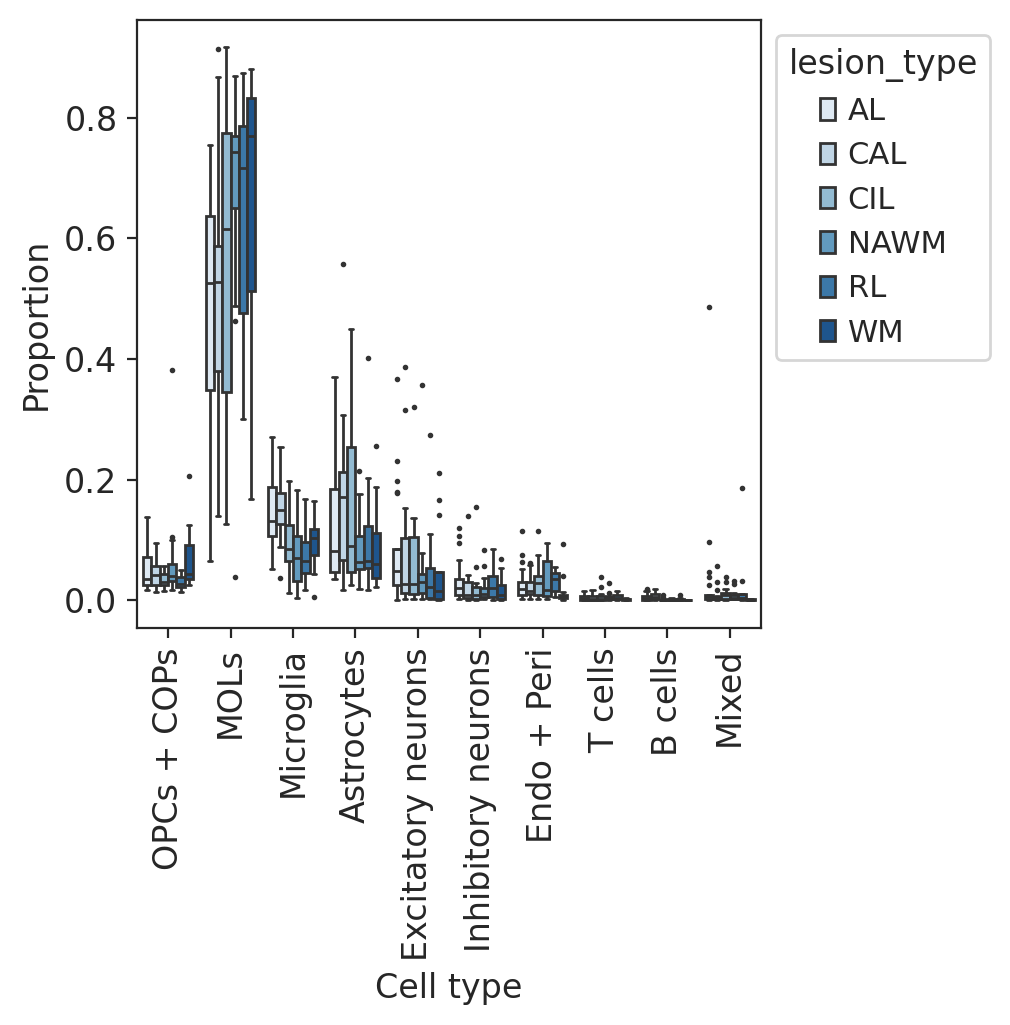

In [42]:
pt.pl.coda.boxplots(sccoda_data, modality_key="coda_hs", feature_name="lesion_type", add_dots=False)
plt.show()

/tmp/ipykernel_2507117/1403398411.py:1: FutureWarning: This function is deprecated and will be removed in pertpy 0.8.0! Please use the corresponding 'pt.tl' object for plotting function directly.
  pt.pl.coda.rel_abundance_dispersion_plot(sccoda_data, modality_key="coda_hs", abundant_threshold=0.9)


<Axes: xlabel='Presence', ylabel='Total dispersion'>

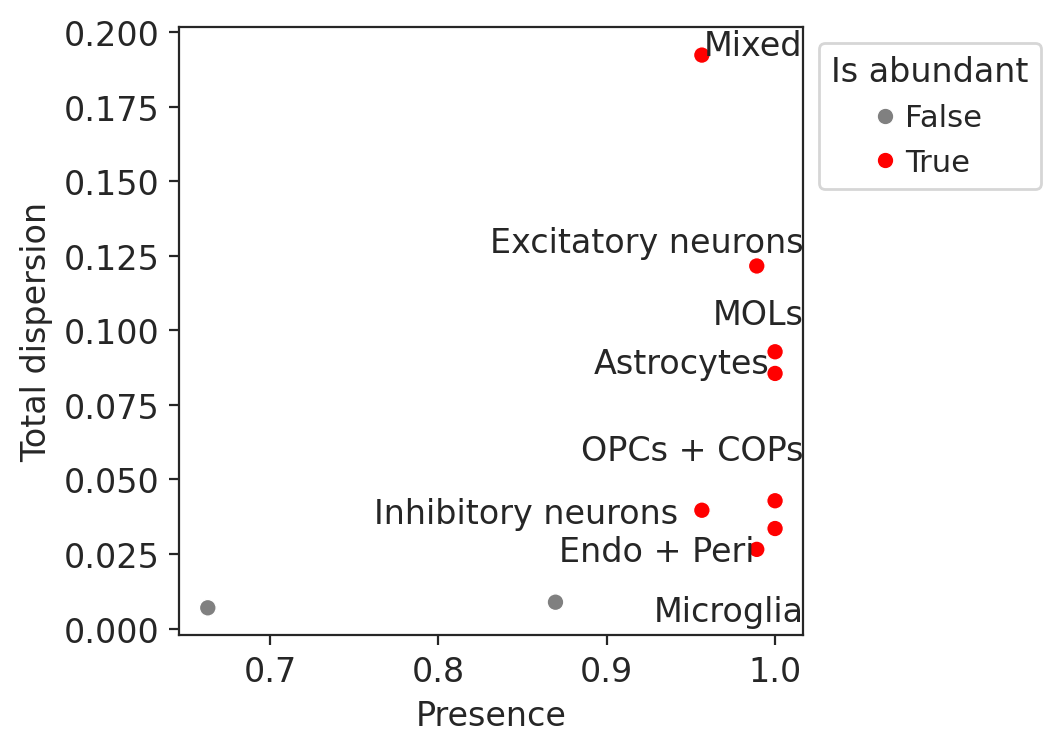

In [43]:
pt.pl.coda.rel_abundance_dispersion_plot(sccoda_data, modality_key="coda_hs", abundant_threshold=0.9)

In [56]:
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda_hs",
    formula="C(lesion_type, Treatment('WM'))",
    reference_cell_type="Endo + Peri",
)
sccoda_data["coda_hs"]

AnnData object with n_obs × n_vars = 92 × 10
    obs: 'sample_id', 'publication', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'library_type', 'sample_type', 'organism', 'system', 'pmi_hours', 'group'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_lesion_type[T.CAL]', 'effect_df_lesion_type[T.CIL]', 'effect_df_lesion_type[T.NAWM]', 'effect_df_lesion_type[T.RL]', 'effect_df_lesion_type[T.WM]'

In [57]:
# Run MCMC
sccoda_model.run_nuts(sccoda_data, modality_key="coda_hs")
sccoda_data["coda_hs"]

sample: 100%|████████████████| 11000/11000 [06:16<00:00, 29.22it/s, 255 steps of size 2.06e-02. acc. prob=0.80]


AnnData object with n_obs × n_vars = 92 × 10
    obs: 'sample_id', 'publication', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'library_type', 'sample_type', 'organism', 'system', 'pmi_hours', 'group'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_lesion_type[T.CAL]', 'effect_df_lesion_type[T.CIL]', 'effect_df_lesion_type[T.NAWM]', 'effect_df_lesion_type[T.RL]', 'effect_df_lesion_type[T.WM]', "effect_df_C(lesion_type, Treatment('WM'))[T.AL]", "effect_df_C(lesion_type, Treatment('WM'))[T.CAL]", "effect_df_C(lesion_type, Treatment('WM'))[T.CIL]", "effect_df_C(lesion_type, Treatment('WM'))[T.NAWM]", "effect_df_C(lesion_type, Treatment('WM'))[T.RL]"

In [58]:
sccoda_model.summary(sccoda_data, modality_key="coda_hs")

                                          Compositional Analysis summary                                           
┌────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────┐
│ Name                                       │ Value                                                              │
├────────────────────────────────────────────┼────────────────────────────────────────────────────────────────────┤
│ Data                                       │ Data: 92 samples, 10 cell types                                    │
│ Reference cell type                        │ Endo + Peri                                                        │
│ Formula                                    │ C(lesion_type, Treatment('WM'))                                    │
└────────────────────────────────────────────┴────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                     Final Parameter  Expected Sample                                                            │
│ Cell Type                                                                                                       │
│ OPCs + COPs              0.111           212.166                                                                │
│ MOLs                     2.374          2039.318                                                                │
│ Microglia                0.617           351.908                                                                │
│ Astrocytes               0.626           355.090                                                                │
│ Excitatory neurons      -0.260           146.404                                                                │
│ Inhibitory neurons      -0.640           100.120                                                                │
│ Endo + Peri             -0.444           121.799                                                                │
│ T cells                 -1.191            57.707                                                                │
│ B cells                 -1.438            45.077                                                                │
│ Mixed                   -1.057            65.981                                                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                           Final Parameter  Expected Sample  log2-fold change    │
│ Covariate                             Cell Type                                                                 │
│ C(lesion_type, Treatment('WM'))T.AL   OPCs + COPs              0.000           269.434            0.345         │
│                                       MOLs                    -0.453          1646.247           -0.309         │
│                                       Microglia                0.000           446.895            0.345         │
│                                       Astrocytes               0.000           450.936            0.345         │
│                                       Excitatory neurons       0.000           185.921            0.345         │
│                                       Inhibitory neurons       0.000           127.145            0.345         │
│                                       Endo + Peri              0.000           154.675            0.345         │
│                                       T cells                  0.000            73.283            0.345         │
│                                       B cells                  0.000            57.244            0.345         │
│                                       Mixed                    0.000            83.791            0.345         │
│ C(lesion_type, Treatment('WM'))T.CAL  OPCs + COPs              0.000           261.172            0.300         │
│                                       MOLs                    -0.388          1702.954           -0.260         │
│                                       Microglia                0.000           433.192            0.300         │
│                                       Astrocytes               0.000           437.108            0.300         │
│                                       Excitatory neurons       0.000           180.220            0.300         │
│                                       Inhibitory neurons       0.000           123.246            0.300         │
│                                       Endo + Peri              0.000           149.932            0.300         │
│                                       T cells                  0.000            71.036            0.300         │
│                                       B cells                  0.000            55.489            0.300         │
│                                       Mixed                    0.000            81.222            0.300         │
│ C(lesion_type, Treatment('WM'))T.CIL  OPCs + COPs              0.000           212.166            0.000         │
│                                       MOLs                     0.000          2039.318            0.000         │
│                                       Microglia                0.000           351.908            0.000         │
│                                       Astrocytes               0.000           355.090            0.000         │
│                                       Excitatory neurons       0.000           146.404            0.000         │
│                                       Inhibitory neurons       0.000           100.120            0.000         │
│                                       Endo + Peri              0.000           121.799            0.000         │
│                                       T cells                  0.000            57.707            0.000         │
│                                       B cells                  0.000            45.077            0.000         │
│                                       Mixed           

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


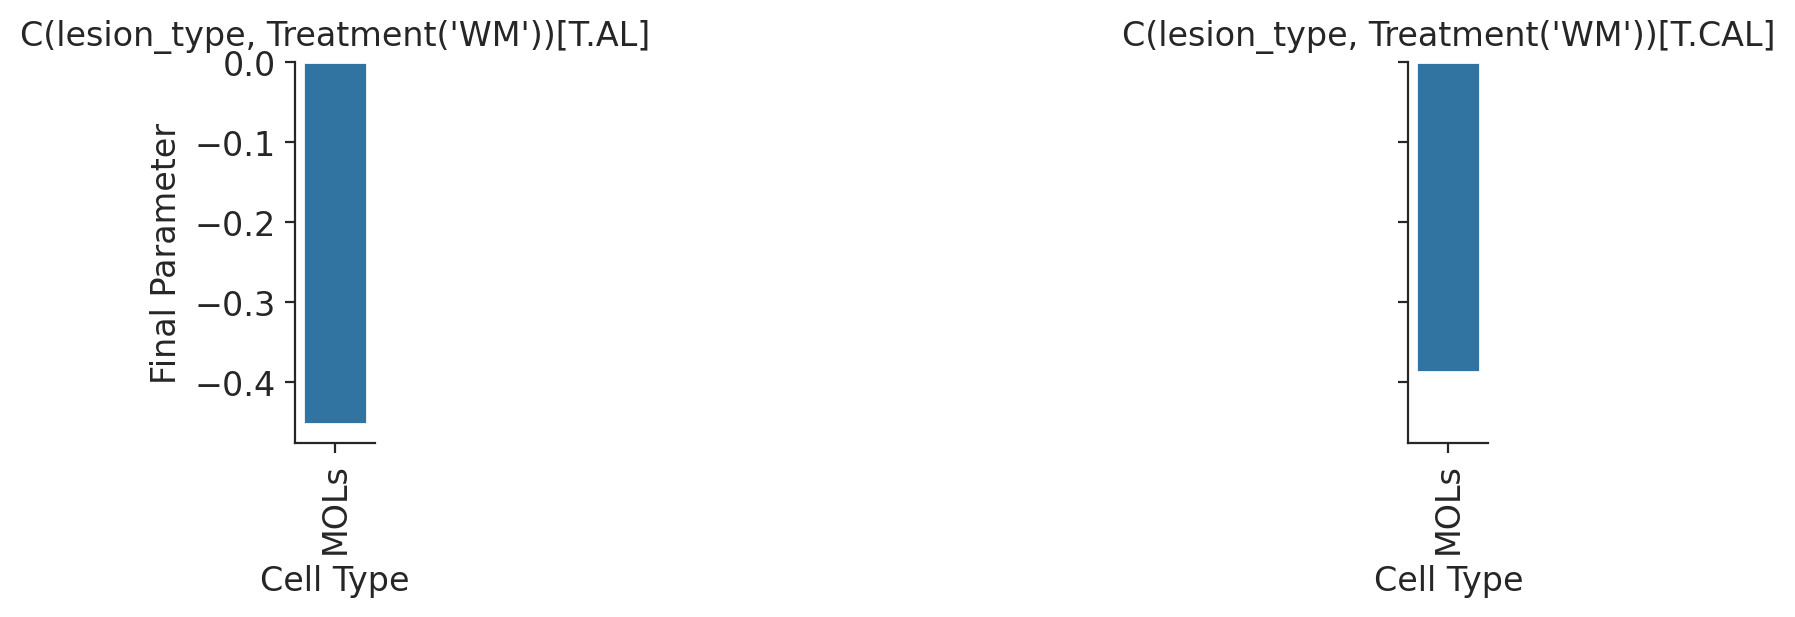

In [59]:
sccoda_model.plot_effects_barplot(sccoda_data, modality_key="coda_hs", parameter="Final Parameter")

/tmp/ipykernel_2507117/3280815692.py:1: FutureWarning: This function is deprecated and will be removed in pertpy 0.8.0! Please use the corresponding 'pt.tl' object for plotting function directly.
  pt.pl.coda.stacked_barplot(sccoda_data, modality_key="coda_hs", feature_name="lesion_type")


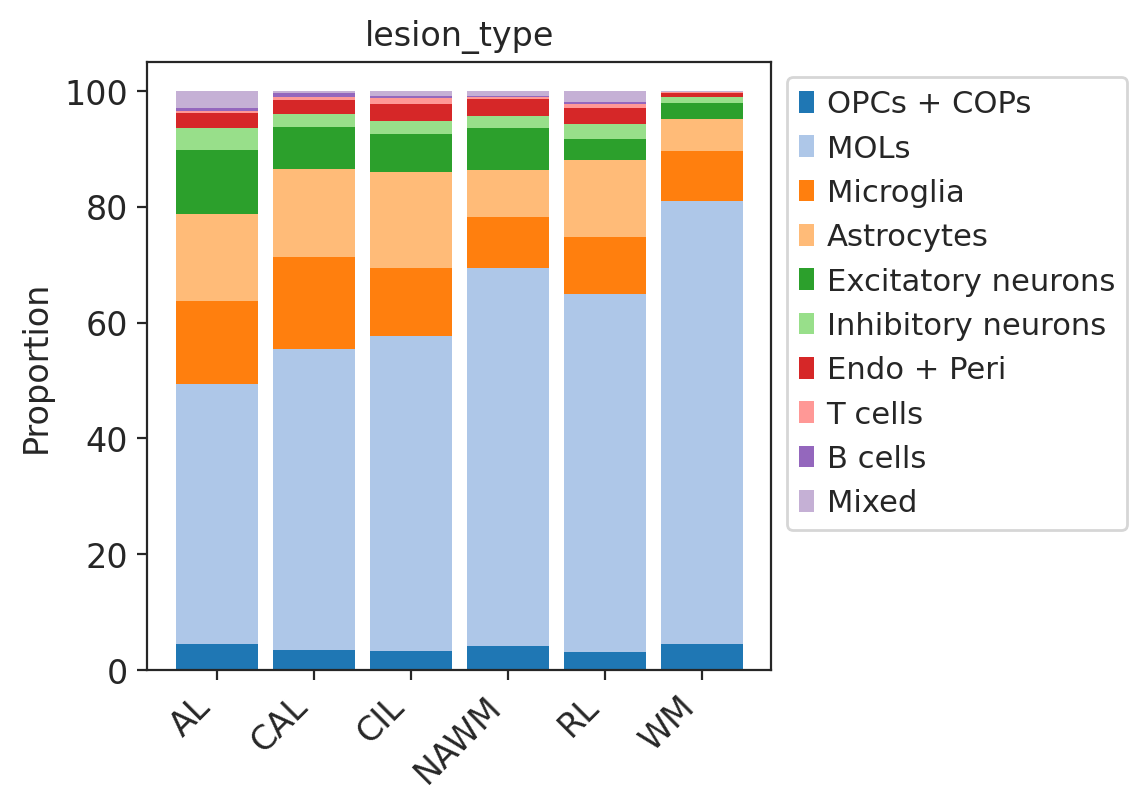

In [60]:
pt.pl.coda.stacked_barplot(sccoda_data, modality_key="coda_hs", feature_name="lesion_type")
plt.show()

In [61]:
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda_hs",
    formula="C(lesion_type, Treatment('WM'))",
    reference_cell_type="Inhibitory neurons",
)
sccoda_data["coda_hs"]

AnnData object with n_obs × n_vars = 92 × 10
    obs: 'sample_id', 'publication', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'library_type', 'sample_type', 'organism', 'system', 'pmi_hours', 'group'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_lesion_type[T.CAL]', 'effect_df_lesion_type[T.CIL]', 'effect_df_lesion_type[T.NAWM]', 'effect_df_lesion_type[T.RL]', 'effect_df_lesion_type[T.WM]', "effect_df_C(lesion_type, Treatment('WM'))[T.AL]", "effect_df_C(lesion_type, Treatment('WM'))[T.CAL]", "effect_df_C(lesion_type, Treatment('WM'))[T.CIL]", "effect_df_C(lesion_type, Treatment('WM'))[T.NAWM]", "effect_df_C(lesion_type, Treatment('WM'))[T.RL]"

In [62]:
# Run MCMC
sccoda_model.run_nuts(sccoda_data, modality_key="coda_hs")
sccoda_data["coda_hs"]

sample: 100%|████████████████| 11000/11000 [03:59<00:00, 45.97it/s, 127 steps of size 2.49e-02. acc. prob=0.75]


AnnData object with n_obs × n_vars = 92 × 10
    obs: 'sample_id', 'publication', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'library_type', 'sample_type', 'organism', 'system', 'pmi_hours', 'group'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_lesion_type[T.CAL]', 'effect_df_lesion_type[T.CIL]', 'effect_df_lesion_type[T.NAWM]', 'effect_df_lesion_type[T.RL]', 'effect_df_lesion_type[T.WM]', "effect_df_C(lesion_type, Treatment('WM'))[T.AL]", "effect_df_C(lesion_type, Treatment('WM'))[T.CAL]", "effect_df_C(lesion_type, Treatment('WM'))[T.CIL]", "effect_df_C(lesion_type, Treatment('WM'))[T.NAWM]", "effect_df_C(lesion_type, Treatment('WM'))[T.RL]"

In [63]:
sccoda_model.summary(sccoda_data, modality_key="coda_hs")

                                          Compositional Analysis summary                                           
┌────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────┐
│ Name                                       │ Value                                                              │
├────────────────────────────────────────────┼────────────────────────────────────────────────────────────────────┤
│ Data                                       │ Data: 92 samples, 10 cell types                                    │
│ Reference cell type                        │ Inhibitory neurons                                                 │
│ Formula                                    │ C(lesion_type, Treatment('WM'))                                    │
└────────────────────────────────────────────┴────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                     Final Parameter  Expected Sample                                                            │
│ Cell Type                                                                                                       │
│ OPCs + COPs              0.110           212.265                                                                │
│ MOLs                     2.371          2036.186                                                                │
│ Microglia                0.620           353.482                                                                │
│ Astrocytes               0.625           355.254                                                                │
│ Excitatory neurons      -0.255           147.353                                                                │
│ Inhibitory neurons      -0.624           101.884                                                                │
│ Endo + Peri             -0.459           120.161                                                                │
│ T cells                 -1.188            57.965                                                                │
│ B cells                 -1.441            45.008                                                                │
│ Mixed                   -1.058            66.012                                                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                           Final Parameter  Expected Sample  log2-fold change    │
│ Covariate                             Cell Type                                                                 │
│ C(lesion_type, Treatment('WM'))T.AL   OPCs + COPs              0.000           270.265            0.349         │
│                                       MOLs                    -0.460          1637.414           -0.314         │
│                                       Microglia                0.000           450.070            0.349         │
│                                       Astrocytes               0.000           452.326            0.349         │
│                                       Excitatory neurons       0.000           187.617            0.349         │
│                                       Inhibitory neurons       0.000           129.723            0.349         │
│                                       Endo + Peri              0.000           152.995            0.349         │
│                                       T cells                  0.000            73.803            0.349         │
│                                       B cells                  0.000            57.306            0.349         │
│                                       Mixed                    0.000            84.049            0.349         │
│ C(lesion_type, Treatment('WM'))T.CAL  OPCs + COPs              0.000           212.265            0.000         │
│                                       MOLs                     0.000          2036.186            0.000         │
│                                       Microglia                0.000           353.482            0.000         │
│                                       Astrocytes               0.000           355.254            0.000         │
│                                       Excitatory neurons       0.000           147.353            0.000         │
│                                       Inhibitory neurons       0.000           101.884            0.000         │
│                                       Endo + Peri              0.000           120.161            0.000         │
│                                       T cells                  0.000            57.965            0.000         │
│                                       B cells                  0.000            45.008            0.000         │
│                                       Mixed                    0.000            66.012            0.000         │
│ C(lesion_type, Treatment('WM'))T.CIL  OPCs + COPs              0.000           212.265            0.000         │
│                                       MOLs                     0.000          2036.186            0.000         │
│                                       Microglia                0.000           353.482            0.000         │
│                                       Astrocytes               0.000           355.254            0.000         │
│                                       Excitatory neurons       0.000           147.353            0.000         │
│                                       Inhibitory neurons       0.000           101.884            0.000         │
│                                       Endo + Peri              0.000           120.161            0.000         │
│                                       T cells                  0.000            57.965            0.000         │
│                                       B cells                  0.000            45.008            0.000         │
│                                       Mixed           

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


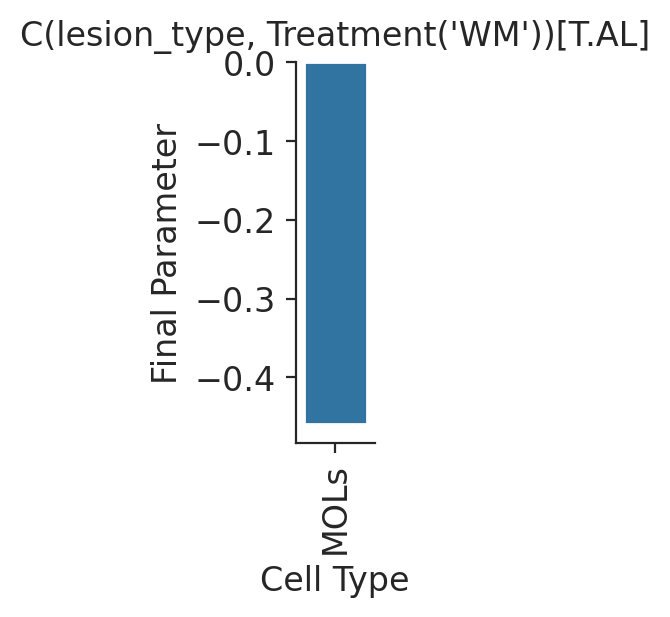

In [64]:
sccoda_model.plot_effects_barplot(sccoda_data, modality_key="coda_hs", parameter="Final Parameter")

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


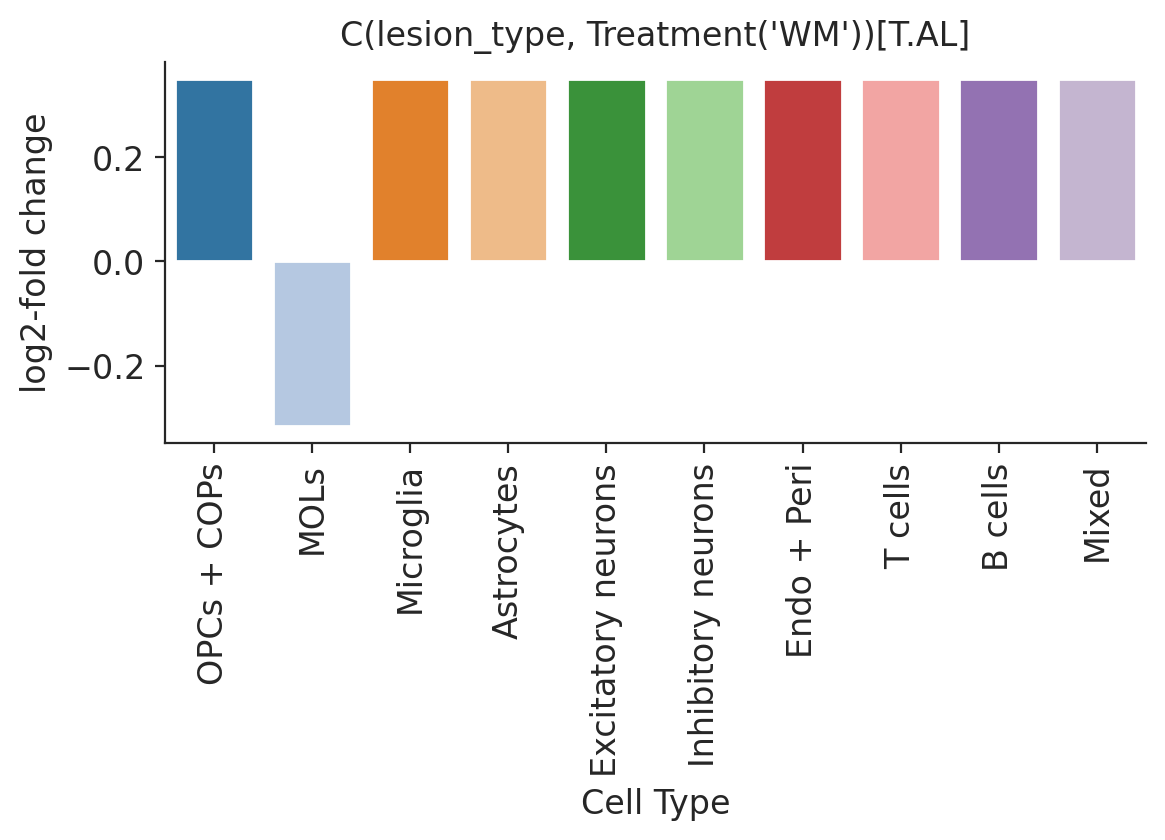

In [65]:
sccoda_model.plot_effects_barplot(sccoda_data, modality_key="coda_hs", parameter="log2-fold change")

# Age and variable distribution testing

In [40]:
adata_all

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DC

In [41]:
adata_all.obs[:5]

,sample_id,publication,sample_id_anon,individual_id_anon,replicate,treatment,condition,tissue,time,batch,...,scVI_leiden_0.5,scVI_leiden_1,cluster_annotation,cell_leiden_annotated,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,refined_cluster_annotation,pmi_hours,group
Ind98-Sample2:AAACCCATCCGTCAAA-1,Human_MS,Macnair et al. biorxiv,Ind98-Sample2,Ind98,1,MS_patient,MS,White matter,34,31,...,1,1,MOLs,1_MOLs,28.619111,3.388420,1.058036,MOL3,99.0,CTR
Ind98-Sample2:AAACCCATCCTGGTCT-1,Human_MS,Macnair et al. biorxiv,Ind98-Sample2,Ind98,1,MS_patient,MS,White matter,34,31,...,2,3,Microglia,3_Microglia,17.697454,2.928387,1.021766,Microglia_B,99.0,CTR
Ind98-Sample2:AAACGAAGTTGTACGT-1,Human_MS,Macnair et al. biorxiv,Ind98-Sample2,Ind98,1,MS_patient,MS,White matter,34,31,...,4,7,MOLs,7_MOLs,11.204287,2.501787,0.330501,MOL3,99.0,CTR
Ind98-Sample2:AAACGCTAGCGTATGG-1,Human_MS,Macnair et al. biorxiv,Ind98-Sample2,Ind98,1,MS_patient,MS,White matter,34,31,...,3,9,Astrocytes,9_Astrocytes,18.327815,2.961545,0.801361,Astro_A,99.0,CTR
Ind98-Sample2:AAACGCTCAGTTGGTT-1,Human_MS,Macnair et al. biorxiv,Ind98-Sample2,Ind98,1,MS_patient,MS,White matter,34,31,...,0,2,MOLs,2_MOLs,28.825822,3.395375,2.225623,MOL2,99.0,CTR


In [42]:
base_df = adata_all.obs[['individual_id_anon', 'age_at_death', 'group', 'sex', 'diagnosis']].drop_duplicates()

In [43]:
# Compute mean and standard deviation of age at death per group
age_stats = base_df.groupby('group')['age_at_death'].agg(['mean', 'std']).reset_index()

# Format as "mean ± std" string
age_stats['mean ± SD'] = age_stats.apply(
    lambda row: f"{row['mean']:.1f} ± {row['std']:.1f}", axis=1
)

print(age_stats[['group', 'mean ± SD']])

group    mean ± SD
0   CTR  64.8 ± 17.4
1    MS  59.2 ± 14.1

In [55]:
base_df = adata_all.obs[['individual_id_anon', 'age_at_death', 'group', 'sex', 'diagnosis', 'pmi_hours']].drop_duplicates()

# Compute mean and standard deviation of age at death per group
pmi_stats = base_df.groupby('group')['pmi_hours'].agg(['mean', 'std']).reset_index()

# Format as "mean ± std" string
pmi_stats['mean ± SD'] = pmi_stats.apply(
    lambda row: f"{row['mean']:.1f} ± {row['std']:.1f}", axis=1
)

print(pmi_stats[['group', 'mean ± SD']])

group    mean ± SD
0   CTR  35.4 ± 40.0
1    MS   11.1 ± 9.2

In [45]:
large_df = adata_all.obs[['sample_id_anon', 'age_at_death', 'group', 'sex', 'diagnosis', 
                         'pmi_hours', 'lesion_type']].drop_duplicates()

# Count total number of each lesion_type
lesion_totals = large_df['lesion_type'].value_counts().reset_index()

# Rename columns for clarity
lesion_totals.columns = ['lesion_type', 'count']

print(lesion_totals)

lesion_type  count
0          AL     21
1         CAL     17
2        NAWM     17
3         CIL     13
4          WM     13
5          RL     11

In [46]:
# Group by 'group' and 'sex' and count the number of individuals
group_sex_counts = base_df.groupby(['group', 'sex']).size().reset_index(name='count')

print(group_sex_counts)

/tmp/ipykernel_1019427/3875324079.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sex_counts = base_df.groupby(['group', 'sex']).size().reset_index(name='count')


group sex  count
0   CTR   F      5
1   CTR   M      8
2    MS   F     20
3    MS   M     14

In [47]:
# Count unique individuals per diagnosis
diagnosis_table = base_df.groupby('diagnosis')['individual_id_anon'].nunique().reset_index(name='n_individuals')

# Optional: sort by count
diagnosis_table = diagnosis_table.sort_values(by='n_individuals', ascending=False)

print(diagnosis_table)

diagnosis  n_individuals
3      SPMS             19
0       CTR             13
1      PPMS             13
2      RRMS              2

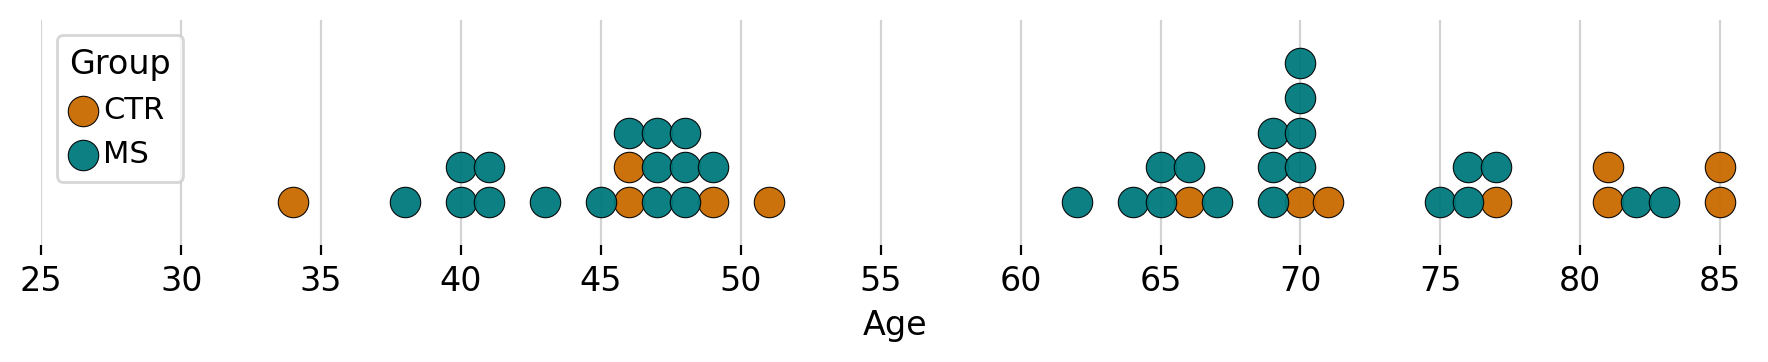

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data
individual_df = base_df[['individual_id_anon', 'age_at_death', 'group']].copy()
individual_df['age_bin'] = individual_df['age_at_death'].round(0)
individual_df = individual_df.sort_values(by=['group', 'age_bin'])

dot_spacing = 0.4
group_colors = {'CTR': '#ca6a00', 'MS': '#00797d'}  # Changed 'control' to 'CTR' #ca6a00

# Filter age_bin between 25 and 85 (inclusive)
individual_df = individual_df[(individual_df['age_bin'] >= 25) & (individual_df['age_bin'] <= 85)]

# Calculate counts per age and group
counts = individual_df.groupby(['age_bin', 'group']).size().unstack(fill_value=0)

# Initialize stacking positions column
individual_df['stack_pos'] = np.nan

# Explicit stacking order: CTR first (bottom), MS above
group_order = ['CTR', 'MS']  # Changed 'control' to 'CTR'

# Assign stacking positions so CTR dots plot first at bottom, MS stacked above
for age in counts.index:
    current_stack_base = 0
    for group in group_order:
        if group in counts.columns and counts.loc[age, group] > 0:
            idxs = individual_df[(individual_df['age_bin'] == age) & (individual_df['group'] == group)].index
            n = len(idxs)
            individual_df.loc[idxs, 'stack_pos'] = np.arange(n) + current_stack_base
            current_stack_base += n

# Plotting
plt.figure(figsize=(9, 2))

for group in group_order:
    group_data = individual_df[individual_df['group'] == group]
    y_vals = group_data['stack_pos'] * dot_spacing
    plt.scatter(group_data['age_bin'],
                y_vals,
                label=group,
                color=group_colors[group],
                s=120,
                alpha=0.95,
                edgecolor='black',
                linewidth=0.4)

# X-axis ticks and vertical grid lines
min_age = 25
max_age = int(individual_df['age_bin'].max()) + 1
tick_locs = np.arange(min_age, max_age + 1, 5)

for x in tick_locs:
    plt.axvline(x=x, color='lightgray', linestyle='-', linewidth=0.8, zorder=0)

# Axis limits and labels
plt.xlim(min_age, max_age)
plt.xticks(tick_locs)
plt.yticks([])
plt.xlabel('Age')
plt.legend(title='Group', loc='upper left')

# Remove spines and grid
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.grid(False)

# Adjust y-axis limits dynamically based on maximum stack height
max_stack_height = individual_df['stack_pos'].max()
plt.ylim(-0.5, max_stack_height * dot_spacing + 0.5)

plt.tight_layout()
plt.savefig("stacked_dotplot_age_by_group_CTR_bottom.png", dpi=300)
plt.show()

/tmp/ipykernel_1019427/1190428245.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = individual_df.groupby(['age_bin', 'sex']).size().unstack(fill_value=0)


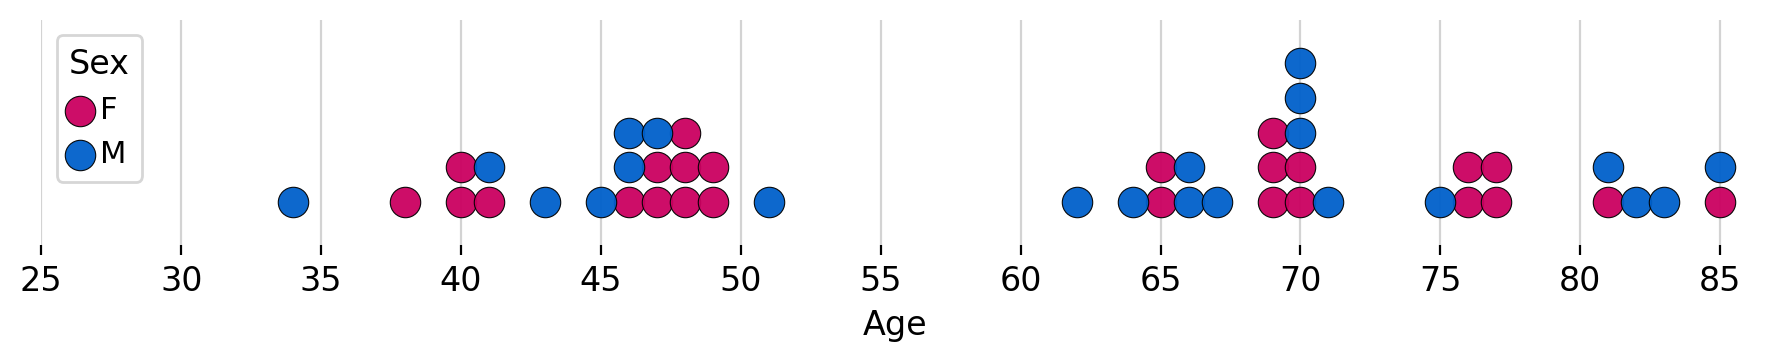

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data
individual_df = base_df[['individual_id_anon', 'age_at_death', 'sex']].copy()
individual_df['age_bin'] = individual_df['age_at_death'].round(0)
individual_df = individual_df.sort_values(by=['sex', 'age_bin'])

dot_spacing = 0.4
sex_colors = {'F': '#cb0060', 'M': '#0060cb'}

# Calculate counts per age and sex
counts = individual_df.groupby(['age_bin', 'sex']).size().unstack(fill_value=0)

# Create a new column for stacking position
individual_df['stack_pos'] = np.nan

# Get unique sexes (in sorted order for consistent stacking)
sex_order = sorted(individual_df['sex'].unique())

# Assign stacking positions per age_bin dynamically
for age in counts.index:
    present_sexes = [sex for sex in sex_order if counts.loc[age, sex] > 0]
    current_stack_base = 0
    
    for sex in present_sexes:
        idxs = individual_df[(individual_df['age_bin'] == age) & (individual_df['sex'] == sex)].index
        n = len(idxs)
        individual_df.loc[idxs, 'stack_pos'] = np.arange(n) + current_stack_base
        current_stack_base += n

# Plotting
plt.figure(figsize=(9, 2))

for sex in sex_order:
    sex_data = individual_df[individual_df['sex'] == sex]
    y_vals = sex_data['stack_pos'] * dot_spacing
    plt.scatter(sex_data['age_bin'],
                y_vals,
                label=sex,
                color=sex_colors[sex],
                s=120,
                alpha=0.95,
                edgecolor='black',
                linewidth=0.4)

# X-axis ticks and vertical grid lines
min_age = 25
max_age = int(individual_df['age_bin'].max()) + 1
tick_locs = np.arange(min_age, max_age + 1, 5)

for x in tick_locs:
    plt.axvline(x=x, color='lightgray', linestyle='-', linewidth=0.8, zorder=0)

# Clean aesthetics
plt.xlim(min_age, max_age)
plt.xticks(tick_locs)
plt.yticks([])
plt.xlabel('Age')
plt.legend(title='Sex', loc='upper left')

# Remove spines and grid
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.grid(False)

# Adjust y-axis limits dynamically
max_stack_height = individual_df['stack_pos'].max()
plt.ylim(-0.5, max_stack_height * dot_spacing + 0.5)

plt.tight_layout()
plt.savefig("stacked_dotplot_age_by_sex.png", dpi=300)
plt.show()

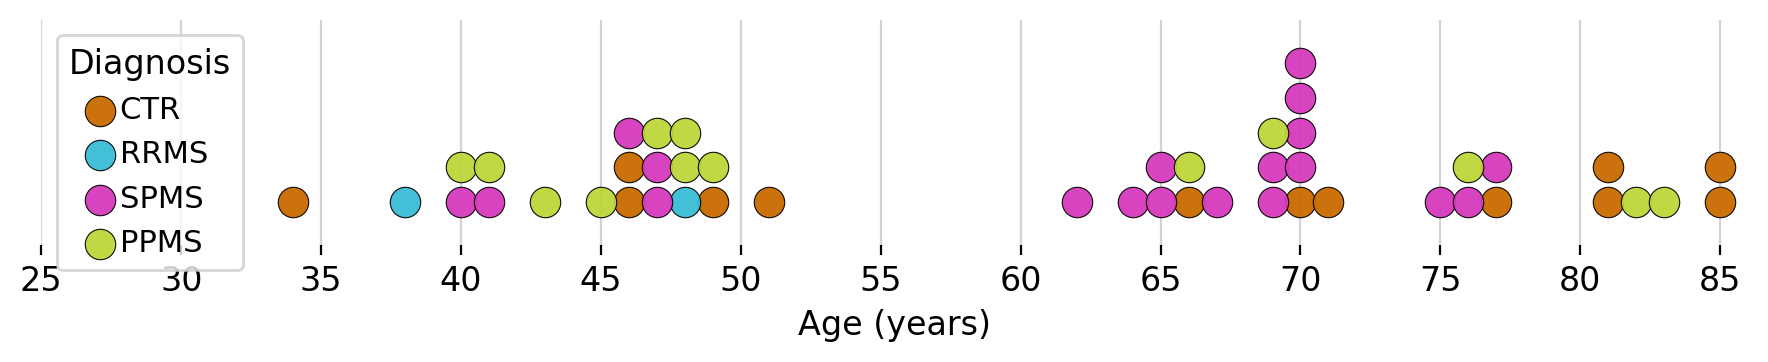

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data
individual_df = base_df[['individual_id_anon', 'age_at_death', 'diagnosis']].copy()
individual_df['age_bin'] = individual_df['age_at_death'].round(0)
individual_df = individual_df.sort_values(by=['diagnosis', 'age_bin'])

dot_spacing = 0.4
diagnosis_colors = {
    'CTR': '#ca6a00',    # Gray
    'SPMS': '#d63abc',   # Orange-brown
    'RRMS': '#3abcd6',   # Teal
    'PPMS': '#bcd63a'    # Purple
}

# Explicit diagnosis order for stacking and plotting
diagnosis_order = ['CTR', 'RRMS', 'SPMS', 'PPMS']

# Calculate counts per age and diagnosis
counts = individual_df.groupby(['age_bin', 'diagnosis']).size().unstack(fill_value=0)

# Initialize stacking positions column
individual_df['stack_pos'] = np.nan

# Assign stacking positions per age_bin dynamically based on explicit order
for age in counts.index:
    present_diags = [diag for diag in diagnosis_order if diag in counts.columns and counts.loc[age, diag] > 0]
    current_stack_base = 0
    
    for diag in present_diags:
        idxs = individual_df[(individual_df['age_bin'] == age) & (individual_df['diagnosis'] == diag)].index
        n = len(idxs)
        individual_df.loc[idxs, 'stack_pos'] = np.arange(n) + current_stack_base
        current_stack_base += n

# Plotting
plt.figure(figsize=(9, 2))

for diag in diagnosis_order:
    diag_data = individual_df[individual_df['diagnosis'] == diag]
    y_vals = diag_data['stack_pos'] * dot_spacing
    plt.scatter(diag_data['age_bin'],
                y_vals,
                label=diag,
                color=diagnosis_colors.get(diag, 'gray'),
                s=120,
                alpha=0.95,
                edgecolor='black',
                linewidth=0.4)

# X-axis ticks and vertical grid lines
min_age = 25
max_age = int(individual_df['age_bin'].max()) + 1
tick_locs = np.arange(min_age, max_age + 1, 5)

for x in tick_locs:
    plt.axvline(x=x, color='lightgray', linestyle='-', linewidth=0.8, zorder=0)

# Clean aesthetics
plt.xlim(min_age, max_age)
plt.xticks(tick_locs)
plt.yticks([])
plt.xlabel('Age (years)')
plt.legend(title='Diagnosis', loc='upper left')

# Remove spines and grid
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.grid(False)

# Adjust y-axis limits dynamically
max_stack_height = individual_df['stack_pos'].max()
plt.ylim(-0.5, max_stack_height * dot_spacing + 0.5)

plt.tight_layout()
plt.savefig("stacked_dotplot_age_by_diagnosis_ordered.png", dpi=300)
plt.show()

In [57]:
base_df = adata_all.obs[['individual_id_anon', 'age_at_death', 'group', 'sex', 'diagnosis']].drop_duplicates()

In [59]:
from scipy.stats import shapiro

# Split data
ages_control = base_df[base_df['group'] == 'CTR']['age_at_death']
ages_ms = base_df[base_df['group'] == 'MS']['age_at_death']

# Shapiro-Wilk test
shapiro_control = shapiro(ages_control)
shapiro_ms = shapiro(ages_ms)

print("Shapiro-Wilk Test for Normality:")
print(f"Control group: W={shapiro_control.statistic:.4f}, p={shapiro_control.pvalue:.4f}")
print(f"MS group:      W={shapiro_ms.statistic:.4f}, p={shapiro_ms.pvalue:.4f}")

Shapiro-Wilk Test for Normality:

Control group: W=0.8999, p=0.1334

MS group:      W=0.8983, p=0.0041

In [60]:
def find_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data < lower) | (data > upper)]

# Find outliers
outliers_control = find_outliers(ages_control)
outliers_ms = find_outliers(ages_ms)

print("\nOutliers (IQR method):")
print(f"Control group: {list(outliers_control)}")
print(f"MS group:      {list(outliers_ms)}")

Outliers (IQR method):

Control group: []

MS group:      []

In [61]:
from scipy.stats import ttest_ind, mannwhitneyu

# T-test (equal_var=False just in case variances differ)
t_res = ttest_ind(ages_control, ages_ms, equal_var=False)

# Mann-Whitney U test
u_res = mannwhitneyu(ages_control, ages_ms, alternative='two-sided')

print("\nStatistical Tests:")
print(f"T-test:        t={t_res.statistic:.4f}, p={t_res.pvalue:.4f}")
print(f"Mann-Whitney:  U={u_res.statistic:.4f}, p={u_res.pvalue:.4f}")

Statistical Tests:

T-test:        t=1.0280, p=0.3173

Mann-Whitney:  U=281.5000, p=0.1531

/tmp/ipykernel_1019427/61696415.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=individual_df, x='group', y='age_at_death', palette=custom_palette)
/tmp/ipykernel_1019427/61696415.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups)


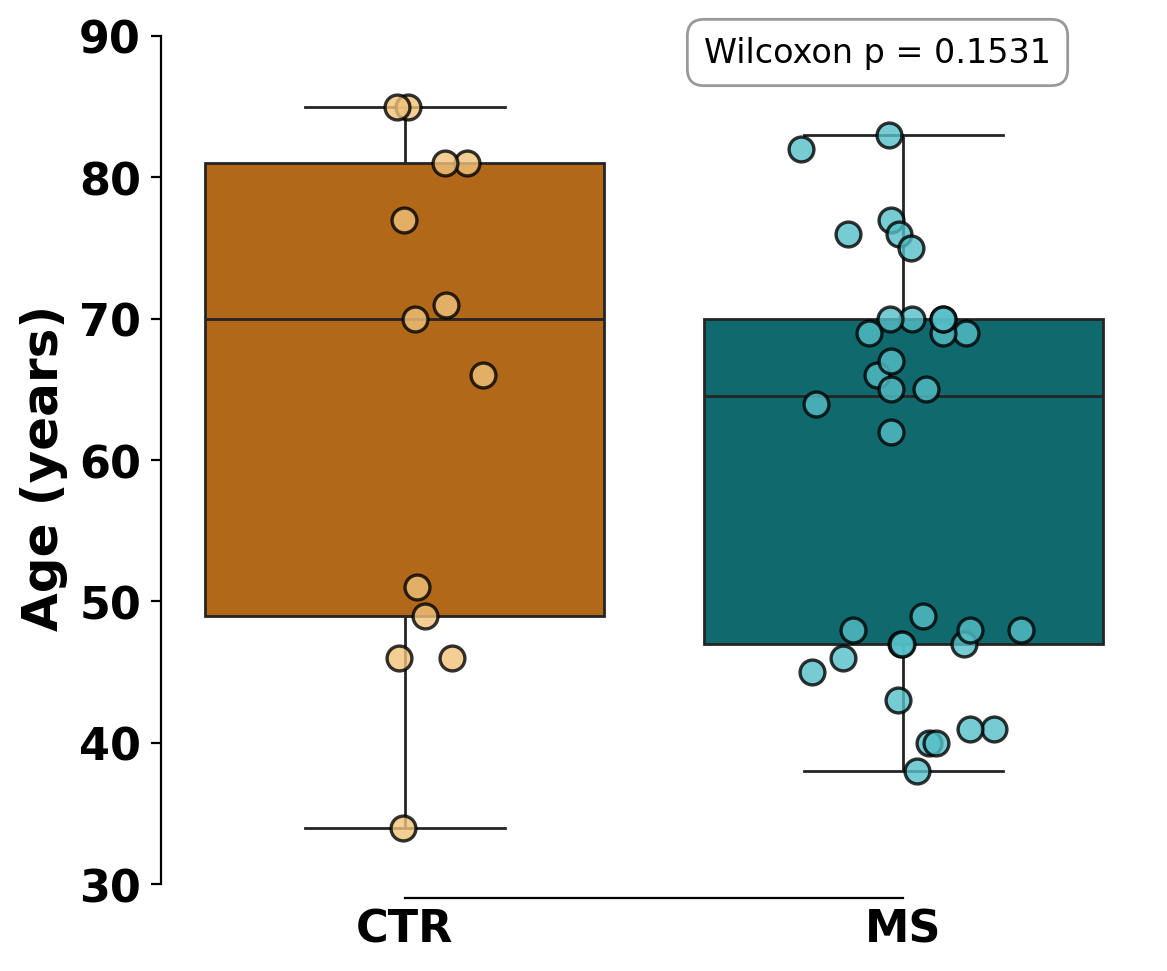

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
individual_df = adata_all.obs[['individual_id_anon', 'age_at_death', 'group']].drop_duplicates()

# Custom colors
custom_palette = {
    'CTR': '#ca6a00',
    'MS': '#00797d'
}

fill_palette = {
    'CTR': '#f0c27b',  # lighter orange
    'MS': '#55bfc7'        # lighter teal
}

# Stats to annotate
mannwhitney_p = 0.1531

# Calculate y-limits with padding
min_age = individual_df['age_at_death'].min()
max_age = individual_df['age_at_death'].max()
y_padding = 5
y_min = max(0, min_age - y_padding)
y_max = max_age + y_padding

plt.figure(figsize=(6, 5))
ax = sns.boxplot(data=individual_df, x='group', y='age_at_death', palette=custom_palette)

# Remove x-axis line but keep labels without ticks
ax.spines['bottom'].set_visible(False)
groups = individual_df['group'].unique()
ax.set_xticklabels(groups)
ax.tick_params(axis='x', which='both', length=0)

positions = range(len(groups))
for pos, group in zip(positions, groups):
    subset = individual_df[individual_df['group'] == group]
    y = subset['age_at_death']

    jitter_strength = 0.1
    x_jittered = np.random.normal(loc=pos, scale=jitter_strength, size=len(subset))

    plt.scatter(x_jittered, y,
                s=80,
                facecolors=fill_palette[group],
                edgecolors='black',
                linewidth=1.2,
                alpha=0.8,
                marker='o',
                zorder=10)

# Simplified annotation text with just Wilcoxon p-value
annotation_text = f"Wilcoxon p = {mannwhitney_p:.4f}"

# Position annotation inside plot (x,y coords in data coords)
x_pos = 0.6  # just outside the last group on x-axis
y_pos = 90  # near top

plt.text(x_pos, y_pos, annotation_text,
         fontsize=12, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Make text larger and bold
plt.ylabel('Age (years)', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')   

plt.ylim(y_min, y_max)
plt.grid(False)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("boxplot_age_by_group_stats.png", dpi=300)
plt.show()

/tmp/ipykernel_1019427/2554774964.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=individual_df, x='group', y='age_at_death', palette=custom_palette)
/tmp/ipykernel_1019427/2554774964.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups)


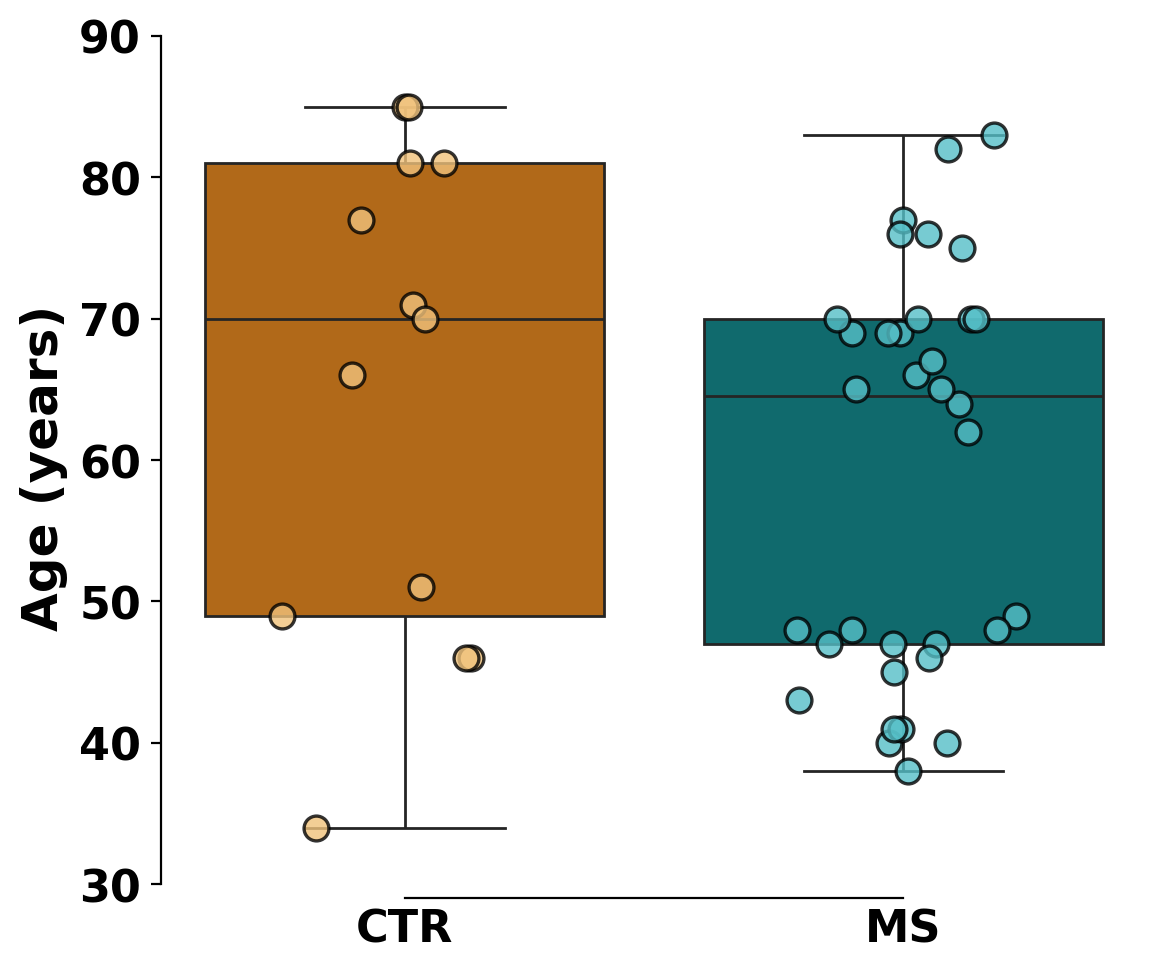

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
individual_df = adata_all.obs[['individual_id_anon', 'age_at_death', 'group']].drop_duplicates()

# Custom colors
custom_palette = {
    'CTR': '#ca6a00',
    'MS': '#00797d'
}

fill_palette = {
    'CTR': '#f0c27b',  # example lighter orange
    'MS': '#55bfc7'        # example lighter teal
}

# Calculate y-limits with padding
min_age = individual_df['age_at_death'].min()
max_age = individual_df['age_at_death'].max()
y_padding = 5  # adjust if needed
y_min = max(0, min_age - y_padding)
y_max = max_age + y_padding

# Plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(data=individual_df, x='group', y='age_at_death', palette=custom_palette)

# Remove the x-axis line (bottom spine)
ax.spines['bottom'].set_visible(False)

# Keep x-axis labels but remove ticks
groups = individual_df['group'].unique()
ax.set_xticklabels(groups)
ax.tick_params(axis='x', which='both', length=0)  # remove tick marks

# Manually plot dots with open circle markers and fill color + black edge
positions = range(len(groups))
for pos, group in zip(positions, groups):
    subset = individual_df[individual_df['group'] == group]
    y = subset['age_at_death']

    # Add jitter: random small values around pos
    jitter_strength = 0.1  # adjust for more/less jitter
    x_jittered = np.random.normal(loc=pos, scale=jitter_strength, size=len(subset))

    plt.scatter(x_jittered, y,
                s=80,
                facecolors=fill_palette[group],  # or custom_palette[group]
                edgecolors='black',
                linewidth=1.2,
                alpha=0.8,
                marker='o',
                zorder=10)

# Make text larger and bold
plt.ylabel('Age (years)', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')   

plt.ylim(y_min, y_max)
plt.grid(False)
sns.despine(trim=True)

# Clean up: remove top/right spines and grid
plt.grid(False)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("boxplot_age_by_group.png", dpi=300)
plt.show()

## Try on PMI (hours)

/tmp/ipykernel_2685739/3818392365.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups)


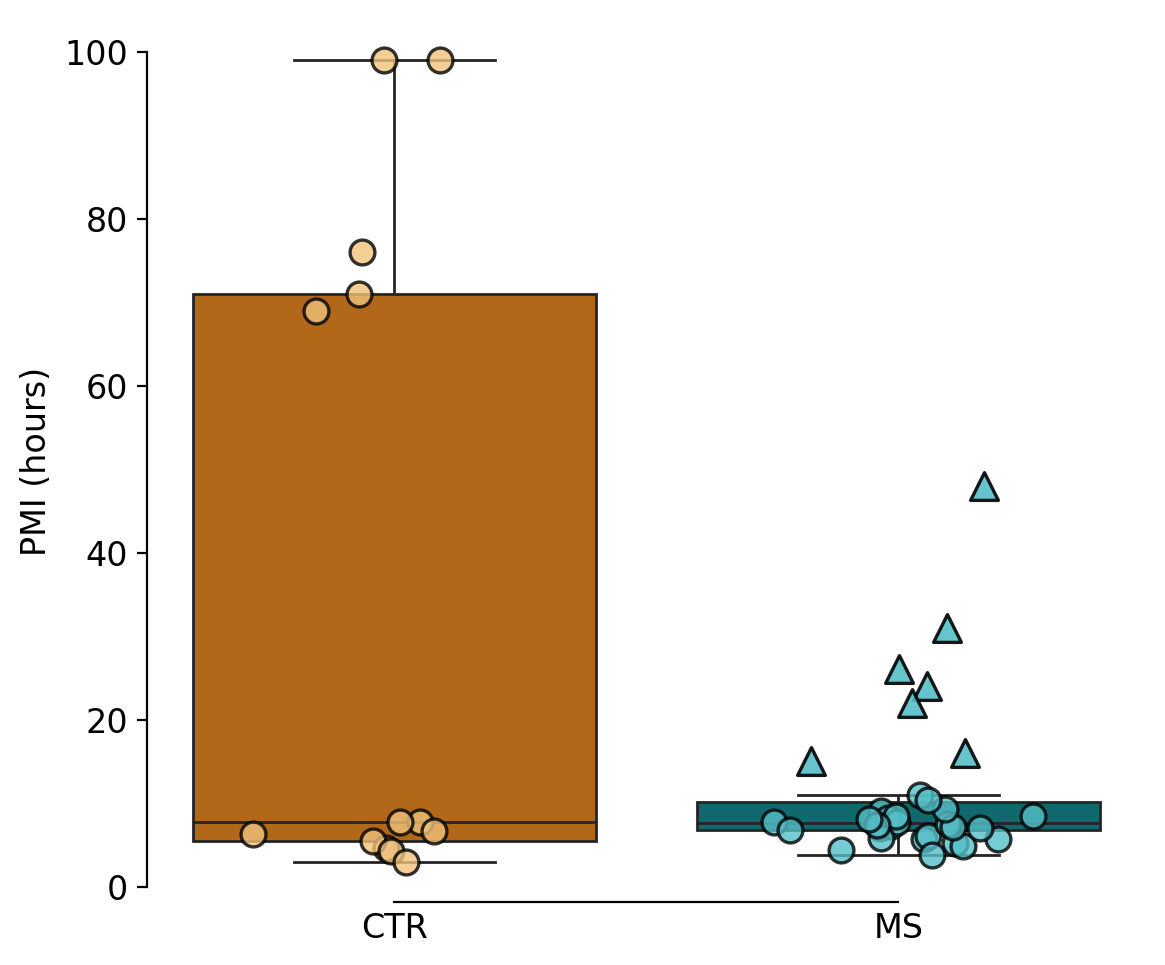

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data (drop duplicates to keep one value per individual)
individual_df = adata_all.obs[['individual_id_anon', 'pmi_hours', 'group']].drop_duplicates()

# Drop rows with missing PMI values
individual_df = individual_df.dropna(subset=['pmi_hours'])

# Custom colors
custom_palette = {
    'CTR': '#ca6a00',
    'MS': '#00797d'
}

fill_palette = {
    'CTR': '#f0c27b',  # lighter orange
    'MS': '#55bfc7'    # lighter teal
}

# Y-axis range with padding
min_pmi = individual_df['pmi_hours'].min()
max_pmi = individual_df['pmi_hours'].max()
y_padding = 2  # in hours
y_min = max(0, min_pmi - y_padding)
y_max = max_pmi + y_padding

# Plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=individual_df,
    x='group',
    y='pmi_hours',
    hue='group',
    palette=custom_palette,
    order=['CTR', 'MS'],
    hue_order=['CTR', 'MS'],
    dodge=False,
    legend=False,
    showfliers=False  # <- disables those automatic outlier dots
)

# Remove the x-axis line (bottom spine)
ax.spines['bottom'].set_visible(False)

# Customize x-axis labels and remove ticks
groups = individual_df['group'].unique()
ax.set_xticklabels(groups)
ax.tick_params(axis='x', which='both', length=0)

# Overlay jittered scatter points
positions = range(len(groups))

# Define outliers explicitly
outliers_ms = [26.0, 24.0, 16.0, 31.0, 48.0, 15.0, 22.0]

# Overlay jittered scatter points
for pos, group in enumerate(['CTR', 'MS']):
    subset = individual_df[individual_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))

    is_outlier = subset['pmi_hours'].isin(outliers_ms) if group == 'MS' else np.full(len(subset), False)
    
    # Plot non-outliers
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'pmi_hours'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )
    
    # Plot outliers with triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'pmi_hours'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',  # triangle
        zorder=11
    )

# Tidy up
plt.ylabel('PMI (hours)')
plt.xlabel('')
plt.grid(False)
sns.despine(trim=True)
plt.tight_layout()
plt.savefig("boxplot_pmi_by_group_outliers.png", dpi=300)
plt.show()

/tmp/ipykernel_1019427/1295865127.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['CTR', 'MS'])


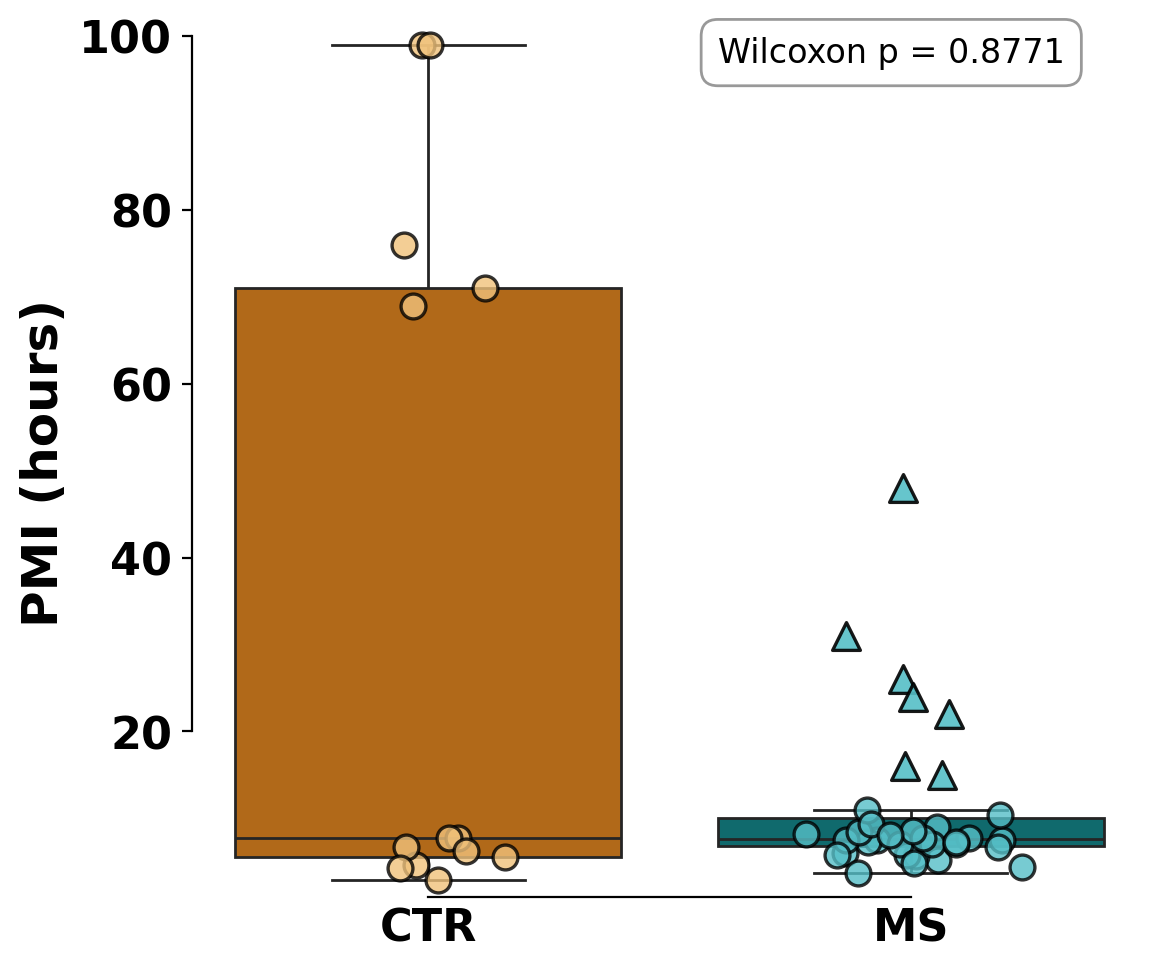

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
individual_df = adata_all.obs[['individual_id_anon', 'pmi_hours', 'group']].drop_duplicates()
individual_df = individual_df.dropna(subset=['pmi_hours'])

# Custom colors
custom_palette = {
    'CTR': '#ca6a00',
    'MS': '#00797d'
}

fill_palette = {
    'CTR': '#f0c27b',
    'MS': '#55bfc7'
}

# Define known outliers (from IQR method)
outliers_ms = [26.0, 24.0, 16.0, 31.0, 48.0, 15.0, 22.0]

# Compute y-axis limits
min_pmi = individual_df['pmi_hours'].min()
max_pmi = individual_df['pmi_hours'].max()
y_padding = 2
y_min = max(0, min_pmi - y_padding)
y_max = max_pmi + y_padding

# Mann-Whitney p-value
mannwhitney_p = 0.8771

# Plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=individual_df,
    x='group',
    y='pmi_hours',
    hue='group',
    palette=custom_palette,
    order=['CTR', 'MS'],
    hue_order=['CTR', 'MS'],
    dodge=False,
    legend=False,
    showfliers=False 
)

ax.spines['bottom'].set_visible(False)
ax.set_xticklabels(['CTR', 'MS'])
ax.tick_params(axis='x', which='both', length=0)

# Overlay points
for pos, group in enumerate(['CTR', 'MS']):
    subset = individual_df[individual_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))
    is_outlier = subset['pmi_hours'].isin(outliers_ms) if group == 'MS' else np.full(len(subset), False)

    # Normal points
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'pmi_hours'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'pmi_hours'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

# Make text larger and bold
plt.ylabel('PMI (hours)', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')   

plt.ylim(y_min, y_max)
plt.grid(False)
sns.despine(trim=True)

# Add p-value annotation
annotation_text = f"Wilcoxon p = {mannwhitney_p:.4f}"
x_pos = 0.6
y_pos = y_max - 1  # slightly below top

plt.text(x_pos, y_pos, annotation_text,
         fontsize=12, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig("boxplot_pmi_by_group_stats.png", dpi=300)
plt.show()

/tmp/ipykernel_2685739/261014477.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['CTR', 'MS'])


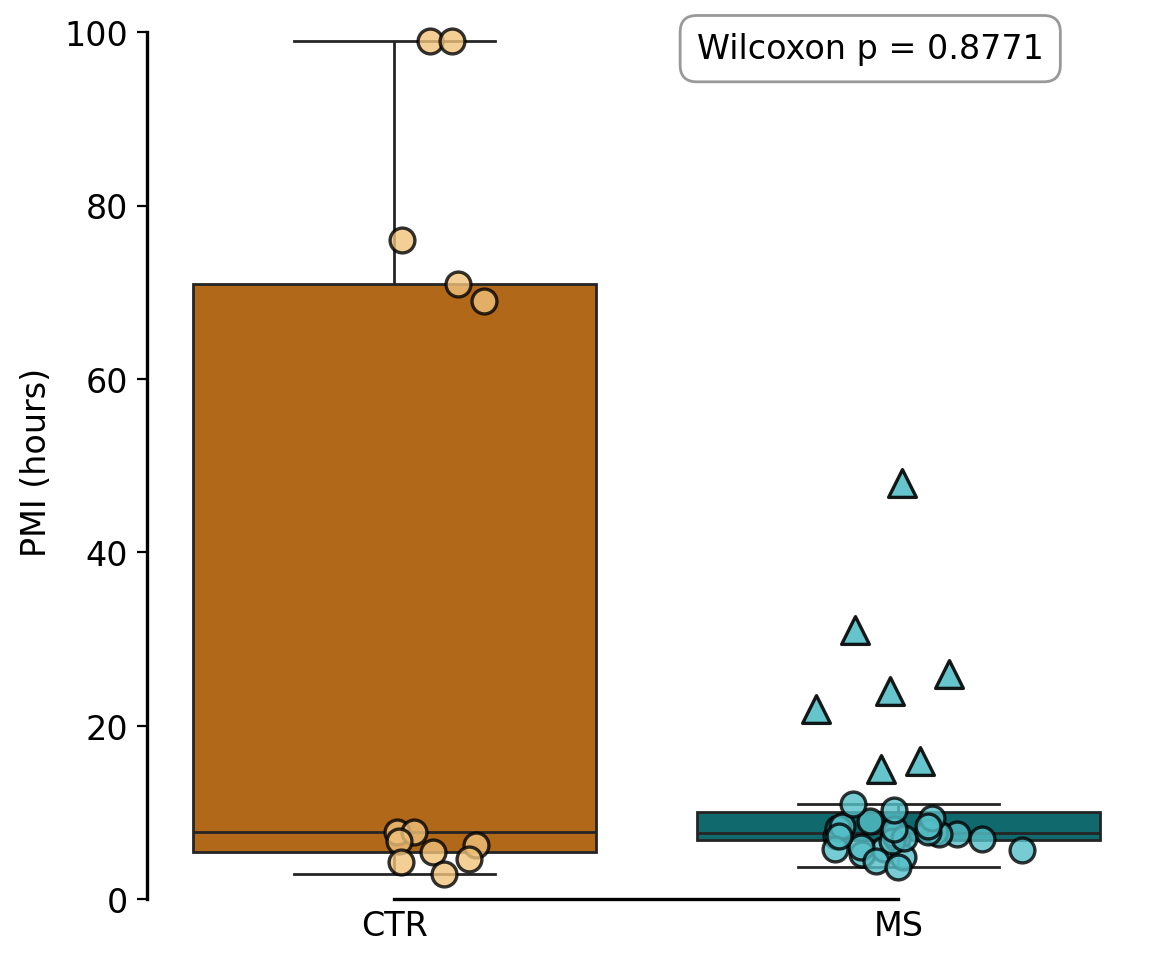

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
individual_df = adata_all.obs[['individual_id_anon', 'pmi_hours', 'group']].drop_duplicates()
individual_df = individual_df.dropna(subset=['pmi_hours'])

# Custom colors
custom_palette = {
    'CTR': '#ca6a00',
    'MS': '#00797d'
}

fill_palette = {
    'CTR': '#f0c27b',
    'MS': '#55bfc7'
}

# Define known outliers (from IQR method)
outliers_ms = [26.0, 24.0, 16.0, 31.0, 48.0, 15.0, 22.0]

# Compute y-axis limits
min_pmi = individual_df['pmi_hours'].min()
max_pmi = individual_df['pmi_hours'].max()
y_padding = 2
y_min = 0  # force minimum y to zero
y_max = max_pmi + y_padding

# Mann-Whitney p-value
mannwhitney_p = 0.8771

# Plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=individual_df,
    x='group',
    y='pmi_hours',
    hue='group',
    palette=custom_palette,
    order=['CTR', 'MS'],
    hue_order=['CTR', 'MS'],
    dodge=False,
    legend=False,
    showfliers=False 
)

# Make bottom spine visible and style it
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')

# Remove other spines for a clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.2)
ax.spines['left'].set_color('black')

ax.set_xticklabels(['CTR', 'MS'])
ax.tick_params(axis='x', which='both', length=0)

# Overlay points
for pos, group in enumerate(['CTR', 'MS']):
    subset = individual_df[individual_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))
    is_outlier = subset['pmi_hours'].isin(outliers_ms) if group == 'MS' else np.full(len(subset), False)

    # Normal points
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'pmi_hours'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'pmi_hours'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

# Labels and aesthetics
plt.ylabel('PMI (hours)')
plt.xlabel('')
plt.ylim(y_min, y_max)
plt.grid(False)
sns.despine(trim=True)

# Add p-value annotation
annotation_text = f"Wilcoxon p = {mannwhitney_p:.4f}"
x_pos = 0.6
y_pos = y_max - 1  # slightly below top

plt.text(x_pos, y_pos, annotation_text,
         fontsize=12, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig("boxplot_pmi_by_group_stats.png", dpi=300)
plt.show()

In [98]:
# Split groups
ctr_pmi = individual_df[individual_df['group'] == 'CTR']['pmi_hours']
ms_pmi = individual_df[individual_df['group'] == 'MS']['pmi_hours']

# Summary stats function
def describe_series(series):
    return {
        'count': len(series),
        'min': np.min(series),
        'max': np.max(series),
        'mean': np.mean(series),
        'median': np.median(series),
        'std': np.std(series, ddof=1),
        'Q1': np.percentile(series, 25),
        'Q3': np.percentile(series, 75),
        'IQR': np.percentile(series, 75) - np.percentile(series, 25),
    }

# Get stats
ctr_stats = describe_series(ctr_pmi)
ms_stats = describe_series(ms_pmi)

# Print nicely
print("\nPMI Stats (in hours):")
print("CTR Group:")
for k, v in ctr_stats.items():
    print(f"  {k:<8}: {v:.2f}")
print("\nMS Group:")
for k, v in ms_stats.items():
    print(f"  {k:<8}: {v:.2f}")


PMI Stats (in hours):

CTR Group:

count   : 13.00

min     : 2.92

max     : 99.00

...

median  : 7.62

std     : 9.19

Q1      : 6.81

Q3      : 10.08

IQR     : 3.27

/tmp/ipykernel_2685739/423044209.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups)


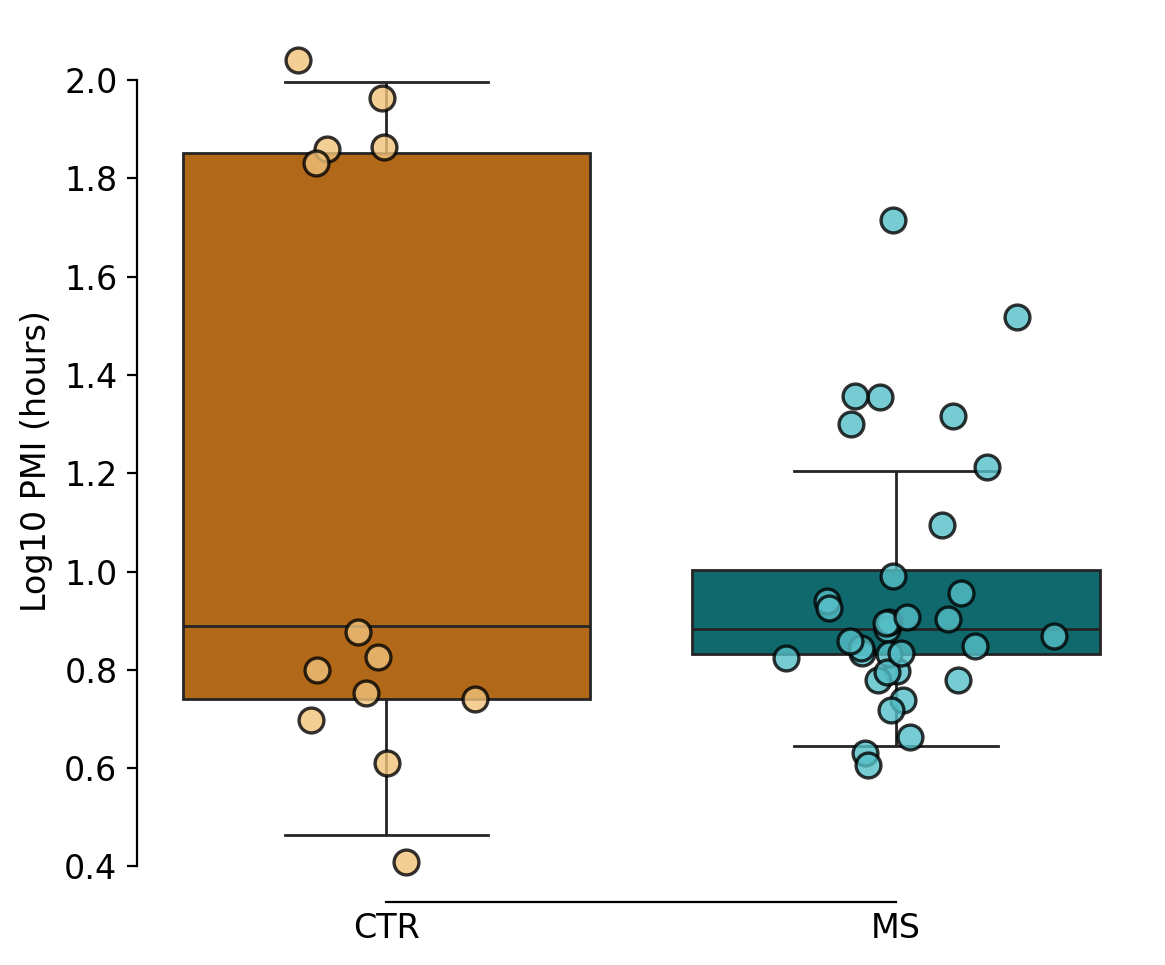

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data (drop duplicates to keep one value per individual)
individual_df = adata_all.obs[['individual_id_anon', 'pmi_hours', 'group']].drop_duplicates()

# Add log-transformed PMI column
individual_df['log_pmi_hours'] = np.log10(individual_df['pmi_hours'])

# Custom colors
custom_palette = {
    'CTR': '#ca6a00',
    'MS': '#00797d'
}

fill_palette = {
    'CTR': '#f0c27b',  # lighter orange
    'MS': '#55bfc7'    # lighter teal
}

# Plot
plt.figure(figsize=(6, 5))
#ax = sns.boxplot(data=individual_df, x='group', y='log_pmi_hours', palette=custom_palette)
ax = sns.boxplot(
    data=individual_df,
    x='group',
    y='log_pmi_hours',
    hue='group',
    palette=custom_palette,
    order=['CTR', 'MS'],
    hue_order=['CTR', 'MS'],
    dodge=False,
    legend=False,
    showfliers=False  # <- disables those automatic outlier dots
)

# Remove bottom spine
ax.spines['bottom'].set_visible(False)

# Customize x-axis labels and remove ticks
groups = individual_df['group'].unique()
ax.set_xticklabels(groups)
ax.tick_params(axis='x', which='both', length=0)

# Overlay jittered scatter points
positions = range(len(groups))
for pos, group in enumerate(['CTR', 'MS']):
    subset = individual_df[individual_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))
    y_jittered = subset['log_pmi_hours'] + np.random.normal(0, 0.05, size=len(subset))

    plt.scatter(x_jittered, y_jittered,
                s=80,
                facecolors=fill_palette[group],
                edgecolors='black',
                linewidth=1.2,
                alpha=0.8,
                marker='o',
                zorder=10)

# Axis labels
plt.ylabel('Log10 PMI (hours)')
plt.xlabel('')
plt.grid(False)
sns.despine(trim=True)
plt.tight_layout()

plt.show()

In [89]:
from scipy.stats import shapiro

ages_control = individual_df[individual_df['group'] == 'CTR']['pmi_hours']
ages_ms = individual_df[individual_df['group'] == 'MS']['pmi_hours']

# Shapiro-Wilk test
shapiro_control = shapiro(ages_control)
shapiro_ms = shapiro(ages_ms)

print("Shapiro-Wilk Test for Normality:")
print(f"Control group: W={shapiro_control.statistic:.4f}, p={shapiro_control.pvalue:.4f}")
print(f"MS group:      W={shapiro_ms.statistic:.4f}, p={shapiro_ms.pvalue:.4f}")

Shapiro-Wilk Test for Normality:

Control group: W=0.7293, p=0.0011

MS group:      W=0.6528, p=0.0000

In [90]:
def find_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data < lower) | (data > upper)]

# Find outliers
outliers_control = find_outliers(ages_control)
outliers_ms = find_outliers(ages_ms)

print("\nOutliers (IQR method):")
print(f"Control group: {list(outliers_control)}")
print(f"MS group:      {list(outliers_ms)}")

Outliers (IQR method):

Control group: []

MS group:      [26.0, 24.0, 16.0, 31.0, 48.0, 15.0, 22.0]

In [91]:
from scipy.stats import ttest_ind, mannwhitneyu

# T-test (equal_var=False just in case variances differ)
t_res = ttest_ind(ages_control, ages_ms, equal_var=False)

# Mann-Whitney U test
u_res = mannwhitneyu(ages_control, ages_ms, alternative='two-sided')

print("\nStatistical Tests:")
print(f"T-test:        t={t_res.statistic:.4f}, p={t_res.pvalue:.4f}")
print(f"Mann-Whitney:  U={u_res.statistic:.4f}, p={u_res.pvalue:.4f}")

Statistical Tests:

T-test:        t=2.1668, p=0.0502

Mann-Whitney:  U=228.0000, p=0.8771

## Try on other variables?

In [ ]:
adata_all

/tmp/ipykernel_861546/848940768.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_genes_per_sample = adata_all.obs.groupby('sample_id_anon')['n_genes_by_counts'].median().reset_index()
/tmp/ipykernel_861546/848940768.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=median_genes_per_sample, x='group', y='n_genes_by_counts', palette=custom_palette)


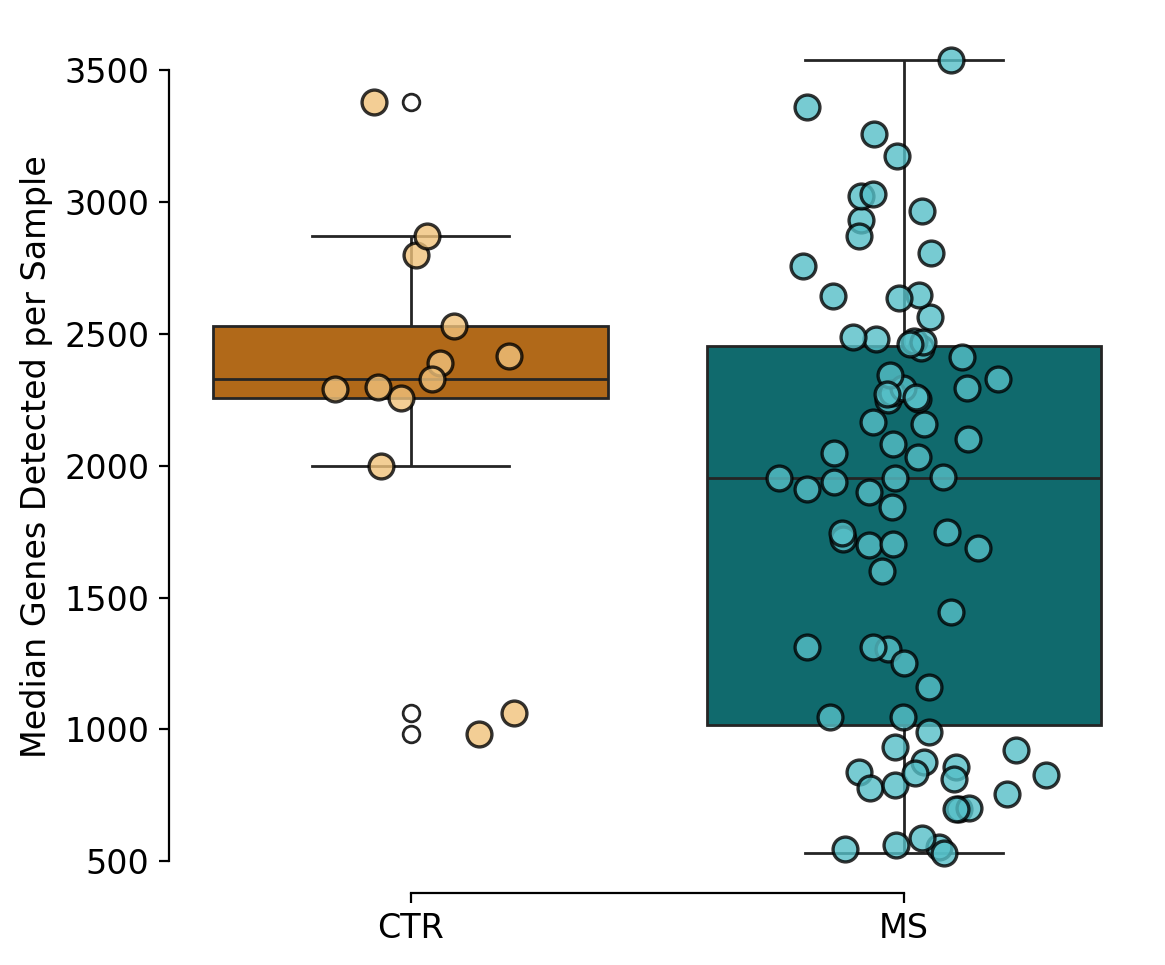

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Calculate median genes per sample

# Assuming you have a column for 'n_genes' or similar per cell in adata_all.obs
# If not, you might have 'n_genes_by_counts' or something equivalent.
# Adjust the column name accordingly.

# Group by sample_id_anon and calculate median n_genes per sample
median_genes_per_sample = adata_all.obs.groupby('sample_id_anon')['n_genes_by_counts'].median().reset_index()

# Merge group info from one cell per sample (assuming group is constant per sample)
sample_group = adata_all.obs[['sample_id_anon', 'group']].drop_duplicates()

median_genes_per_sample = median_genes_per_sample.merge(sample_group, on='sample_id_anon', how='left')

# Step 2: Plot boxplot comparing groups

plt.figure(figsize=(6, 5))
custom_palette = {'CTR': '#ca6a00', 'MS': '#00797d'}

ax = sns.boxplot(data=median_genes_per_sample, x='group', y='n_genes_by_counts', palette=custom_palette)

# Add scatter points with jitter for individual samples
groups = median_genes_per_sample['group'].unique()
positions = range(len(groups))
fill_palette = {'CTR': '#f0c27b', 'MS': '#55bfc7'}

for pos, group in enumerate(['CTR', 'MS']):
    subset = median_genes_per_sample[median_genes_per_sample['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))

    plt.scatter(x_jittered, subset['n_genes_by_counts'],
                s=80,
                facecolors=fill_palette[group],
                edgecolors='black',
                linewidth=1.2,
                alpha=0.8,
                marker='o',
                zorder=10)

plt.ylabel('Median genes per nucleus')
plt.xlabel('')
plt.grid(False)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1019427/1475120382.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_genes_per_sample = adata_all.obs.groupby('sample_id_anon')['n_genes_by_counts'].median().reset_index()


Shapiro-Wilk Test for Normality:

Control group: W=0.8892, p=0.0950

MS group:      W=0.9521, p=0.0049

Outliers (IQR method):

...

MS group:      []

Statistical Tests:

T-test:        t=2.1693, p=0.0432

Mann-Whitney:  U=692.0000, p=0.0460

/tmp/ipykernel_1019427/1475120382.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['CTR', 'MS'])


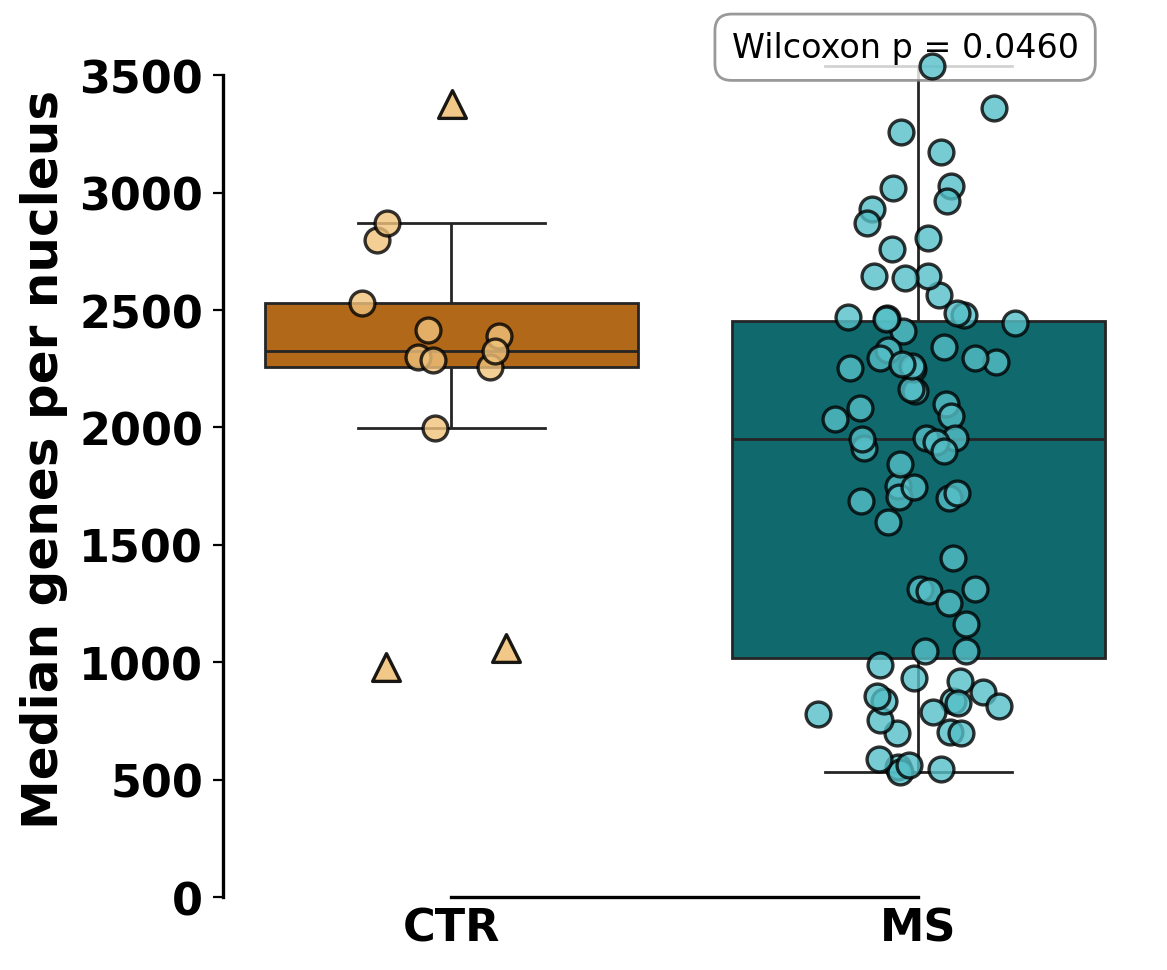

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# Step 1: Compute median genes per nucleus per sample
median_genes_per_sample = adata_all.obs.groupby('sample_id_anon')['n_genes_by_counts'].median().reset_index()
sample_group = adata_all.obs[['sample_id_anon', 'group']].drop_duplicates()
median_genes_per_sample = median_genes_per_sample.merge(sample_group, on='sample_id_anon', how='left')

# Step 2: Normality testing
genes_control = median_genes_per_sample[median_genes_per_sample['group'] == 'CTR']['n_genes_by_counts']
genes_ms = median_genes_per_sample[median_genes_per_sample['group'] == 'MS']['n_genes_by_counts']

shapiro_control = shapiro(genes_control)
shapiro_ms = shapiro(genes_ms)

print("Shapiro-Wilk Test for Normality:")
print(f"Control group: W={shapiro_control.statistic:.4f}, p={shapiro_control.pvalue:.4f}")
print(f"MS group:      W={shapiro_ms.statistic:.4f}, p={shapiro_ms.pvalue:.4f}")

# Step 3: Identify outliers
def find_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data < lower) | (data > upper)]

outliers_control = find_outliers(genes_control)
outliers_ms = find_outliers(genes_ms)

print("\nOutliers (IQR method):")
print(f"Control group: {list(outliers_control)}")
print(f"MS group:      {list(outliers_ms)}")

# Step 4: Stats tests
t_res = ttest_ind(genes_control, genes_ms, equal_var=False)
u_res = mannwhitneyu(genes_control, genes_ms, alternative='two-sided')

print("\nStatistical Tests:")
print(f"T-test:        t={t_res.statistic:.4f}, p={t_res.pvalue:.4f}")
print(f"Mann-Whitney:  U={u_res.statistic:.4f}, p={u_res.pvalue:.4f}")

# Step 5: Plotting
custom_palette = {'CTR': '#ca6a00', 'MS': '#00797d'}
fill_palette = {'CTR': '#f0c27b', 'MS': '#55bfc7'}

y_min = 0
y_max = median_genes_per_sample['n_genes_by_counts'].max() + 200  # Padding

plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=median_genes_per_sample,
    x='group',
    y='n_genes_by_counts',
    hue='group',
    palette=custom_palette,
    order=['CTR', 'MS'],
    hue_order=['CTR', 'MS'],
    dodge=False,
    legend=False,
    showfliers=False
)

# Beautify axes
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.set_xticklabels(['CTR', 'MS'])
ax.tick_params(axis='x', which='both', length=0)

# Add points
for pos, group in enumerate(['CTR', 'MS']):
    subset = median_genes_per_sample[median_genes_per_sample['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))
    outliers = find_outliers(subset['n_genes_by_counts'])

    is_outlier = subset['n_genes_by_counts'].isin(outliers)

    # Regular dots
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'n_genes_by_counts'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'n_genes_by_counts'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

# Annotation
annotation_text = f"Wilcoxon p = {u_res.pvalue:.4f}"
x_pos = 0.6
y_pos = y_max - 50

plt.text(x_pos, y_pos, annotation_text,
         fontsize=12, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Make text larger and bold
plt.ylabel('Median genes per nucleus', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')   

plt.ylim(y_min, y_max)
plt.grid(False)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("boxplot_genes_per_nucleus_by_group.png", dpi=300)
plt.show()

/tmp/ipykernel_1019427/2646216492.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_counts_per_sample = adata_all.obs.groupby('sample_id_anon')['total_counts'].median().reset_index()


Shapiro-Wilk Test for Normality:

Control group: W=0.8318, p=0.0167

MS group:      W=0.9104, p=0.0000

Outliers (IQR method):

...

MS group:      []

Statistical Tests:

T-test:        t=2.3350, p=0.0292

Mann-Whitney:  U=669.0000, p=0.0823

/tmp/ipykernel_1019427/2646216492.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['CTR', 'MS'])


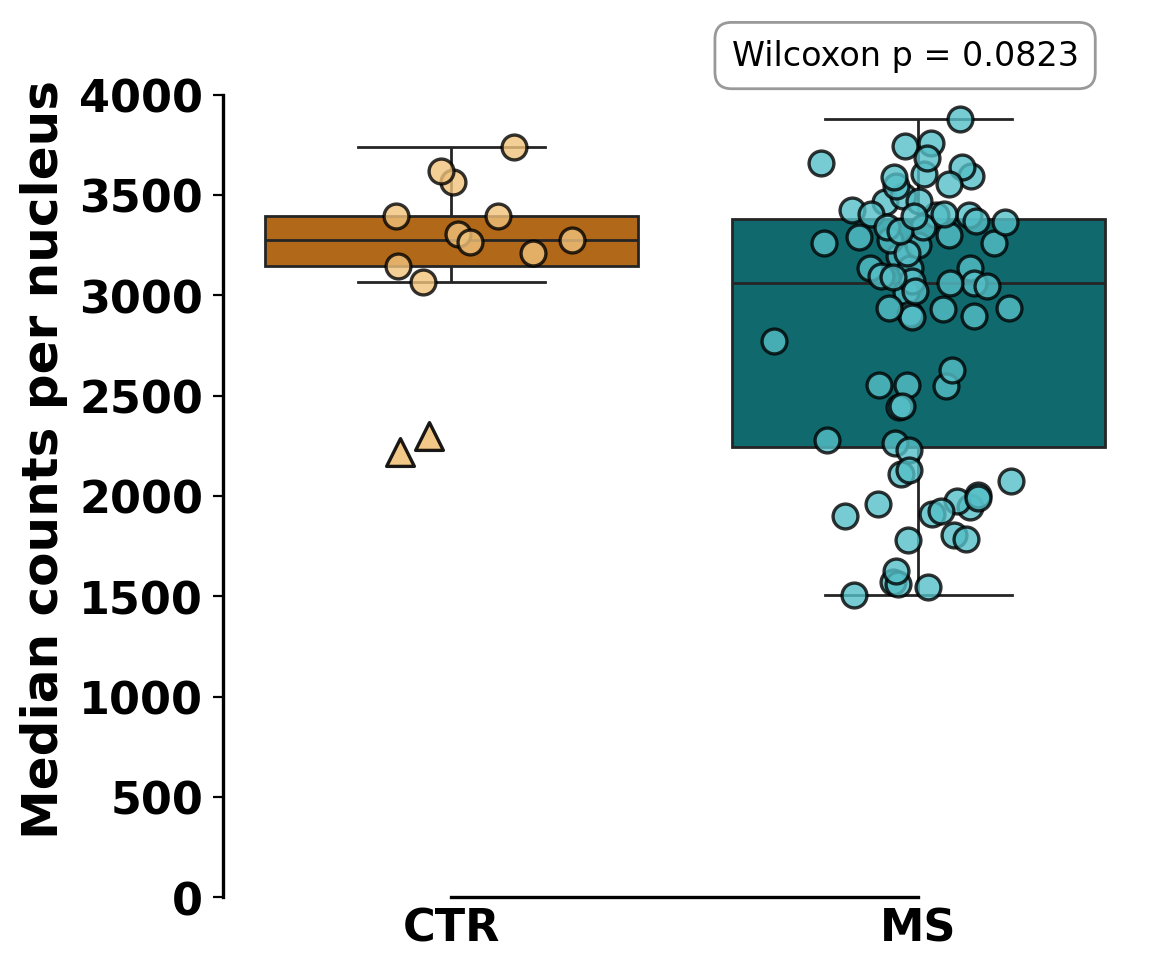

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# Step 1: Compute median total counts per sample
median_counts_per_sample = adata_all.obs.groupby('sample_id_anon')['total_counts'].median().reset_index()
sample_group = adata_all.obs[['sample_id_anon', 'group']].drop_duplicates()
median_counts_per_sample = median_counts_per_sample.merge(sample_group, on='sample_id_anon', how='left')

# Step 2: Extract group values
counts_control = median_counts_per_sample[median_counts_per_sample['group'] == 'CTR']['total_counts']
counts_ms = median_counts_per_sample[median_counts_per_sample['group'] == 'MS']['total_counts']

# Step 3: Normality test
shapiro_control = shapiro(counts_control)
shapiro_ms = shapiro(counts_ms)

print("Shapiro-Wilk Test for Normality:")
print(f"Control group: W={shapiro_control.statistic:.4f}, p={shapiro_control.pvalue:.4f}")
print(f"MS group:      W={shapiro_ms.statistic:.4f}, p={shapiro_ms.pvalue:.4f}")

# Step 4: Outlier detection
def find_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data < lower) | (data > upper)]

outliers_control = find_outliers(counts_control)
outliers_ms = find_outliers(counts_ms)

print("\nOutliers (IQR method):")
print(f"Control group: {list(outliers_control)}")
print(f"MS group:      {list(outliers_ms)}")

# Step 5: Statistical tests
t_res = ttest_ind(counts_control, counts_ms, equal_var=False)
u_res = mannwhitneyu(counts_control, counts_ms, alternative='two-sided')

print("\nStatistical Tests:")
print(f"T-test:        t={t_res.statistic:.4f}, p={t_res.pvalue:.4f}")
print(f"Mann-Whitney:  U={u_res.statistic:.4f}, p={u_res.pvalue:.4f}")

# Step 6: Plotting
custom_palette = {'CTR': '#ca6a00', 'MS': '#00797d'}
fill_palette = {'CTR': '#f0c27b', 'MS': '#55bfc7'}

y_min = 0
y_max = median_counts_per_sample['total_counts'].max() + 500  # adjust padding as needed

plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    data=median_counts_per_sample,
    x='group',
    y='total_counts',
    hue='group',
    palette=custom_palette,
    order=['CTR', 'MS'],
    hue_order=['CTR', 'MS'],
    dodge=False,
    legend=False,
    showfliers=False
)

# Beautify axes
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.set_xticklabels(['CTR', 'MS'])
ax.tick_params(axis='x', which='both', length=0)

# Add scatter points
for pos, group in enumerate(['CTR', 'MS']):
    subset = median_counts_per_sample[median_counts_per_sample['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.1, size=len(subset))
    outliers = find_outliers(subset['total_counts'])
    is_outlier = subset['total_counts'].isin(outliers)

    # Normal dots
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'total_counts'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'total_counts'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

# Add p-value annotation
annotation_text = f"Wilcoxon p = {u_res.pvalue:.4f}"
x_pos = 0.6
y_pos = y_max - 100

plt.text(x_pos, y_pos, annotation_text,
         fontsize=12, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Make text larger and bold
plt.ylabel('Median counts per nucleus', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')   

plt.ylim(y_min, y_max)
plt.grid(False)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("boxplot_counts_per_nucleus_by_group.png", dpi=300)
plt.show()

# Cell counts stats?

In [69]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [70]:
%%R
library(ggplot2)
library(readr)

In [71]:
adata_all

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DC

In [72]:
# Extract relevant columns
df = adata_all.obs[['cluster_annotation', 'group']].copy()
df['group'] = df['group'].replace({'CTR': 'CTR', 'MS': 'MS'})

# Count number of nuclei per cell type per group
counts = df.groupby(['cluster_annotation', 'group']).size().reset_index(name='n_nuclei')

# Compute total nuclei per cell type
totals = counts.groupby('cluster_annotation')['n_nuclei'].transform('sum')

# Calculate percentage within each cell type
counts['Percentage'] = counts['n_nuclei'] / totals * 100

# Optional: enforce order
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

counts['cluster_annotation'] = pd.Categorical(counts['cluster_annotation'], categories=celltype_order, ordered=True)
counts

,cluster_annotation,group,n_nuclei,Percentage
0,OPCs + COPs,CTR,2446,19.445107
1,OPCs + COPs,MS,10133,80.554893
2,MOLs,CTR,41049,21.800598
3,MOLs,MS,147244,78.199402
4,Microglia,CTR,4628,12.280748
5,Microglia,MS,33057,87.719252
6,Astrocytes,CTR,3025,7.696026
7,Astrocytes,MS,36281,92.303974
8,Excitatory neurons,CTR,1445,6.685482
9,Excitatory neurons,MS,20169,93.314518


In [54]:
counts.to_csv('nuclei_per_celltype_status.csv', index=False)

In [73]:
# Extract relevant columns
df = adata_all.obs[['cluster_annotation', 'lesion_type']].copy()
#df['Disease Status'] = df['group'].replace({'CTR': 'CTR', 'MS': 'MS'})

# Count number of nuclei per cell type per group
counts = df.groupby(['cluster_annotation', 'lesion_type']).size().reset_index(name='n_nuclei')

# Compute total nuclei per cell type
totals = counts.groupby('cluster_annotation')['n_nuclei'].transform('sum')

# Calculate percentage within each cell type
counts['Percentage'] = counts['n_nuclei'] / totals * 100

# Optional: enforce order
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

counts['cluster_annotation'] = pd.Categorical(counts['cluster_annotation'], categories=celltype_order, ordered=True)
counts

,cluster_annotation,lesion_type,n_nuclei,Percentage
0,OPCs + COPs,AL,3177,25.256380
1,OPCs + COPs,CAL,1975,15.700771
2,OPCs + COPs,CIL,1228,9.762302
3,OPCs + COPs,NAWM,2446,19.445107
4,OPCs + COPs,RL,1307,10.390333
5,OPCs + COPs,WM,2446,19.445107
6,MOLs,AL,31929,16.957083
7,MOLs,CAL,30218,16.048393
8,MOLs,CIL,20488,10.880914
9,MOLs,NAWM,37997,20.179720


In [18]:
counts.to_csv('nuclei_per_celltype_lesion.csv', index=False)

In [100]:
%%R

# Read in the data
df <- read_csv("nuclei_per_celltype_lesion.csv")

head(df)

Rows: 60 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): cluster_annotation, lesion_type
dbl (2): n_nuclei, Percentage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 6 × 4
  cluster_annotation lesion_type n_nuclei Percentage
  <chr>              <chr>          <dbl>      <dbl>
1 OPCs + COPs        AL              3177      25.3 
2 OPCs + COPs        CAL             1975      15.7 
3 OPCs + COPs        CIL             1228       9.76
4 OPCs + COPs        NAWM            2446      19.4 
5 OPCs + COPs        RL              1307      10.4 
6 OPCs + COPs        WM              2446      19.4 


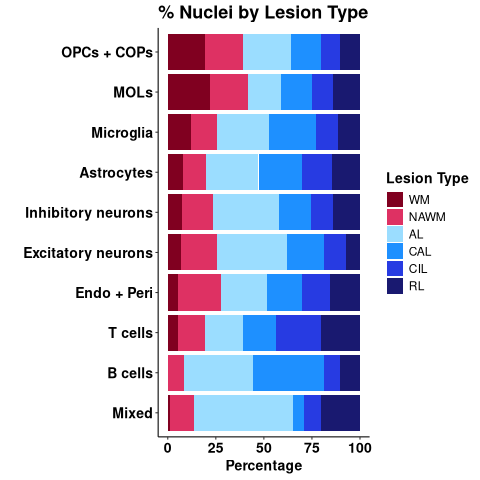

In [101]:
%%R
library(tidyr)

df <- df %>%
  tidyr::complete(cluster_annotation, lesion_type, fill = list(Percentage = 0, n_nuclei = 0))

# Optional: set factor levels
df$lesion_type <- factor(df$lesion_type, levels = c("WM", "NAWM", "AL", "CAL", "CIL", "RL"))
df$cluster_annotation <- factor(df$cluster_annotation, levels = rev(c(
  'OPCs + COPs',
  'MOLs',
  'Microglia',
  'Astrocytes',
  'Inhibitory neurons',
  'Excitatory neurons',
  'Endo + Peri',
  'T cells',
  'B cells',
  'Mixed'
)))

# Set disease status order: CTR before MS
df$lesion_type <- factor(df$lesion_type, levels = c("RL", "CIL", "CAL", "AL", "NAWM", "WM"))

p <- ggplot(df, aes(x = cluster_annotation, y = Percentage, fill = lesion_type)) +
  geom_bar(stat = "identity", position = "stack") +
  coord_flip() +
  scale_fill_manual(values = c(
    "WM" = "#800020",
    "NAWM" = "#de3163",
    "AL" = "#9bddff",
    "CAL" = "#1e90ff",
    "CIL" = "#273be2",
    "RL" = "#191970"
  )) +
  labs(
    x = "",
    y = "Percentage",
    fill = 'Lesion Type',
    title = "% Nuclei by Lesion Type"
  ) +
  ylim(0, 100) +
  theme_classic() +
  theme_classic() +
    theme(
      axis.text.y = element_text(size = 14, face = "bold", color = 'black'),  # cell type labels
      axis.text.x = element_text(size = 14, face = "bold", color = 'black'),  # % labels (bottom)
      axis.title = element_text(size = 14, face = "bold"),
      plot.title = element_text(size = 18, face = "bold"),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14, face = "bold")
  ) +
  guides(fill = guide_legend(reverse = TRUE))

# Save to file
ggsave(
  "nuclei_celltype_lesion_status.png",
  plot = p,
  width = 10,
  height = 6,
  dpi = 300
)

# Display plot
p

In [95]:
%%R

# Read in the data
df <- read_csv("nuclei_per_celltype_status.csv")
df

Rows: 20 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): cluster_annotation, group
dbl (2): n_nuclei, Percentage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 20 × 4
   cluster_annotation group n_nuclei Percentage
   <chr>              <chr>    <dbl>      <dbl>
 1 OPCs + COPs        CTR       2446      19.4 
 2 OPCs + COPs        MS       10133      80.6 
 3 MOLs               CTR      41049      21.8 
 4 MOLs               MS      147244      78.2 
 5 Microglia          CTR       4628      12.3 
 6 Microglia          MS       33057      87.7 
 7 Astrocytes         CTR       3025       7.70
 8 Astrocytes         MS       36281      92.3 
 9 Excitatory neurons CTR       1445       6.69
10 Excitatory neurons MS       20169      93.3 
11 Inhibitory neurons CTR        581       7.36
12 Inhibitory neurons

In [96]:
%%R
colnames(df)

[1] "cluster_annotation" "group"              "n_nuclei"          
[4] "Percentage"        


In [97]:
%%R
unique(df$cluster_annotation)

 [1] "OPCs + COPs"        "MOLs"               "Microglia"         
 [4] "Astrocytes"         "Excitatory neurons" "Inhibitory neurons"
 [7] "Endo + Peri"        "T cells"            "B cells"           
[10] "Mixed"             


In [98]:
%%R
unique(df$group)

[1] "CTR" "MS" 


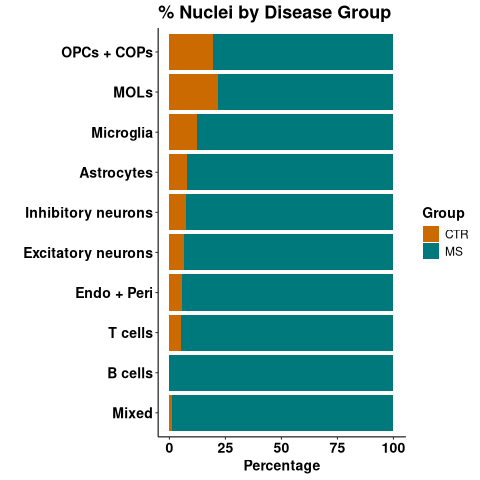

In [99]:
%%R

df <- df %>%
  tidyr::complete(cluster_annotation, group, fill = list(Percentage = 0, n_nuclei = 0))

# Optional: set factor levels
df$group <- factor(df$group, levels = c("CTR", "MS"))
df$cluster_annotation <- factor(df$cluster_annotation, levels = rev(c(
  'OPCs + COPs',
  'MOLs',
  'Microglia',
  'Astrocytes',
  'Inhibitory neurons',
  'Excitatory neurons',
  'Endo + Peri',
  'T cells',
  'B cells',
  'Mixed'
)))

# Set disease status order: CTR before MS
df$group <- factor(df$group, levels = c("MS", "CTR"))

p <- ggplot(df, aes(x = cluster_annotation, y = Percentage, fill = group)) +
  geom_bar(stat = "identity", position = "stack") +
  coord_flip() +
  scale_fill_manual(values = c(
    "MS" = "#00797d",
    "CTR" = "#ca6a00"
  )) +
  labs(
    x = "",
    y = "Percentage",
    fill = 'Group',
    title = "% Nuclei by Disease Group"
  ) +
  ylim(0, 100.5) +
  theme_classic() +
    theme(
      axis.text.y = element_text(size = 14, face = "bold", color = 'black'),  # cell type labels
      axis.text.x = element_text(size = 14, face = "bold", color = 'black'),  # % labels (bottom)
      axis.title = element_text(size = 14, face = "bold"),
      plot.title = element_text(size = 18, face = "bold"),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14, face = "bold")
  ) +
  guides(fill = guide_legend(reverse = TRUE))

# Save to file
ggsave("nuclei_celltype_group.png", plot = p, width = 10, height = 6, dpi = 300)

# Display plot
p

In [28]:
# Extract relevant columns
df = adata_all.obs[['cluster_annotation', 'sex']].copy()
#df['Disease Status'] = df['group'].replace({'CTR': 'CTR', 'MS': 'MS'})

# Count number of nuclei per cell type per group
counts = df.groupby(['cluster_annotation', 'sex']).size().reset_index(name='n_nuclei')

# Compute total nuclei per cell type
totals = counts.groupby('cluster_annotation')['n_nuclei'].transform('sum')

# Calculate percentage within each cell type
counts['Percentage'] = counts['n_nuclei'] / totals * 100

# Optional: enforce order
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

counts['cluster_annotation'] = pd.Categorical(counts['cluster_annotation'], categories=celltype_order, ordered=True)
counts

,cluster_annotation,sex,n_nuclei,Percentage
0,OPCs + COPs,F,8327,66.197631
1,OPCs + COPs,M,4252,33.802369
2,MOLs,F,109462,58.133866
3,MOLs,M,78831,41.866134
4,Microglia,F,26611,70.614303
5,Microglia,M,11074,29.385697
6,Astrocytes,F,25416,64.661884
7,Astrocytes,M,13890,35.338116
8,Excitatory neurons,F,17659,81.701675
9,Excitatory neurons,M,3955,18.298325


In [29]:
counts.to_csv('nuclei_per_celltype_sex.csv', index=False)

In [102]:
%%R

# Read in the data
df <- read_csv("nuclei_per_celltype_sex.csv")

head(df)

Rows: 20 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): cluster_annotation, sex
dbl (2): n_nuclei, Percentage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 6 × 4
  cluster_annotation sex   n_nuclei Percentage
  <chr>              <chr>    <dbl>      <dbl>
1 OPCs + COPs        F         8327       66.2
2 OPCs + COPs        M         4252       33.8
3 MOLs               F       109462       58.1
4 MOLs               M        78831       41.9
5 Microglia          F        26611       70.6
6 Microglia          M        11074       29.4


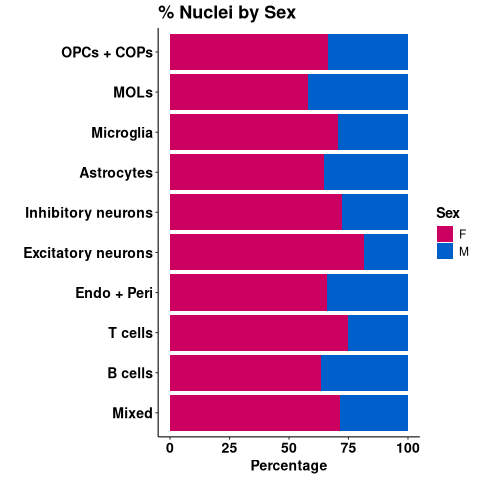

In [103]:
%%R
library(tidyr)

df <- df %>%
  tidyr::complete(cluster_annotation, sex, fill = list(Percentage = 0, n_nuclei = 0))

# Optional: set factor levels
df$sex <- factor(df$sex, levels = c("M", "F"))
df$cluster_annotation <- factor(df$cluster_annotation, levels = rev(c(
  'OPCs + COPs',
  'MOLs',
  'Microglia',
  'Astrocytes',
  'Inhibitory neurons',
  'Excitatory neurons',
  'Endo + Peri',
  'T cells',
  'B cells',
  'Mixed'
)))

# Set disease status order: CTR before MS
df$sex <- factor(df$sex, levels = c("M", "F"))

p <- ggplot(df, aes(x = cluster_annotation, y = Percentage, fill = sex)) +
  geom_bar(stat = "identity", position = "stack") +
  coord_flip() +
  scale_fill_manual(values = c(
    "M" = "#0060cb",
    "F" = "#cb0060"
  )) +
  labs(
    x = "",
    y = "Percentage",
    title = "% Nuclei by Sex",
    fill = 'Sex',
  ) +
  ylim(0, 100) +
  theme_classic() +
    theme(
      axis.text.y = element_text(size = 14, face = "bold", color = 'black'),  # cell type labels
      axis.text.x = element_text(size = 14, face = "bold", color = 'black'),  # % labels (bottom)
      axis.title = element_text(size = 14, face = "bold"),
      plot.title = element_text(size = 18, face = "bold"),
      legend.text = element_text(size = 12),
      legend.title = element_text(size = 14, face = "bold")
  ) +
  guides(fill = guide_legend(reverse = TRUE))


# Save to file
ggsave(
  "nuclei_celltype_sex.png",
  plot = p,
  width = 10,
  height = 6,
  dpi = 300
)

# Display plots
p

## Bar chart of nuclei per cell type

In [35]:
adata_all

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DC

In [36]:
celltype_counts = adata_all.obs['cluster_annotation'].value_counts().rename_axis('Cell type').reset_index(name='N nuclei')
celltype_counts.head

<bound method NDFrame.head of             Cell type  N nuclei
0                MOLs    188293
1          Astrocytes     39306
2           Microglia     37685
3  Excitatory neurons     21614
4         OPCs + COPs     12579
5  Inhibitory neurons      7893
6         Endo + Peri      7515
7               Mixed      4102
8             T cells      1642
9             B cells       937>

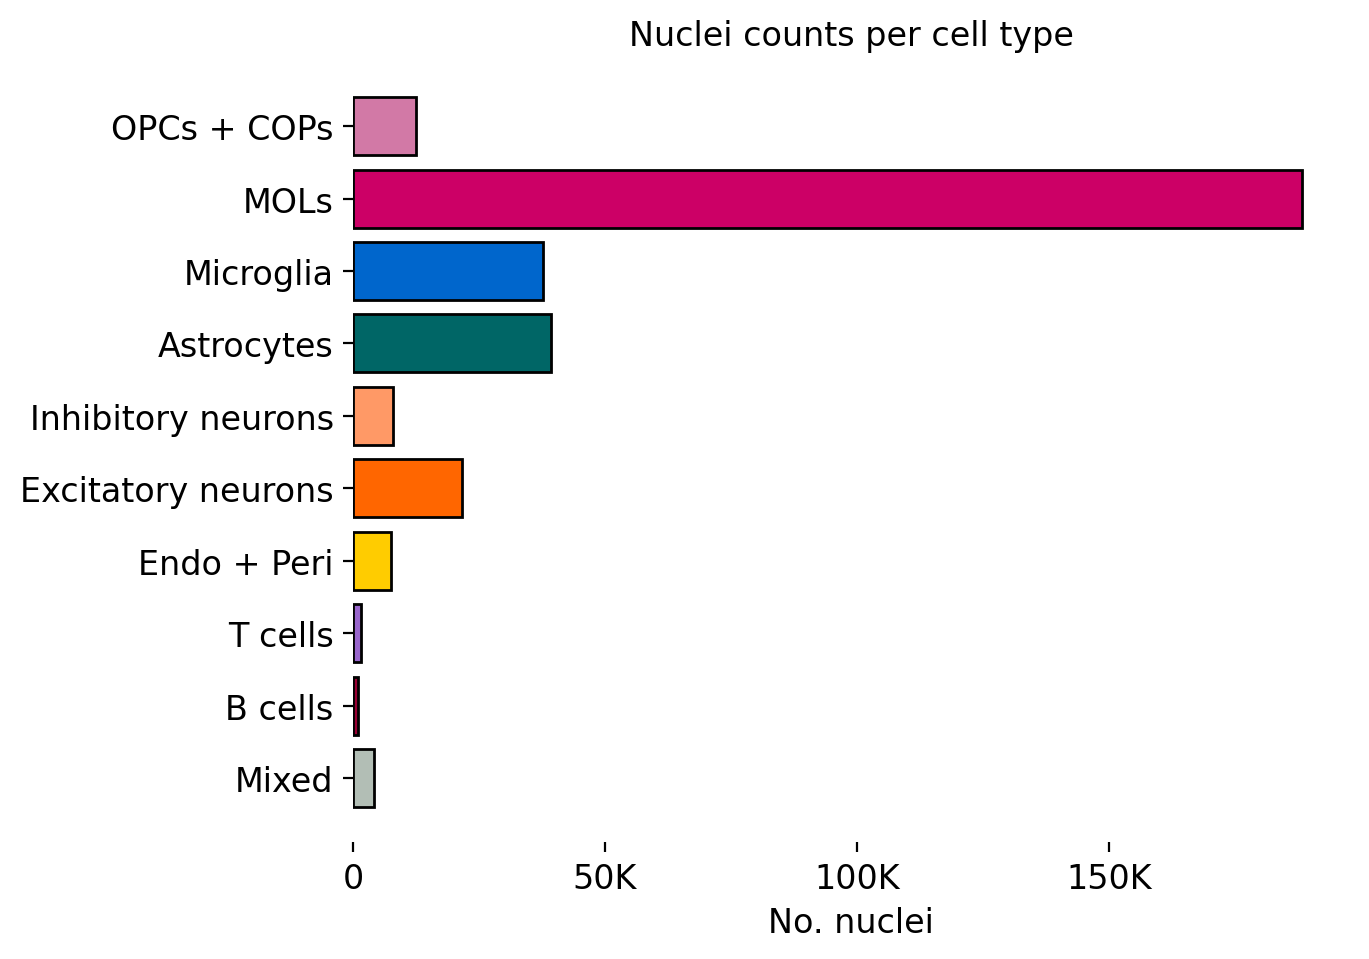

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom order and color
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

cluster_simplified_color = {
    'OPCs + COPs': '#d279a6',
    'MOLs': '#cc0066',
    'Microglia': '#0066cc',
    'Astrocytes': '#006666',
    'Inhibitory neurons': '#ff9966',
    'Excitatory neurons': '#ff6600',
    'Endo + Peri': '#ffcc00',
    'T cells': '#9966cc',
    'B cells': '#990033',
    'Mixed': '#b2beb5'
}

# Count and order
celltype_counts = (
    adata_all.obs['cluster_annotation']
    .value_counts()
    .reindex(celltype_order)
    .rename_axis('Cell type')
    .reset_index(name='N nuclei')
)
celltype_counts['color'] = celltype_counts['Cell type'].map(cluster_simplified_color)

# Plot
plt.figure(figsize=(7, 5))
bars = plt.barh(
    y=celltype_counts['Cell type'],
    width=celltype_counts['N nuclei'],
    color=celltype_counts['color'],
    edgecolor='black'
)

# Reverse the y-axis order
plt.gca().invert_yaxis()

plt.xlabel('No. nuclei')
plt.ylabel('')
plt.title('')

# Set x-axis ticks to 0, 50K, 100K, 150K
plt.xticks([0, 50000, 100000, 150000], ['0', '50K', '100K', '150K'])

# Style
sns.despine(left=True, bottom=True)
plt.grid(False)
plt.tight_layout()
plt.show()

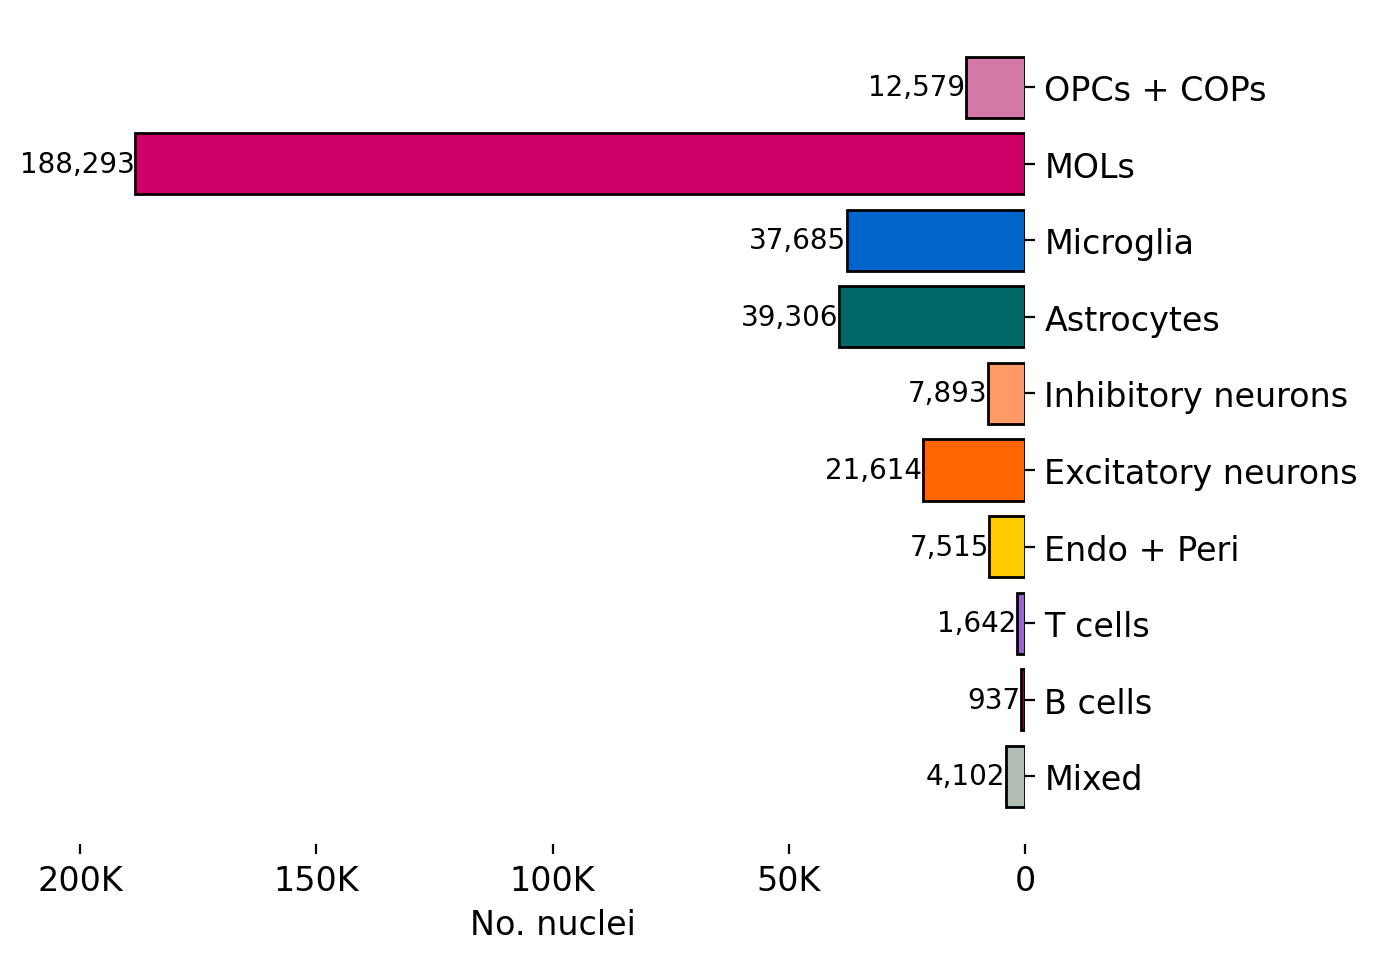

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define order and color map
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

cluster_simplified_color = {
    'OPCs + COPs': '#d279a6',
    'MOLs': '#cc0066',
    'Microglia': '#0066cc',
    'Astrocytes': '#006666',
    'Inhibitory neurons': '#ff9966',
    'Excitatory neurons': '#ff6600',
    'Endo + Peri': '#ffcc00',
    'T cells': '#9966cc',
    'B cells': '#990033',
    'Mixed': '#b2beb5'
}

# Count data
celltype_counts = (
    adata_all.obs['cluster_annotation']
    .value_counts()
    .reindex(celltype_order)
    .rename_axis('Cell type')
    .reset_index(name='N nuclei')
)
celltype_counts['color'] = celltype_counts['Cell type'].map(cluster_simplified_color)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    y=celltype_counts['Cell type'],
    width=celltype_counts['N nuclei'],
    color=celltype_counts['color'],
    edgecolor='black'
)

# Reverse y-axis and move to right
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # Add this line to flip bars horizontally

# Add value labels to bar ends, moved further off the bar
for i, (count, y_val) in enumerate(zip(celltype_counts['N nuclei'], celltype_counts['Cell type'])):
    ax.text(count + 100, i, f'{count:,}', va='center', fontsize=10, ha='right')


# Ticks, grid, styling
ax.set_xlabel('No. nuclei')
ax.set_ylabel('')
ax.set_xticks([0, 50000, 100000, 150000, 200000])
ax.set_xticklabels(['0', '50K', '100K', '150K', '200K'])

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()
plt.savefig("barchart_cell_type_reversed.png", dpi=300)
plt.show()

/tmp/ipykernel_861546/1303633133.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(celltype_counts['Cell type'], fontsize=tick_font_size)


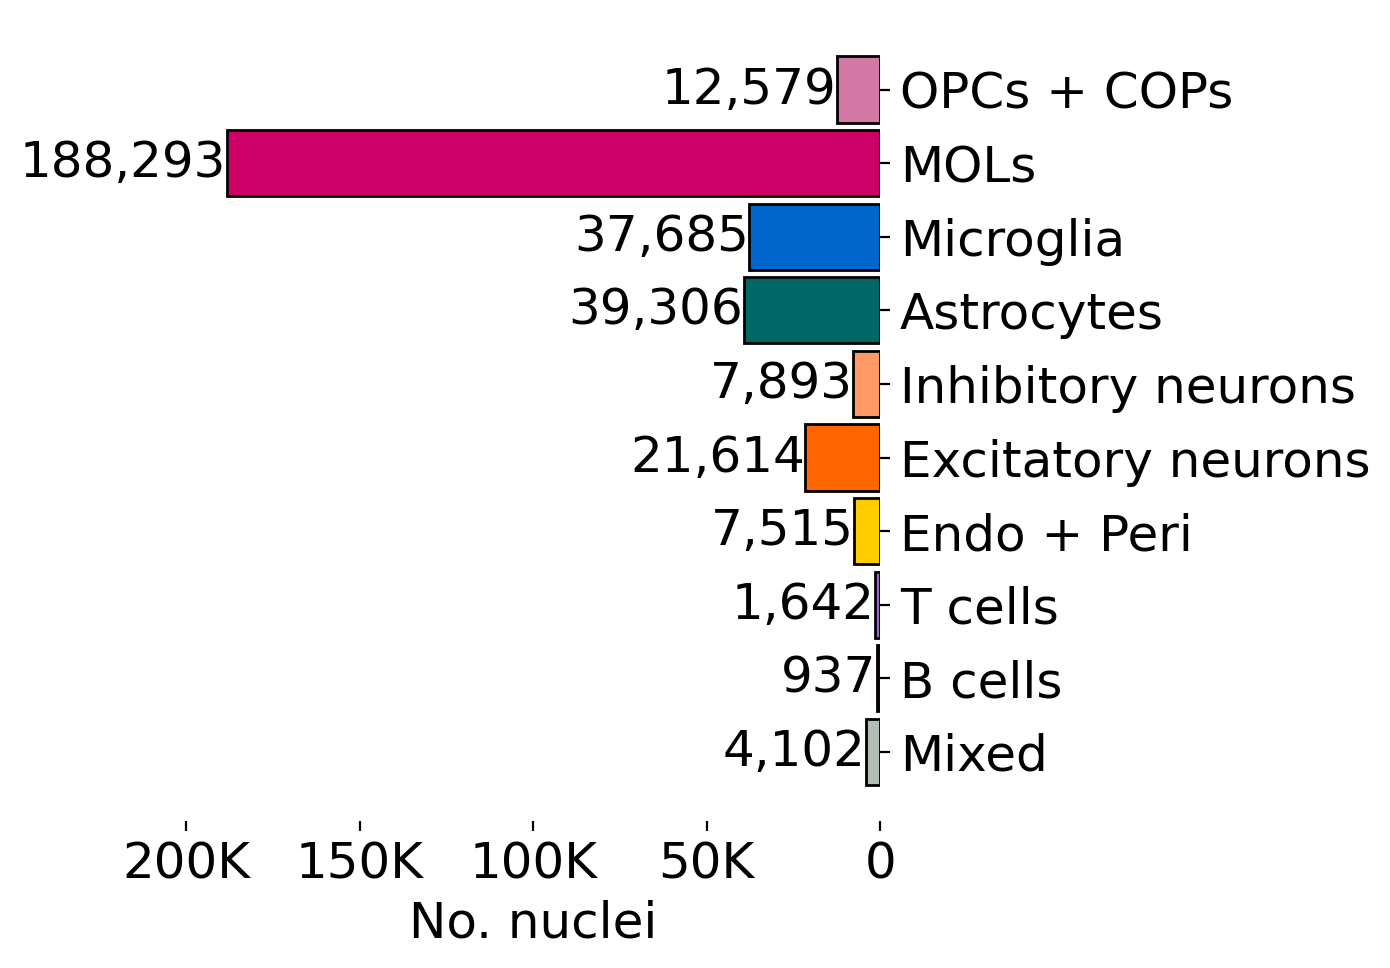

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Font size setting
font_size = 18         # main text (bar labels)
tick_font_size = 18    # ticks
label_font_size = 18   # axis labels

# Define order and color map
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

cluster_simplified_color = {
    'OPCs + COPs': '#d279a6',
    'MOLs': '#cc0066',
    'Microglia': '#0066cc',
    'Astrocytes': '#006666',
    'Inhibitory neurons': '#ff9966',
    'Excitatory neurons': '#ff6600',
    'Endo + Peri': '#ffcc00',
    'T cells': '#9966cc',
    'B cells': '#990033',
    'Mixed': '#b2beb5'
}

# Count data
celltype_counts = (
    adata_all.obs['cluster_annotation']
    .value_counts()
    .reindex(celltype_order)
    .rename_axis('Cell type')
    .reset_index(name='N nuclei')
)
celltype_counts['color'] = celltype_counts['Cell type'].map(cluster_simplified_color)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    y=celltype_counts['Cell type'],
    width=celltype_counts['N nuclei'],
    color=celltype_counts['color'],
    edgecolor='black',
    height=0.9
)

# Reverse y-axis and move to right
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()

# Add value labels to bar ends
for i, (count, y_val) in enumerate(zip(celltype_counts['N nuclei'], celltype_counts['Cell type'])):
    ax.text(count + 100, i, f'{count:,}', va='center', ha='right', fontsize=font_size)

# Axis labels and ticks
ax.set_xlabel('No. nuclei', fontsize=label_font_size)
ax.set_ylabel('')
ax.set_xticks([0, 50000, 100000, 150000, 200000])
ax.set_xticklabels(['0', '50K', '100K', '150K', '200K'], fontsize=tick_font_size)
ax.set_yticklabels(celltype_counts['Cell type'], fontsize=tick_font_size)

# Clean styling
sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()
plt.savefig("barchart_cell_type_reversed_human.png", dpi=300)
plt.show()

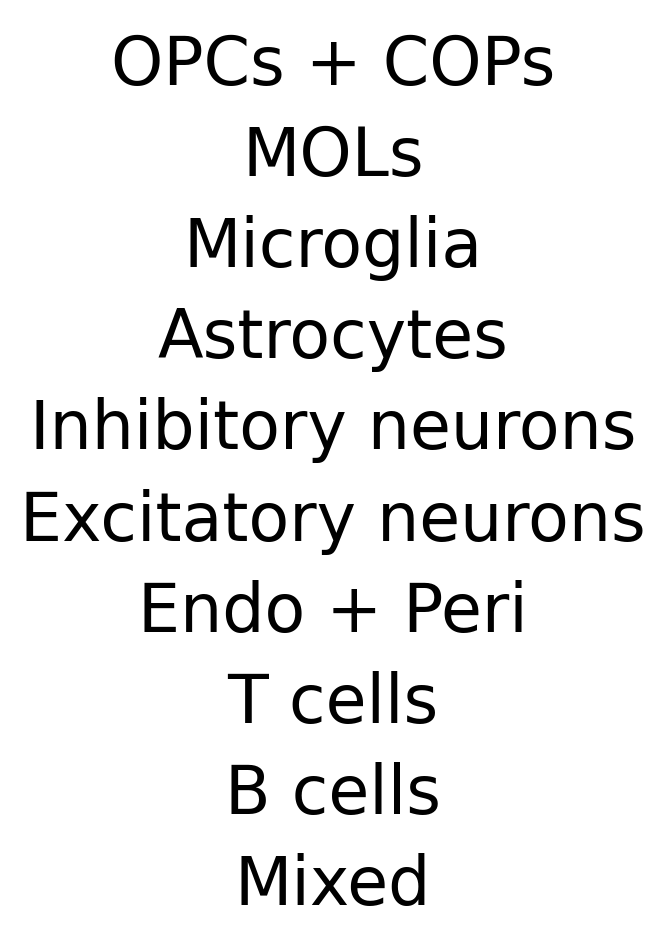

In [54]:
import matplotlib.pyplot as plt

# Define cell types
celltype_order = [
    'OPCs + COPs',
    'MOLs',
    'Microglia',
    'Astrocytes',
    'Inhibitory neurons',
    'Excitatory neurons',
    'Endo + Peri',
    'T cells',
    'B cells',
    'Mixed'
]

# Create figure
fig, ax = plt.subplots(figsize=(4, len(celltype_order) * 0.6))  # Height scales with number of items

# Turn off axes
ax.axis('off')

# Plot each cell type as centered text
for i, celltype in enumerate(celltype_order):
    ax.text(0.5, 1 - (i + 0.5)/len(celltype_order), celltype,
            ha='center', va='center', fontsize=24, transform=ax.transAxes)

# Save as PNG
plt.savefig('celltype_labels.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## MOL_5 outlier samples:

In [6]:
mol5_cells = adata.obs[adata.obs['OL_fine_type'] == 'MOL5'].copy()

print(len(mol5_cells))

# Count number of MOL5 cells per patient
mol5_counts = mol5_cells['sample_id_anon'].value_counts()

# Convert to a DataFrame for better visualization
mol5_counts_df = pd.DataFrame({'Patient_ID': mol5_counts.index, 'MOL5_Cell_Count': mol5_counts.values})

# Display the result
print(mol5_counts_df[:15])

6600

Patient_ID  MOL5_Cell_Count
0   Ind135-Sample1             1749
1   Ind144-Sample1             1144
2   Ind108-Sample4              502
3   Ind108-Sample5              490
4   Ind130-Sample3              438
5   Ind118-Sample3              401
6   Ind108-Sample1              237
7   Ind118-Sample2              113
8   Ind102-Sample4              113
9   Ind106-Sample2              101
10  Ind118-Sample4               72
11  Ind105-Sample1               69
12  Ind108-Sample3               67
13  Ind109-Sample3               62
14  Ind145-Sample1               62

In [7]:
# Compute quartiles and IQR
Q1 = np.percentile(mol5_counts, 25)
Q3 = np.percentile(mol5_counts, 75)
IQR = Q3 - Q1

# Compute outlier threshold
upper_threshold = Q3 + 1.5 * IQR

# Identify outliers
high_outliers = mol5_counts[mol5_counts > upper_threshold]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Upper threshold for high outliers: {upper_threshold}")
print(f"High outliers: {high_outliers}")

Q1: 3.0, Q3: 35.0, IQR: 32.0

Upper threshold for high outliers: 83.0

High outliers: sample_id_anon
Ind135-Sample1    1749
Ind144-Sample1    1144
Ind108-Sample4     502
Ind108-Sample5     490
Ind130-Sample3     438
Ind118-Sample3     401
Ind108-Sample1     237
Ind118-Sample2     113
Ind102-Sample4     113
Ind106-Sample2     101
Name: count, dtype: int64

In [8]:
# Define the high outlier samples
high_outlier_samples = [
    "Ind135-Sample1", "Ind144-Sample1", "Ind108-Sample4", "Ind108-Sample5",
    "Ind130-Sample3", "Ind118-Sample3", "Ind108-Sample1", "Ind102-Sample4",
    "Ind118-Sample2", "Ind106-Sample2"
]

# Select relevant columns
columns_of_interest = [
    'sample_id_anon', 'individual_id_anon', 'lesion_type', 'diagnosis',
    'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes'
]

# Filter for high outlier samples and select columns
outlier_info = adata.obs.loc[adata.obs['sample_id_anon'].isin(high_outlier_samples), columns_of_interest]

# Drop duplicates (if multiple cells per sample)
outlier_info = outlier_info.drop_duplicates()

# Count number of MOL5 cells per sample
mol5_counts = adata.obs[adata.obs['OL_fine_type'] == 'MOL5']['sample_id_anon'].value_counts().reset_index()
mol5_counts.columns = ['sample_id_anon', 'MOL5_Cell_Count']

# Merge MOL5 counts with the metadata
outlier_info = outlier_info.merge(mol5_counts, on='sample_id_anon', how='left')

# Sort by the highest number of MOL5 cells
outlier_info = outlier_info.sort_values(by='MOL5_Cell_Count', ascending=False)

# Display table
print(outlier_info)

sample_id_anon individual_id_anon lesion_type diagnosis sex  age_at_death  \
7  Ind135-Sample1             Ind135          WM       CTR   F            85   
8  Ind144-Sample1             Ind144          WM       CTR   M            85   
2  Ind108-Sample4             Ind108          RL      SPMS   F            47   
3  Ind108-Sample5             Ind108        NAWM      SPMS   F            47   
6  Ind130-Sample3             Ind130         CAL      SPMS   F            41   
5  Ind118-Sample3             Ind118        NAWM      PPMS   M            66   
1  Ind108-Sample1             Ind108         CIL      SPMS   F            47   
4  Ind118-Sample2             Ind118          AL      PPMS   M            66   
9  Ind102-Sample4             Ind102         CAL      SPMS   M            64   
0  Ind106-Sample2             Ind106        NAWM      SPMS   M            62   

       smoker                      cause_of_death  years_w_ms  pmi_minutes  \
7     unknown                         dehydration -2147483648          280   
8     unknown  heart failure / prostate carcinoma -2147483648          255   
2     unknown                      ms, aspiration -2147483648          540   
3     unknown                      ms, aspiration -2147483648          540   
6     unknown                       natural death          12          505   
5      smoker                               ileus          26          450   
1     unknown                      ms, aspiration -2147483648          540   
4      smoker                               ileus          26          450   
9  non-smoker       terminal phase ms; spastic ms          34          450   
0     unknown                                  ms          18         1860   

   MOL5_Cell_Count  
7             1749  
8             1144  
2              502  
3              490  
6              438  
5              401  
1              237  
4              113  
9              113  
0              101

/tmp/ipykernel_1019427/3595965482.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_order)


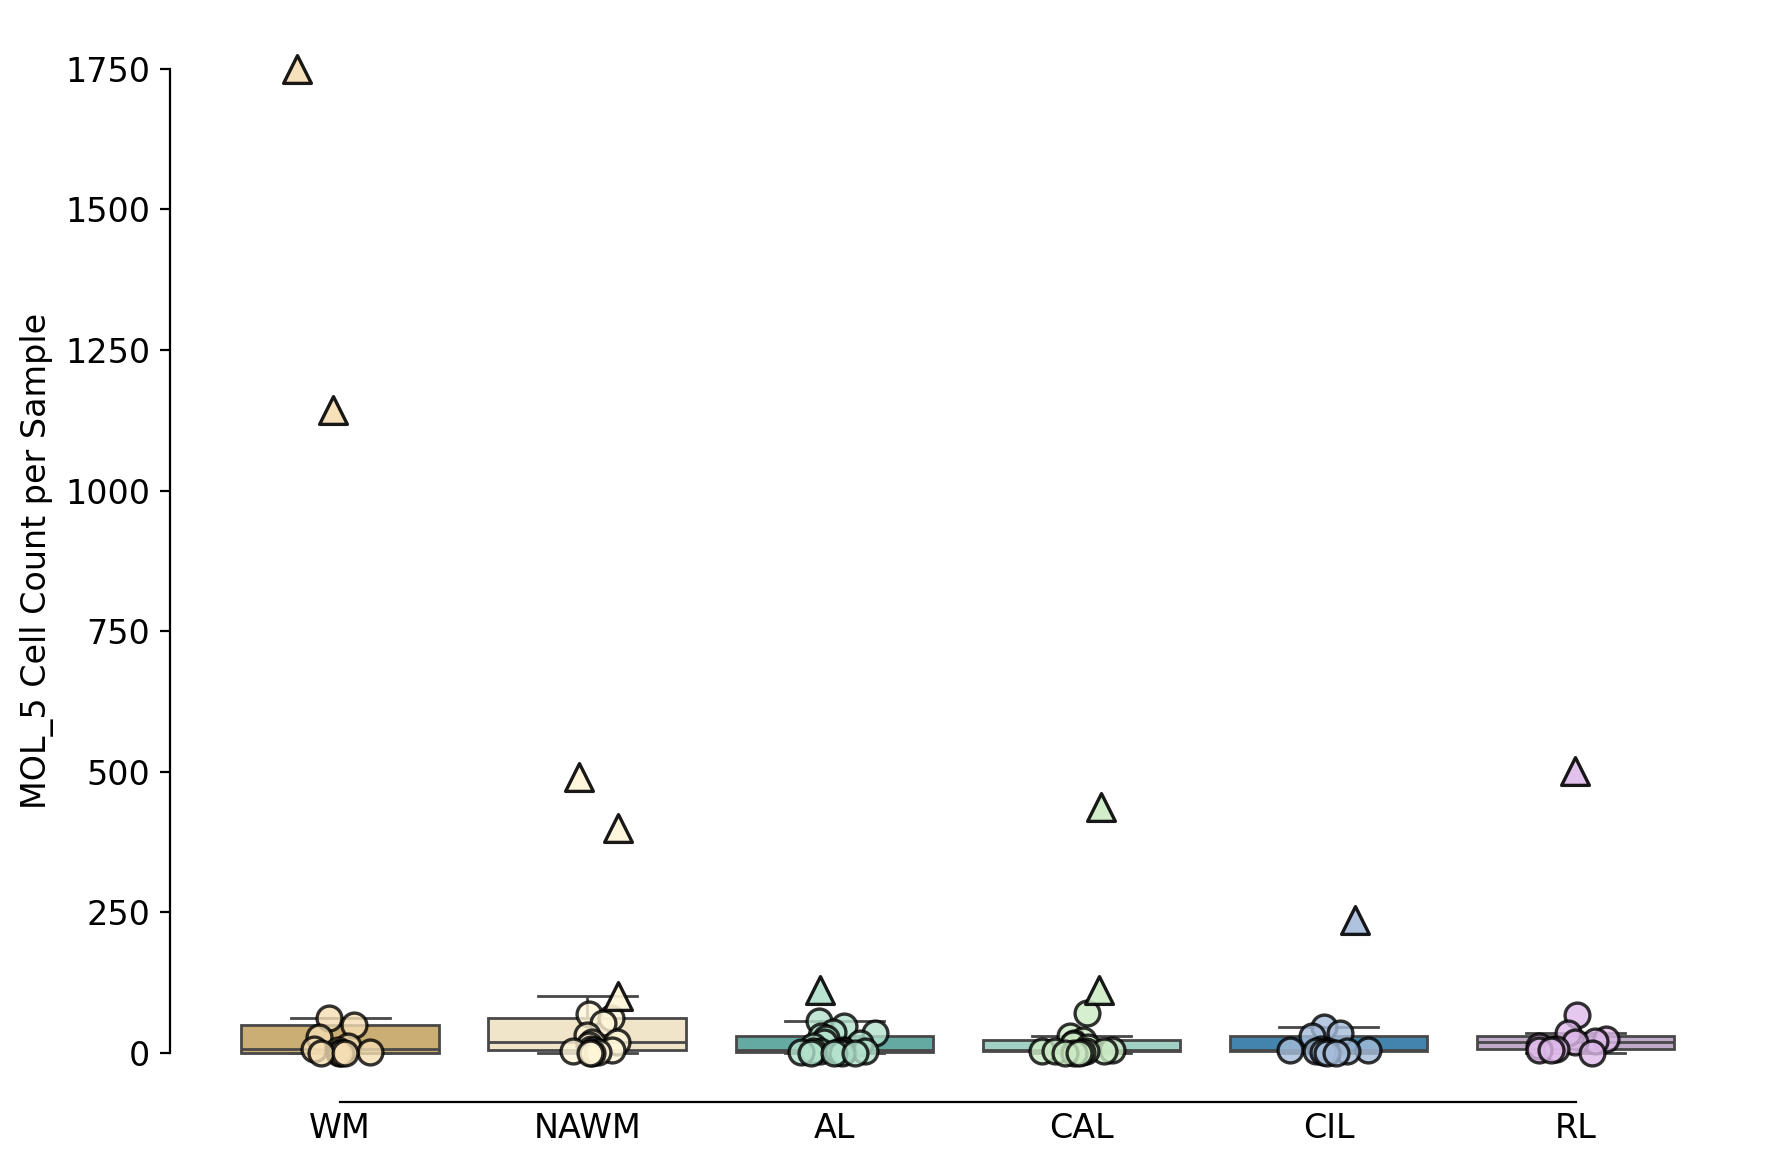

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the custom lesion order
custom_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']

# Filter only those lesion types (in case some are missing)
plot_df = mol5_counts_df[mol5_counts_df['lesion_type'].isin(custom_order)].copy()
plot_df['group'] = plot_df['lesion_type']
plot_df['sample'] = plot_df['Patient_ID']

# ✅ Define your custom colors here (use any hex or named colors)
custom_palette = {
    'WM': '#d8b365',
    'NAWM': '#f6e8c3',
    'AL': '#5ab4ac',
    'CAL': '#99d8c9',
    'CIL': '#3288bd',
    'RL': '#c2a5cf'
}

fill_palette = {
    'WM': '#f5deb3',
    'NAWM': '#fff5d7',
    'AL': '#b3e2cd',
    'CAL': '#ccebc5',
    'CIL': '#a6bddb',
    'RL': '#e0bbec'
}

# Start the plot
plt.figure(figsize=(9, 6))
ax = sns.boxplot(
    data=plot_df,
    x='group',
    y='MOL5_Cell_Count',
    hue='group',
    palette=custom_palette,
    order=custom_order,
    hue_order=custom_order,
    dodge=False,
    legend=False,
    showfliers=False
)

# Clean x-axis
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels(custom_order)
ax.tick_params(axis='x', which='both', length=0)

# Jittered scatter overlay
for pos, group in enumerate(custom_order):
    subset = plot_df[plot_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.08, size=len(subset))
    
    is_outlier = subset['is_outlier'].values

    # Regular points
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'MOL5_Cell_Count'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'MOL5_Cell_Count'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

# Tidy up
plt.ylabel('MOL_5 Cell Count per Sample')
plt.xlabel('')
plt.grid(False)
sns.despine(trim=True)
plt.tight_layout()
plt.savefig("mol5_boxplot_by_lesiontype_ordered.png", dpi=300)
plt.show()

/tmp/ipykernel_1019427/1184633748.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_order)


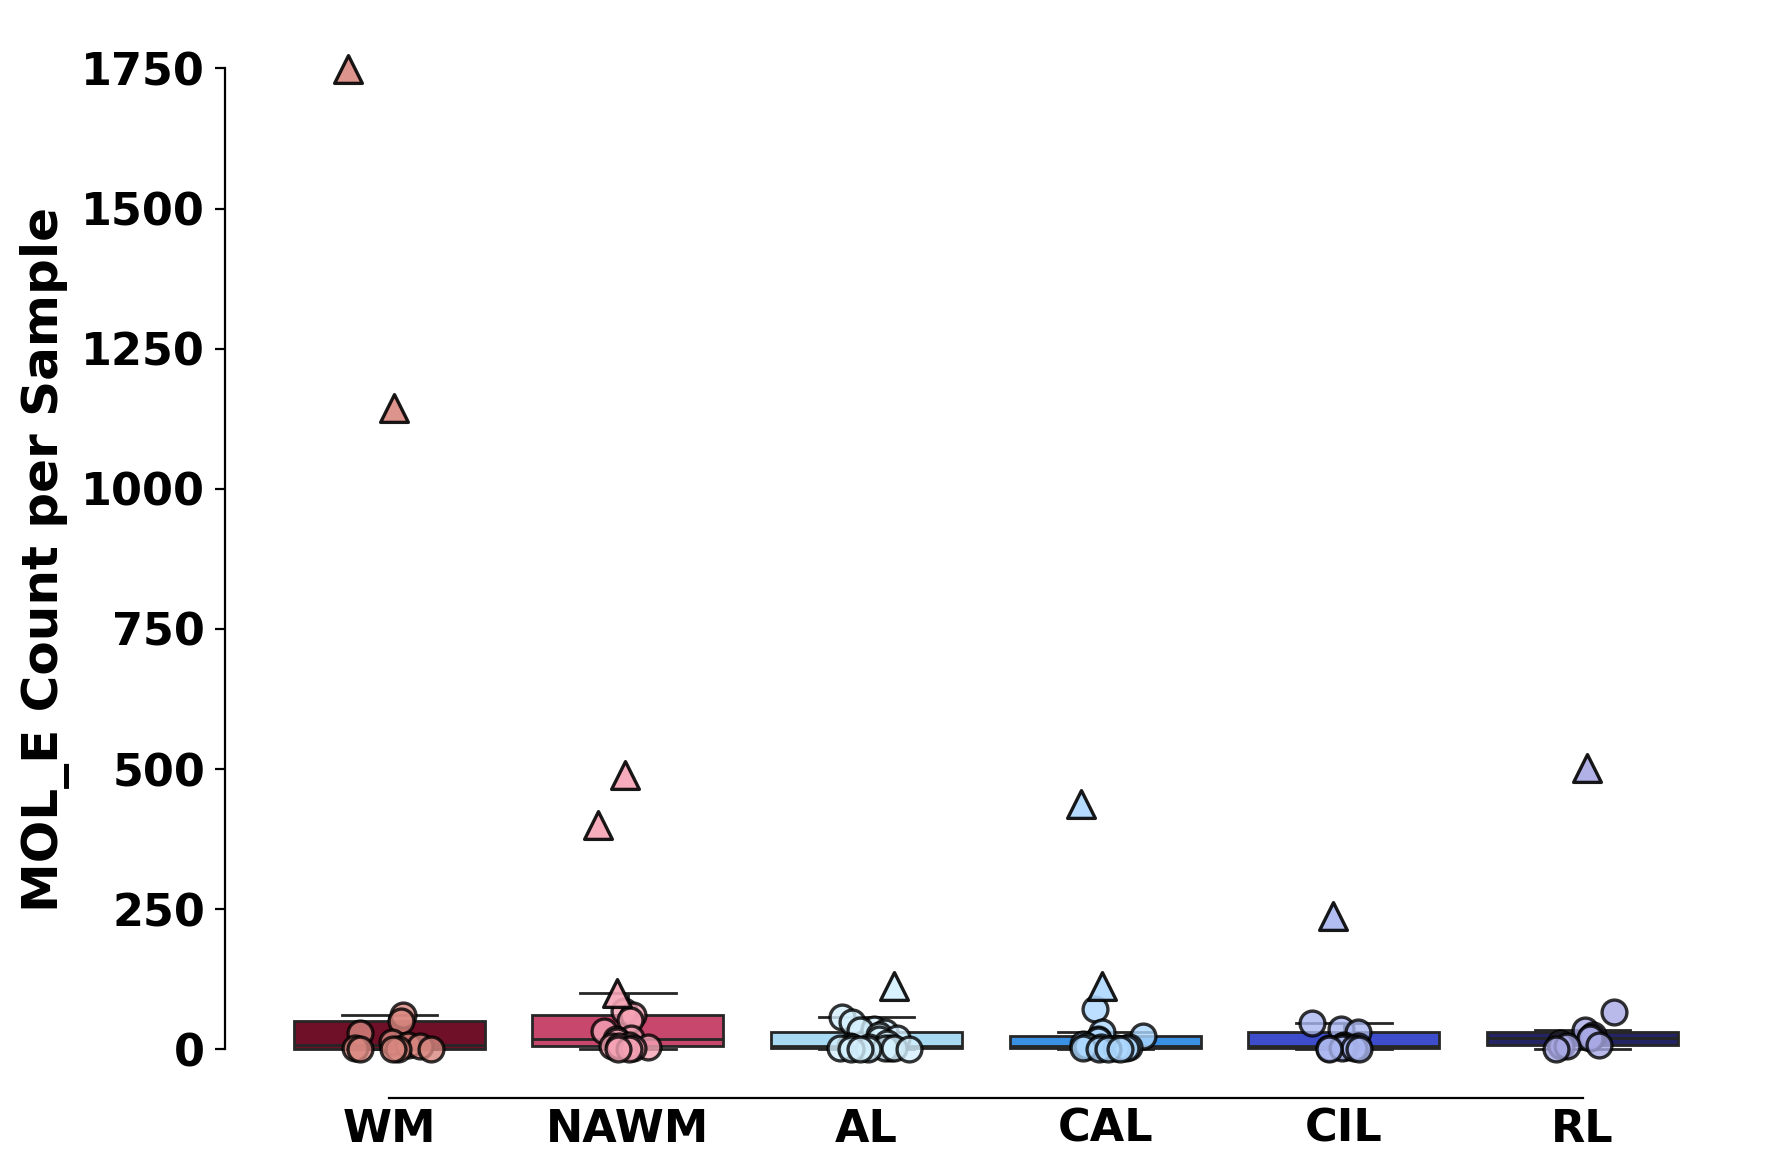

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the custom lesion order
custom_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']

# Filter only those lesion types (in case some are missing)
plot_df = mol5_counts_df[mol5_counts_df['lesion_type'].isin(custom_order)].copy()
plot_df['group'] = plot_df['lesion_type']
plot_df['sample'] = plot_df['Patient_ID']

# ✅ Define your custom colors here (use any hex or named colors)
custom_palette = {
    "WM": "#800020",
    "NAWM": "#de3163",
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "RL": "#191970"
}

fill_palette = {
    "WM": "#d98880",
    "NAWM": "#f5a3b5",
    "AL": "#d4f1ff",
    "CAL": "#add8ff",
    "CIL": "#aab7f0",
    "RL": "#a9a9e5"
}

# Start the plot
plt.figure(figsize=(9, 6))
ax = sns.boxplot(
    data=plot_df,
    x='group',
    y='MOL5_Cell_Count',
    hue='group',
    palette=custom_palette,
    order=custom_order,
    hue_order=custom_order,
    dodge=False,
    legend=False,
    showfliers=False
)

# Clean x-axis
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels(custom_order)
ax.tick_params(axis='x', which='both', length=0)

# Jittered scatter overlay
for pos, group in enumerate(custom_order):
    subset = plot_df[plot_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.08, size=len(subset))
    
    is_outlier = subset['is_outlier'].values

    # Regular points
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'MOL5_Cell_Count'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangles
    plt.scatter(
        x_jittered[is_outlier],
        subset.loc[is_outlier, 'MOL5_Cell_Count'],
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

# Make text larger and bold
plt.ylabel('MOL_E Count per Sample', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')    
    
# Tidy up
plt.grid(False)
sns.despine(trim=True)
plt.tight_layout()
plt.savefig("mol5_boxplot_by_lesiontype_ordered.png", dpi=300)
plt.show()

/tmp/ipykernel_1019427/375040680.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_order)


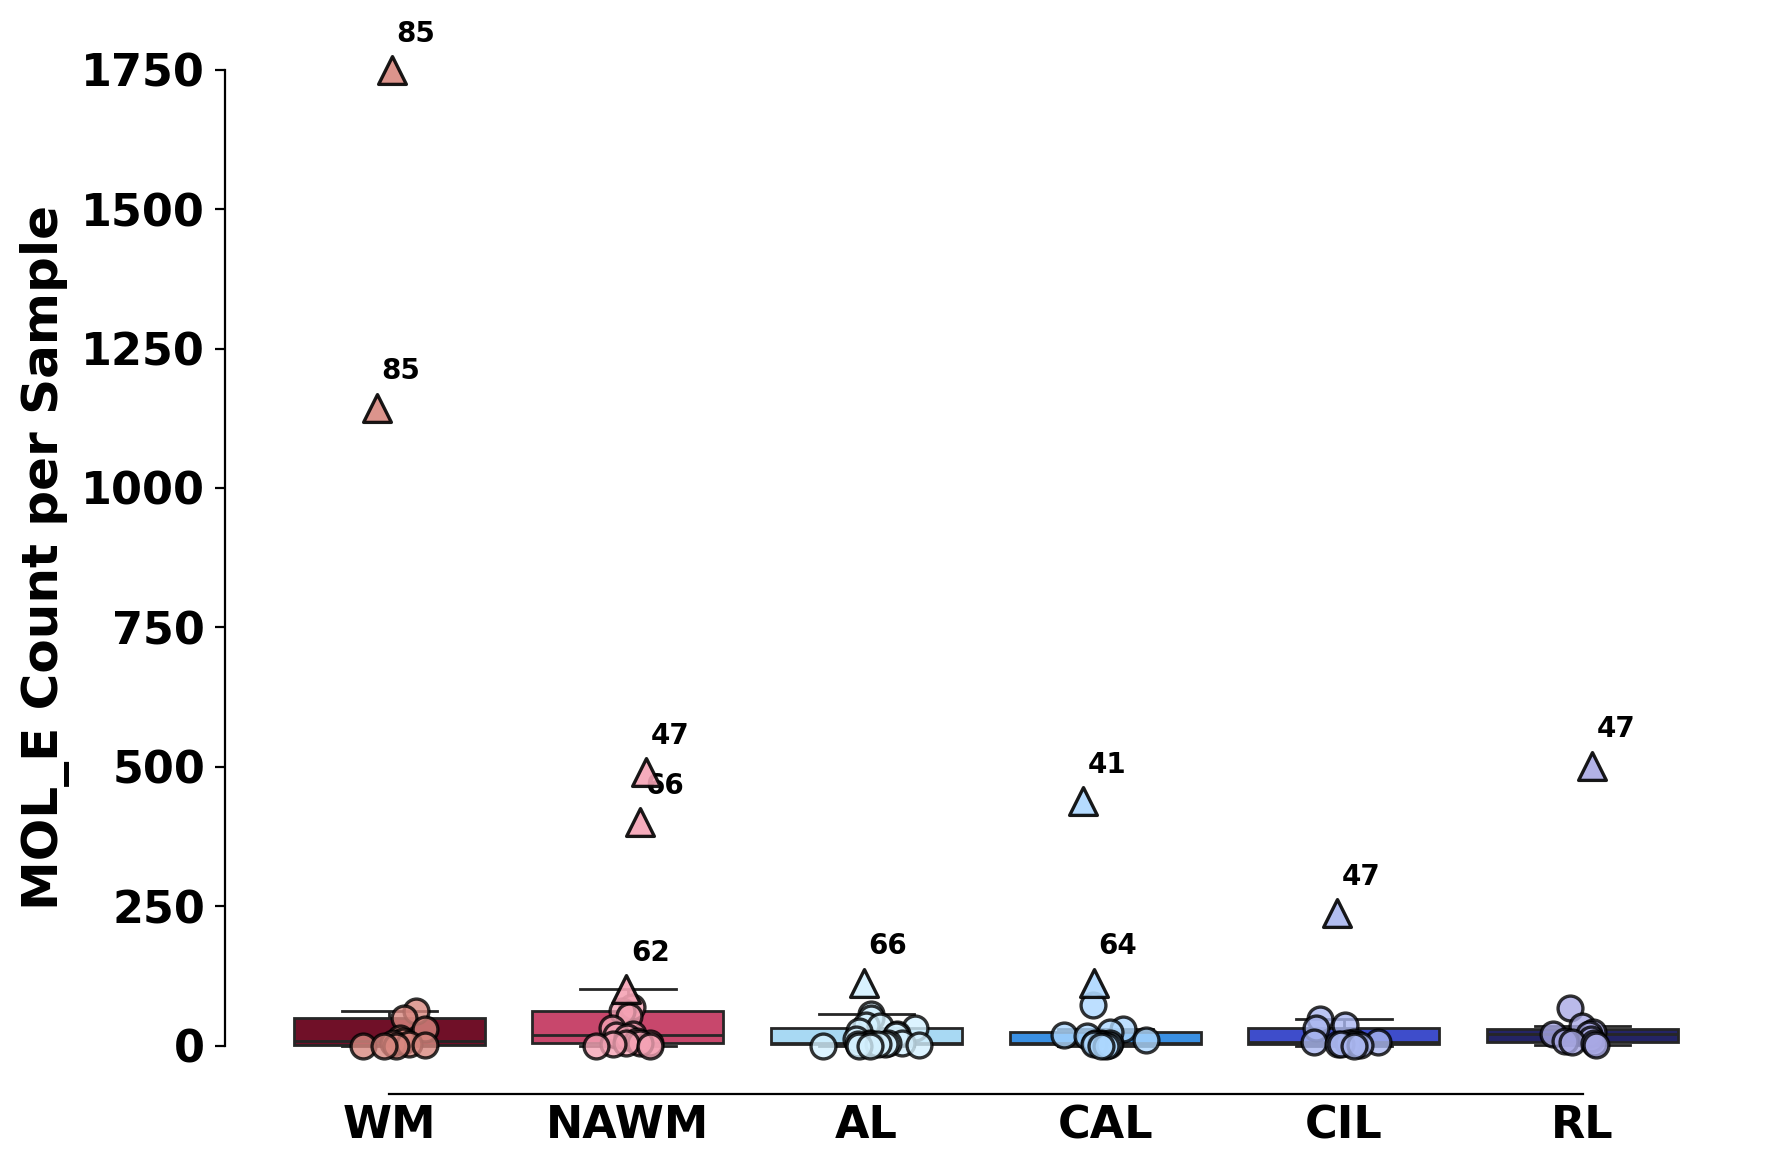

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the custom lesion order
custom_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']

# Filter only those lesion types (in case some are missing)
plot_df = mol5_counts_df[mol5_counts_df['lesion_type'].isin(custom_order)].copy()
plot_df['group'] = plot_df['lesion_type']
plot_df['sample'] = plot_df['Patient_ID']

# ✅ Define your custom colors here (use any hex or named colors)
custom_palette = {
    "WM": "#800020",
    "NAWM": "#de3163",
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "RL": "#191970"
}

fill_palette = {
    "WM": "#d98880",
    "NAWM": "#f5a3b5",
    "AL": "#d4f1ff",
    "CAL": "#add8ff",
    "CIL": "#aab7f0",
    "RL": "#a9a9e5"
}

# Start the plot
plt.figure(figsize=(9, 6))
ax = sns.boxplot(
    data=plot_df,
    x='group',
    y='MOL5_Cell_Count',
    hue='group',
    palette=custom_palette,
    order=custom_order,
    hue_order=custom_order,
    dodge=False,
    legend=False,
    showfliers=False
)

# Clean x-axis
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels(custom_order)
ax.tick_params(axis='x', which='both', length=0)

# Jittered scatter overlay
for pos, group in enumerate(custom_order):
    subset = plot_df[plot_df['group'] == group]
    x_jittered = np.random.normal(loc=pos, scale=0.08, size=len(subset))
    
    is_outlier = subset['is_outlier'].values

    # Regular points
    plt.scatter(
        x_jittered[~is_outlier],
        subset.loc[~is_outlier, 'MOL5_Cell_Count'],
        s=80,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.8,
        marker='o',
        zorder=10
    )

    # Outlier triangle coordinates
    y_outliers = subset.loc[is_outlier, 'MOL5_Cell_Count']
    x_outliers = x_jittered[is_outlier]
    sample_ids = subset.loc[is_outlier, 'sample'].values

    # Plot triangle markers
    plt.scatter(
        x_outliers,
        y_outliers,
        s=100,
        facecolor=fill_palette[group],
        edgecolors='black',
        linewidth=1.2,
        alpha=0.9,
        marker='^',
        zorder=11
    )

    # Annotate with age at death
    for xi, yi, sample_id in zip(x_outliers, y_outliers, sample_ids):
        match = outlier_info[outlier_info['sample_id_anon'] == sample_id]
        if not match.empty:
            age = match['age_at_death'].values[0]
            plt.text(
                xi + 0.1, yi + 40,  # Offset label above triangle
                f"{age}",     # Label = age only
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold'
            )

# Make text larger and bold
plt.ylabel('MOL_E Count per Sample', fontsize=18, fontweight='bold')
plt.xlabel('', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')    
    
# Tidy up
plt.grid(False)
sns.despine(trim=True)
plt.tight_layout()
plt.savefig("mol5_boxplot_by_lesiontype_ordered.png", dpi=300)
plt.show()

# Redo barchart

In [104]:
pd.set_option('display.max_columns', None)

In [105]:
# Identify donors with multiple unique sample IDs
adata_df = adata_all.obs.copy()

# Identify donors with multiple unique sample IDs
donor_sample_counts = adata_df.groupby('individual_id_anon')['sample_id_anon'].nunique()
print(len(donor_sample_counts))
donor_sample_counts

47

individual_id_anon
Ind86     1
Ind98     1
Ind101    4
Ind102    4
Ind103    1
Ind104    3
Ind105    1
Ind106    2
Ind107    1
Ind108    6
Ind109    3
Ind110    1
Ind111    1
Ind112    2
Ind113    3
Ind114    3
Ind115    2
Ind116    3
Ind117    1
Ind118    4
Ind119    1
Ind120    2
Ind121    1
Ind122    2
Ind123    3
Ind124    1
Ind125    1
Ind126    1
Ind127    5
Ind128    1
Ind130    5
Ind131    1
Ind132    2
Ind133    1
Ind134    4
Ind135    1
Ind136    1
Ind137    1
Ind139    1
Ind140    1
Ind141    2
Ind142    2
Ind143    1
Ind144    1
Ind145    1
Ind146    1
Ind147    1
Name: sample_id_anon, dtype: int64

In [106]:
# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Display the resulting table
pivoted_counts.head()

lesion_type,AL,CAL,CIL,NAWM,RL,WM
individual_id_anon,,,,,,
Ind86,0.0,0.0,0.0,0.0,0.0,1.0
Ind98,0.0,0.0,0.0,0.0,0.0,1.0
Ind101,0.0,0.0,2.0,1.0,1.0,0.0
Ind102,1.0,2.0,1.0,0.0,0.0,0.0
Ind103,1.0,0.0,0.0,0.0,0.0,0.0


In [107]:
# Calculate the sum of all columns
column_sums = pivoted_counts.sum(axis=0)

# Display the results
print("Column sums (total samples per lesion type):")
print(column_sums)

Column sums (total samples per lesion type):

lesion_type
AL      21.0
CAL     17.0
CIL     13.0
NAWM    17.0
RL      11.0
WM      13.0
dtype: float64

<Figure size 1200x800 with 0 Axes>

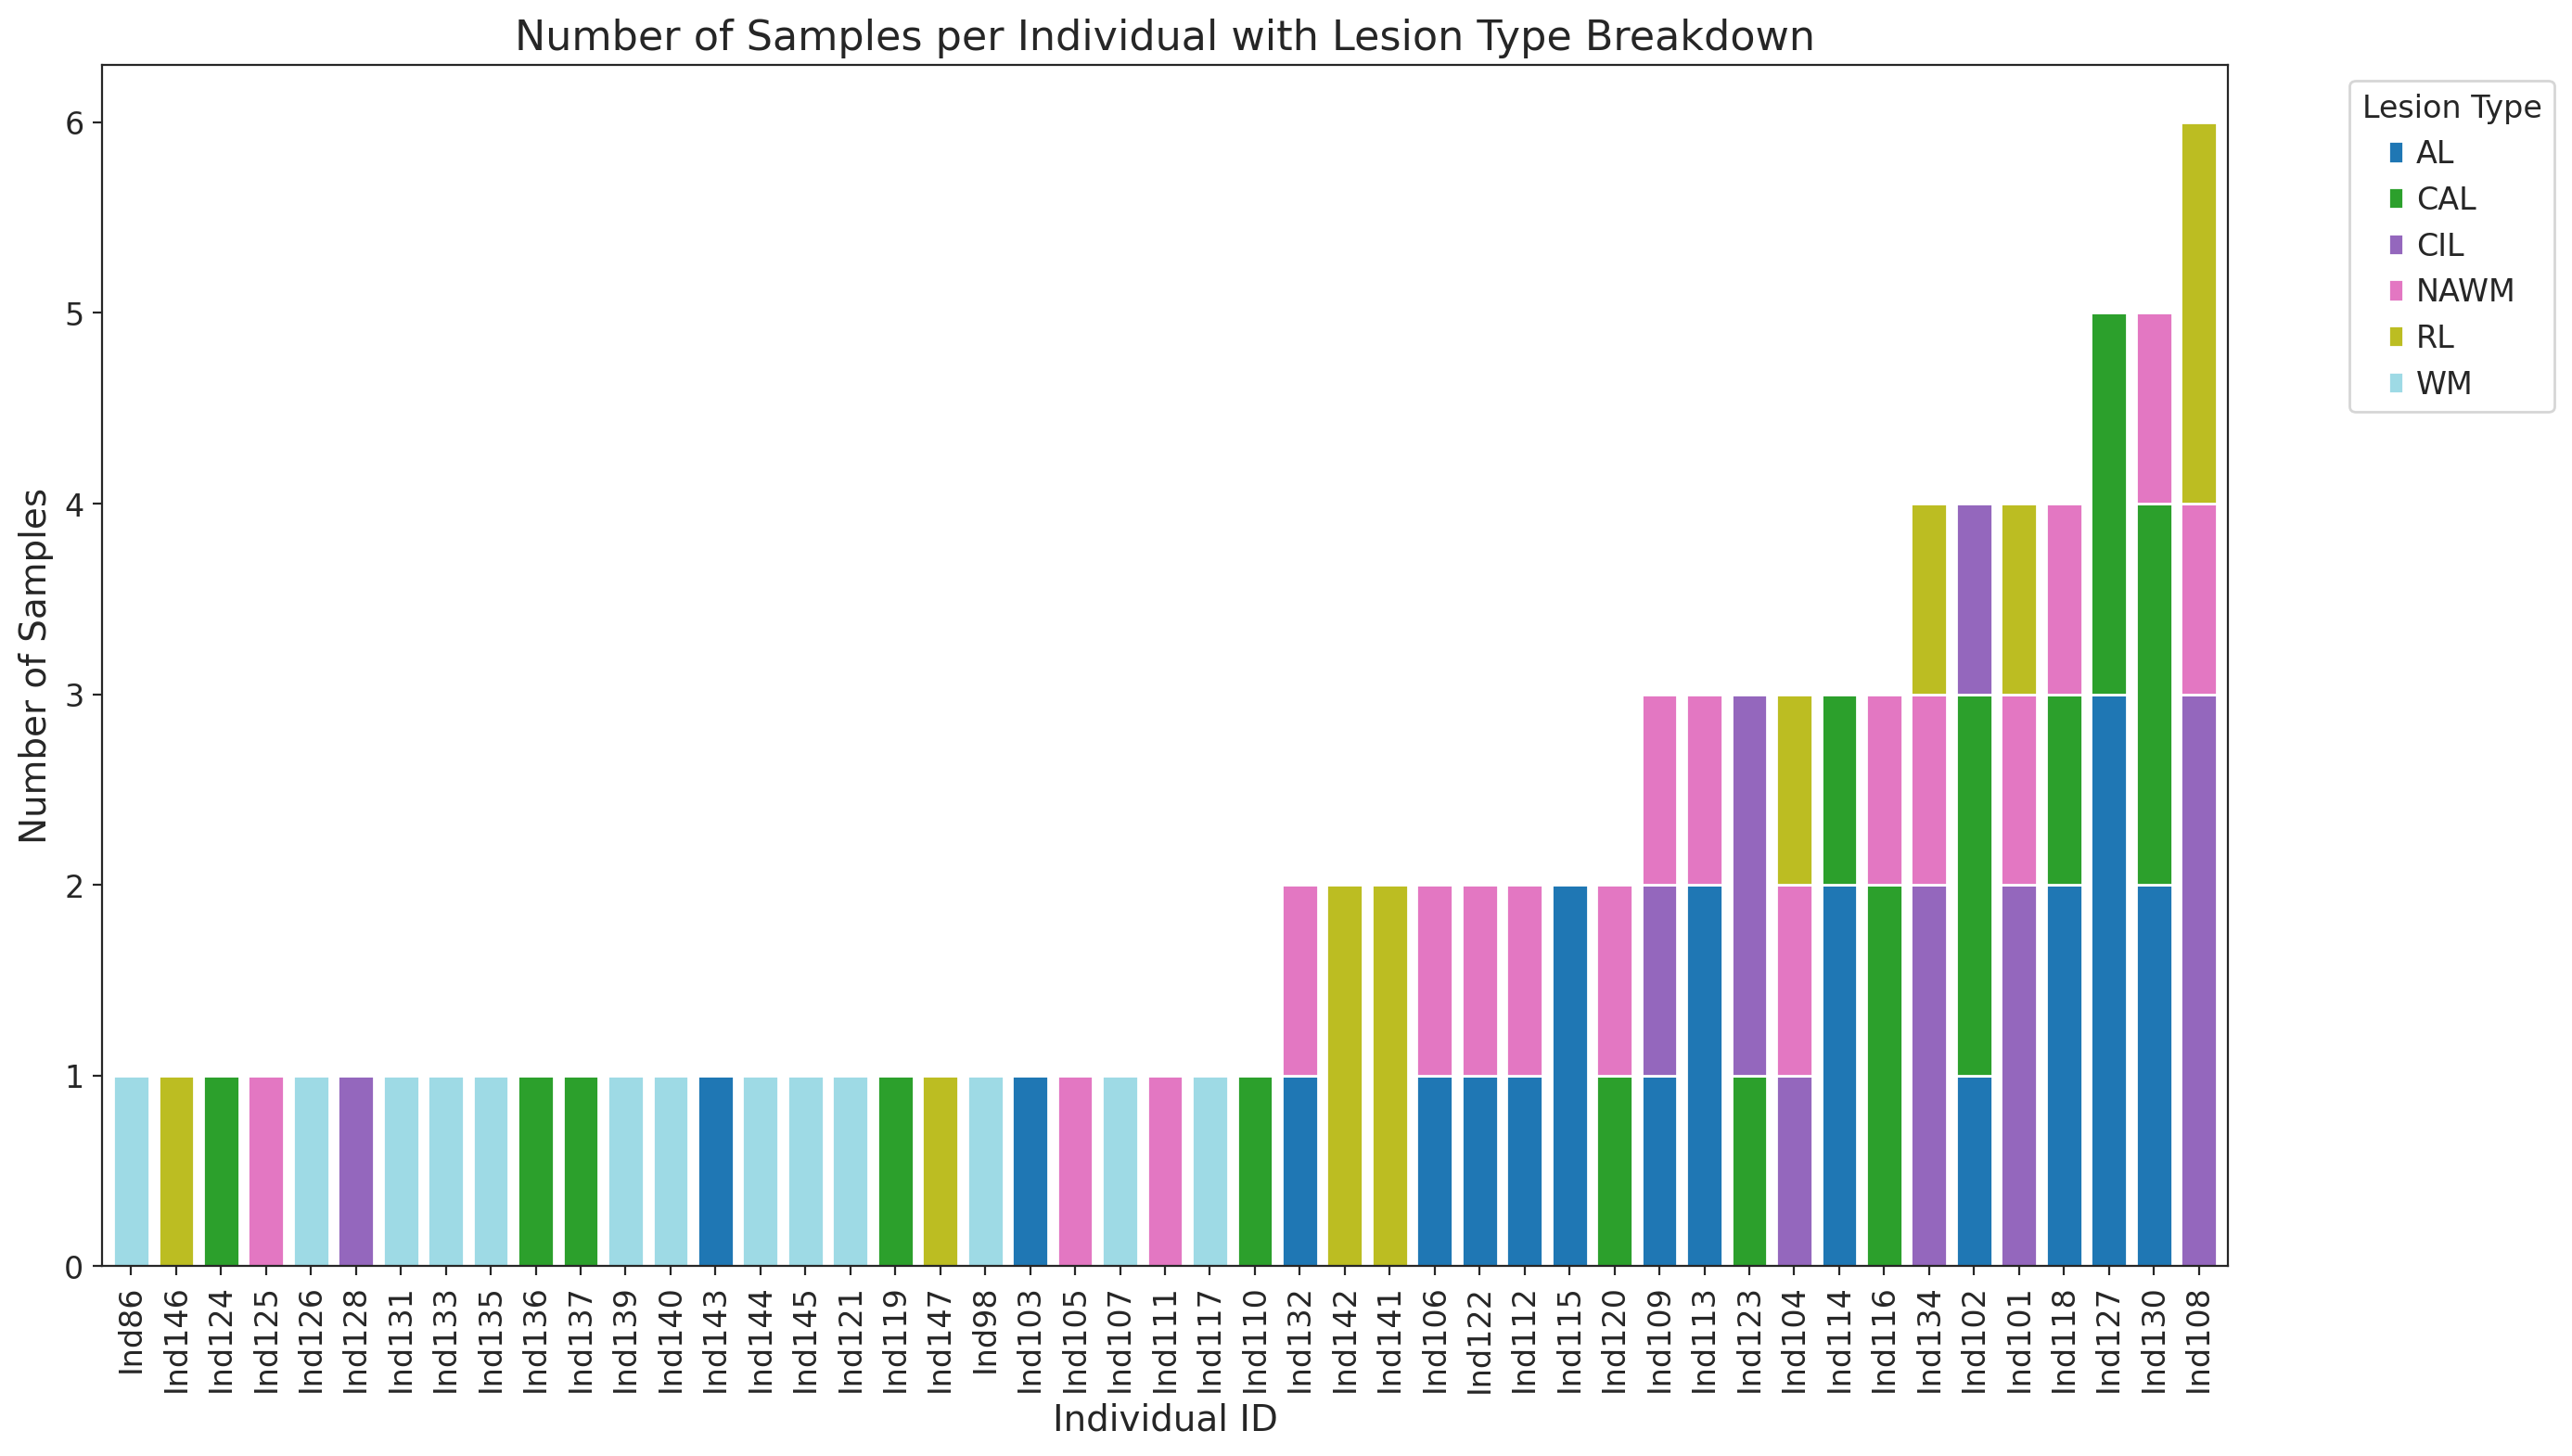

In [108]:
# Pivot the table for plotting
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Sort individuals by the number of samples
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)
pivoted_counts = pivoted_counts.sort_values(by='total_samples')

# Plot
plt.figure(figsize=(12, 8))
ax = pivoted_counts.drop('total_samples', axis=1).plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8, colormap='tab20')

# Customize the plot
plt.title('Number of Samples per Individual with Lesion Type Breakdown', fontsize=16)
plt.xlabel('Individual ID', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(rotation=90)
plt.legend(title='Lesion Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(False)  # Remove grid lines

plt.tight_layout()
plt.show()

In [109]:
# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Calculate total samples per individual
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)

# Sort individuals by the number of samples
pivoted_counts_sorted = pivoted_counts.sort_values(by='total_samples')

# Specify the desired lesion type order
desired_treatments_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']

# Reorder columns based on the desired treatment order and ensure 'total_samples' is retained
pivoted_counts_reordered = pivoted_counts_sorted[desired_treatments_order + ['total_samples']]

# Ensure DataFrame is sorted by total_samples and maintain correct order
pivoted_counts_reordered = pivoted_counts_reordered.sort_values(by='total_samples')

# Drop the total_samples column for plotting
pivoted_counts_plot = pivoted_counts_reordered.drop(columns=['total_samples'])

# Calculate the sum of all columns
column_sums = pivoted_counts_plot.sum(axis=0)

# Display the results
print("Column sums (total samples per lesion type):")
print(column_sums)

Column sums (total samples per lesion type):

lesion_type
WM      13.0
NAWM    17.0
AL      21.0
CAL     17.0
CIL     13.0
RL      11.0
dtype: float64

In [110]:
# Define the desired order of individuals
individual_order = [
    'Ind86', 'Ind117', 'Ind107', 'Ind98', 'Ind121', 'Ind145', 'Ind144', 'Ind139', 'Ind135', 'Ind133', 'Ind131', 'Ind126', 'Ind140',
    'Ind105', 'Ind111', 'Ind125',
    'Ind103', 'Ind143',
    'Ind110', 'Ind119', 'Ind137', 'Ind136', 'Ind124',
    'Ind128',
    'Ind147', 'Ind146',
    'Ind112', 'Ind122', 'Ind132', 'Ind106', 'Ind120', 'Ind115', 'Ind141', 'Ind142',
    'Ind113', 'Ind109', 'Ind116', 'Ind104', 'Ind114', 'Ind123',
    'Ind118', 'Ind101', 'Ind134', 'Ind102',
    'Ind130', 'Ind127', 'Ind108'
]

# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Calculate total samples per individual
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)

# Reorder the DataFrame based on the specific order of individual IDs
pivoted_counts_reordered = pivoted_counts.loc[individual_order]

# Drop the total_samples column for plotting
pivoted_counts_plot = pivoted_counts_reordered.drop(columns=['total_samples'])

# Calculate the sum of all columns
column_sums = pivoted_counts_plot.sum(axis=0)

# Display the results
print("Column sums (total samples per lesion type):")
print(column_sums)

Column sums (total samples per lesion type):

lesion_type
AL      21.0
CAL     17.0
CIL     13.0
NAWM    17.0
RL      11.0
WM      13.0
dtype: float64

<Figure size 1200x800 with 0 Axes>

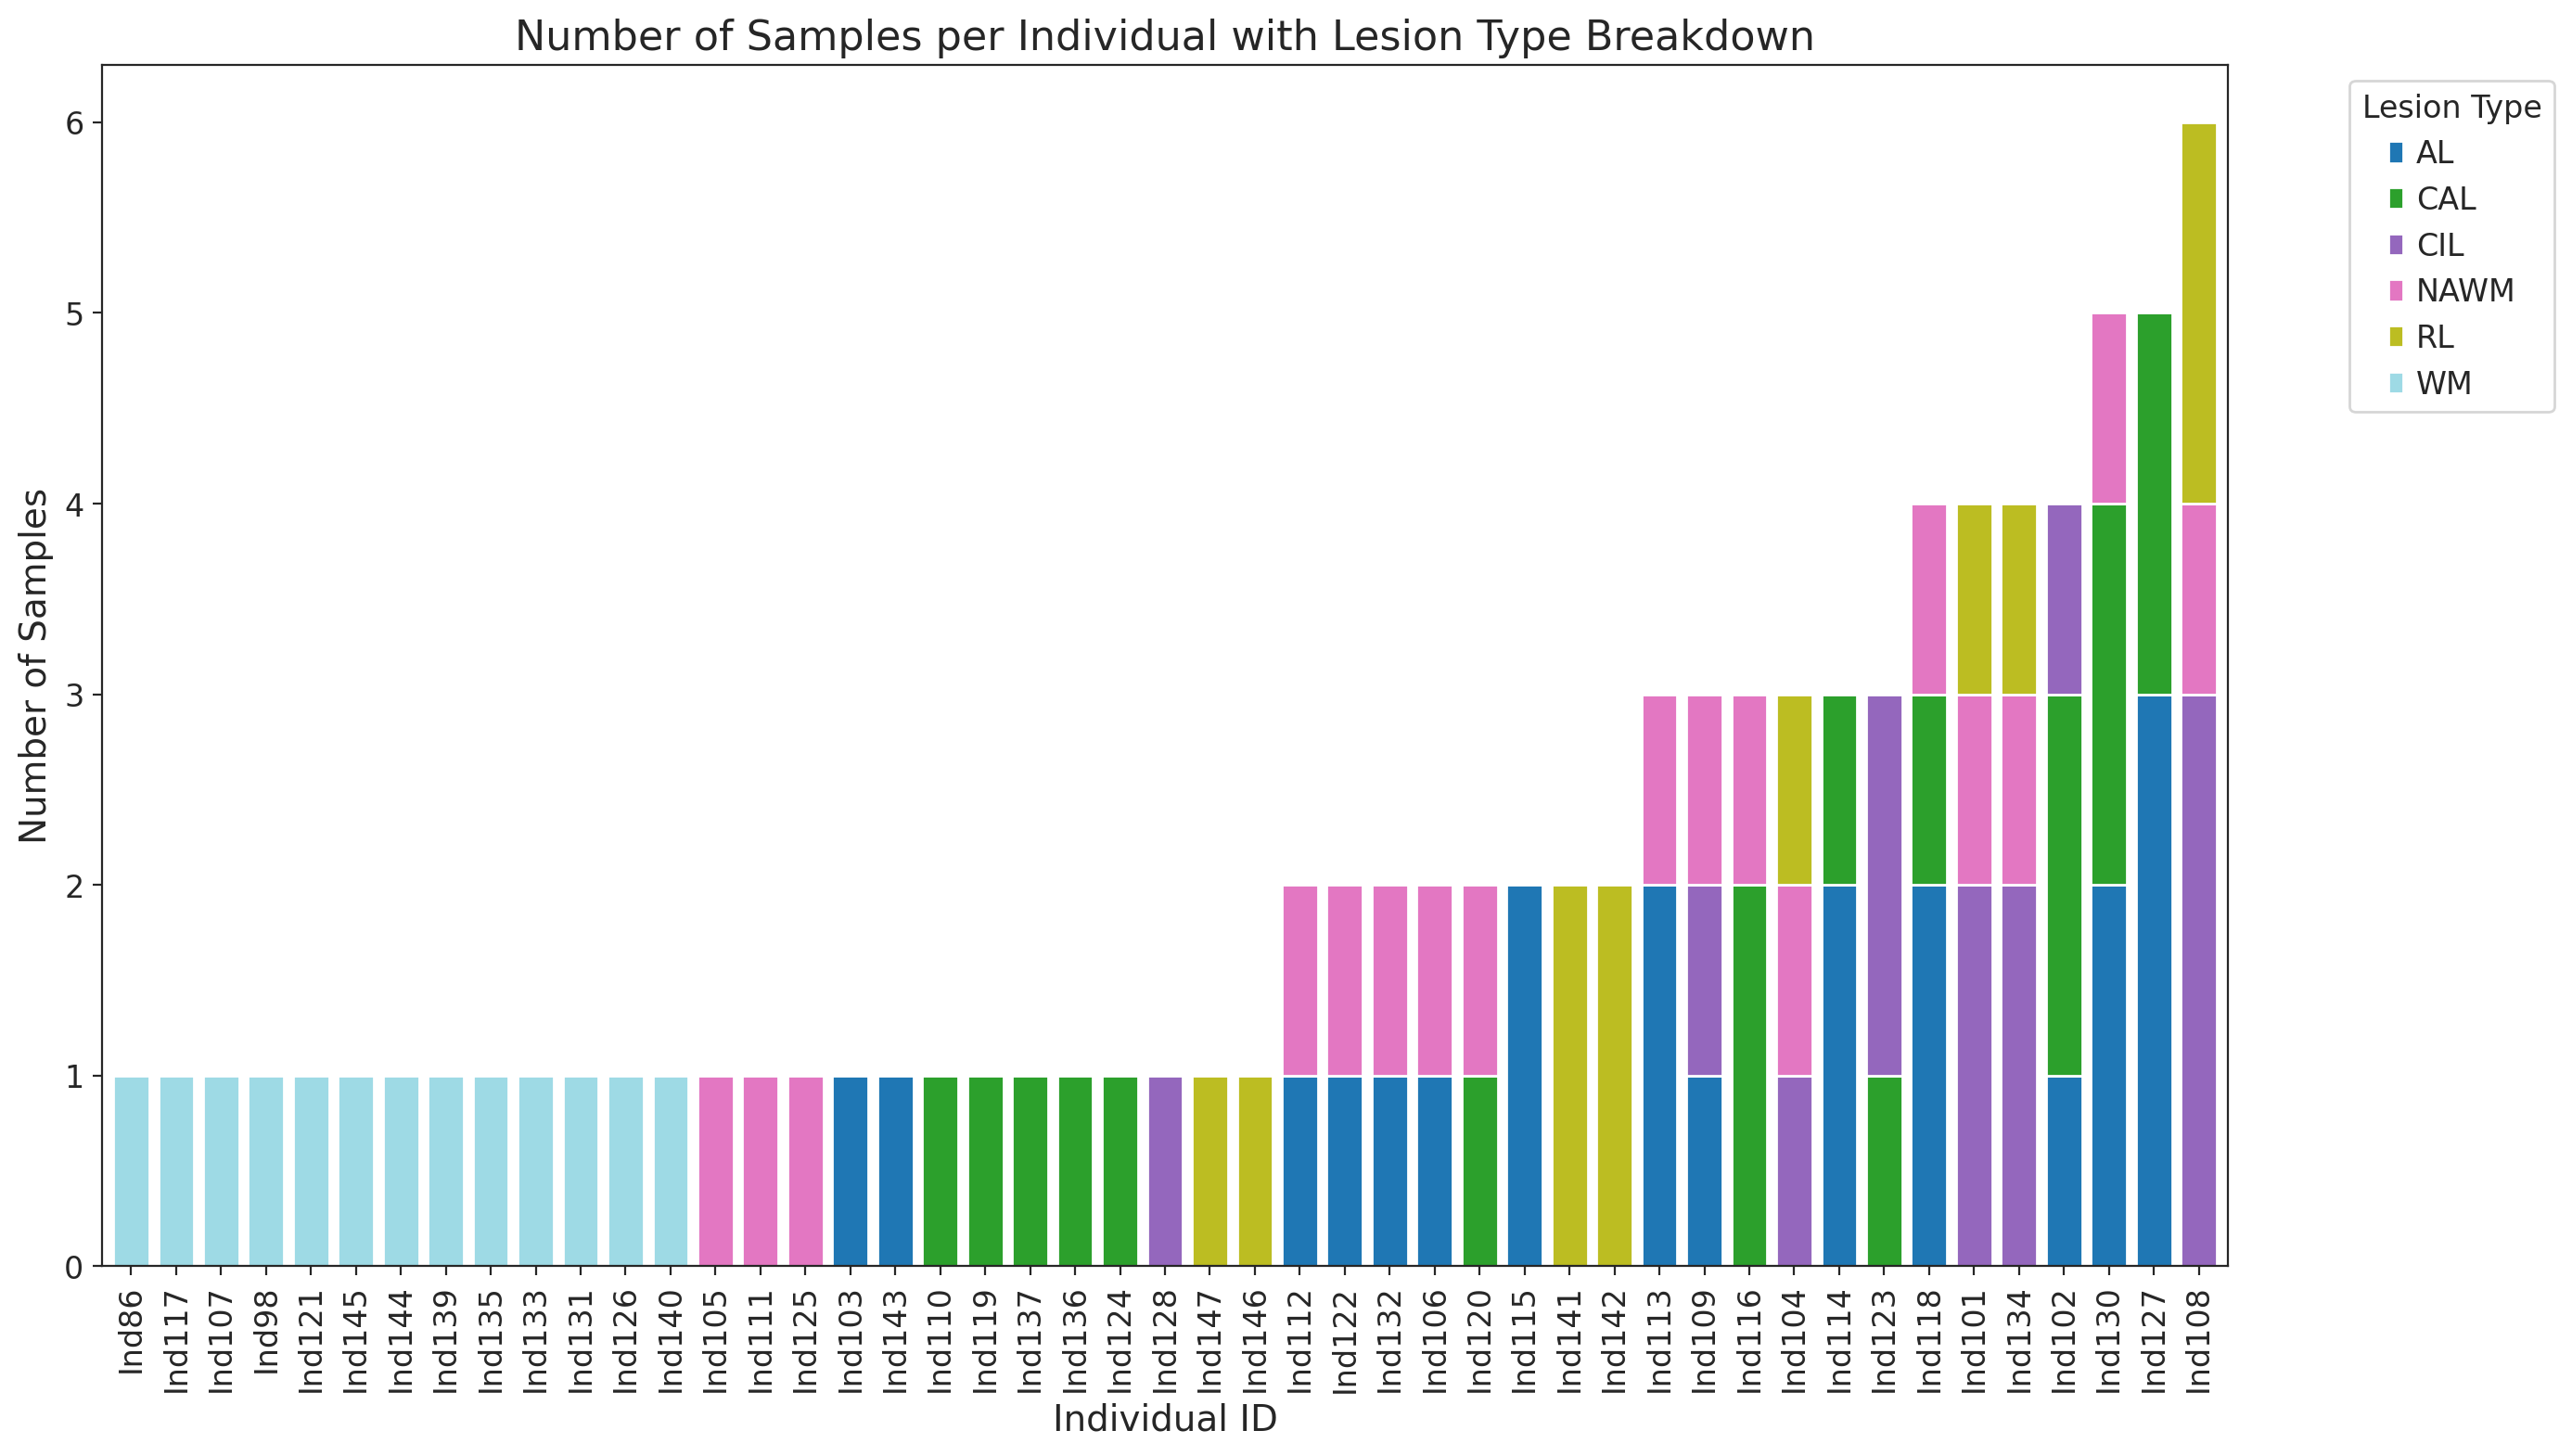

In [111]:
# Plot
plt.figure(figsize=(12, 8))
ax = pivoted_counts_plot.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8, colormap='tab20')

# Customize the plot
plt.title('Number of Samples per Individual with Lesion Type Breakdown', fontsize=16)
plt.xlabel('Individual ID', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(rotation=90)
plt.legend(title='Lesion Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(False)  # Remove grid lines

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

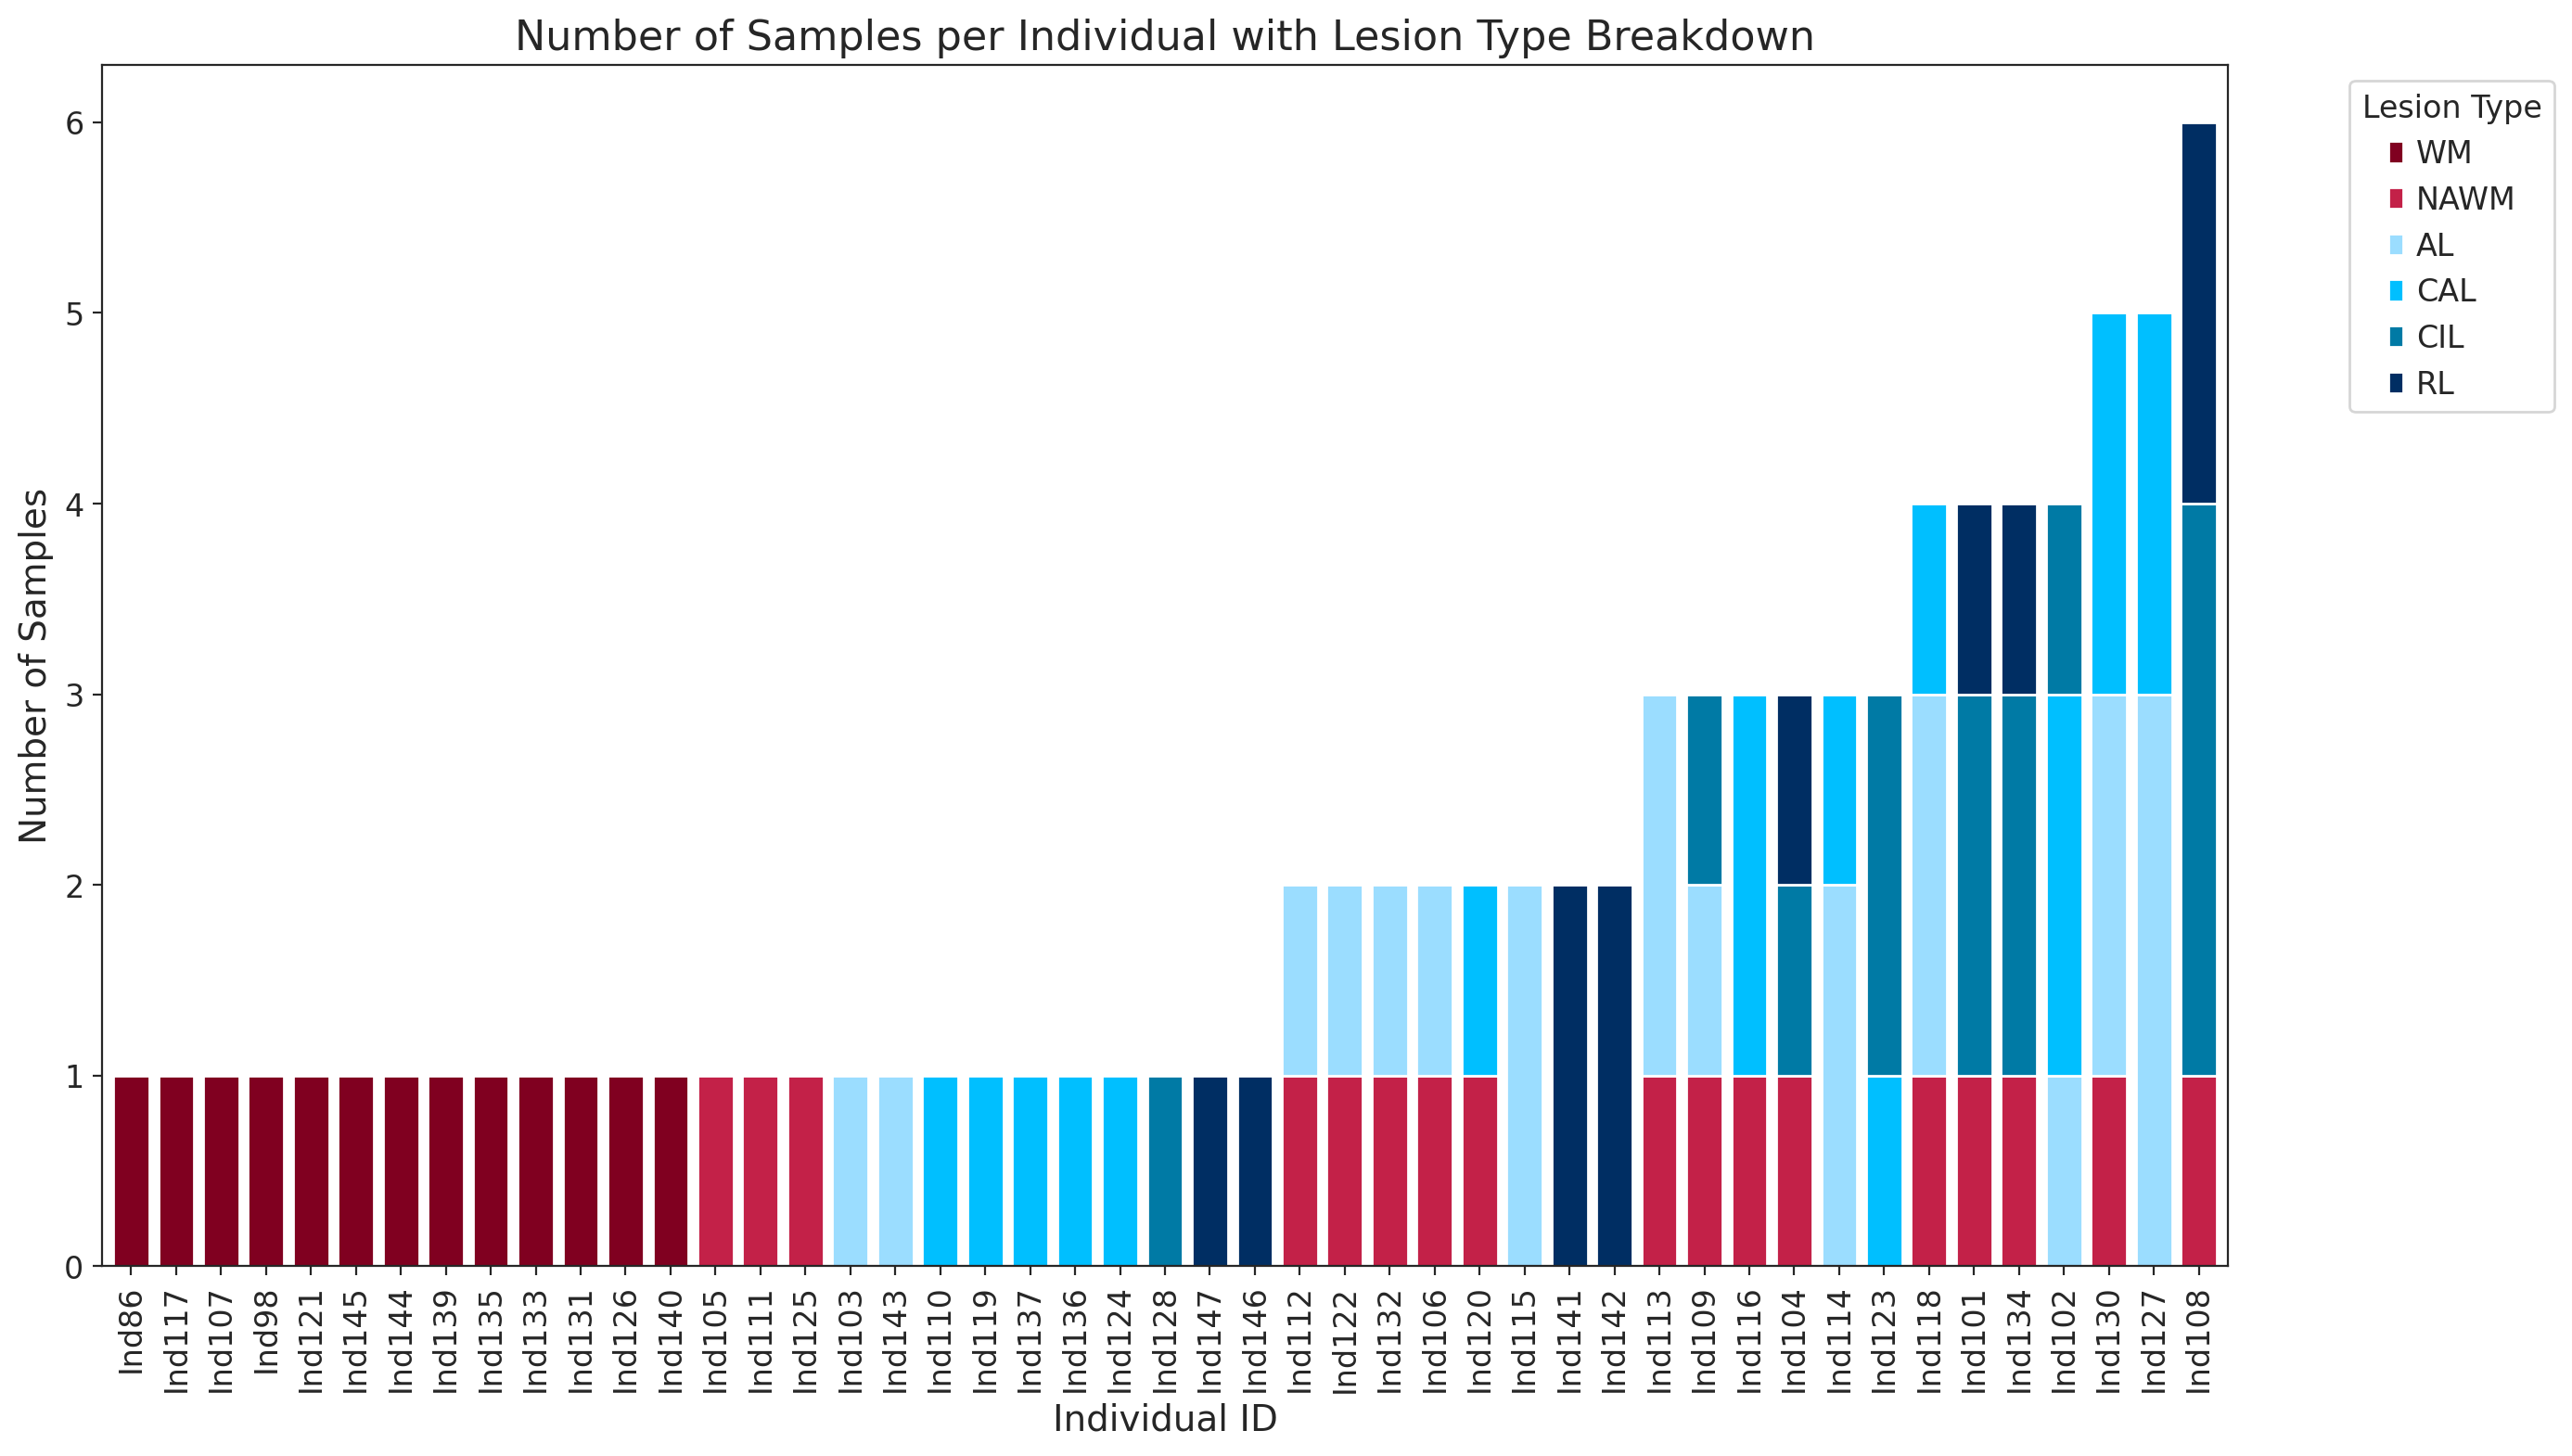

In [112]:
# Define the colors for each lesion type
colors = {
    'WM': '#800020',
    'NAWM': '#c32148',
    'AL': '#9bddff',
    'CAL': '#00bfff',
    'CIL': '#007aa5',
    'RL': '#002e63'
}

# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Calculate total samples per individual
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)

# Reorder the DataFrame based on the specific order of individual IDs
pivoted_counts_reordered = pivoted_counts.loc[individual_order]

# Drop the total_samples column for plotting
pivoted_counts_plot = pivoted_counts_reordered.drop(columns=['total_samples'])

# Reorder lesion types for plotting
desired_treatments_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']
pivoted_counts_plot = pivoted_counts_plot[desired_treatments_order]

# Plot
plt.figure(figsize=(12, 8))
ax = pivoted_counts_plot.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8, color=[colors[col] for col in desired_treatments_order])

# Customize the plot
plt.title('Number of Samples per Individual with Lesion Type Breakdown', fontsize=16)
plt.xlabel('Individual ID', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(rotation=90)

# Customize legend
handles, labels = ax.get_legend_handles_labels()
ordered_labels = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']
handles = [handles[labels.index(label)] for label in ordered_labels]
plt.legend(handles=handles, labels=ordered_labels, title='Lesion Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.grid(False)  # Remove grid lines

plt.tight_layout()
plt.show()

In [113]:
import matplotlib.patheffects as path_effects

# Define the colors for each lesion type
colors = {
    'WM': '#800020',
    'NAWM': '#de3163',
    'AL': '#9bddff',
    'CAL': '#1e90ff',
    'CIL': '#273be2',
    'RL': '#191970'
}

# Define the desired order of individuals
individual_order = [
    'Ind86',
    'Ind105', 'Ind111', 'Ind125',
    'Ind103', 'Ind143',
    'Ind110', 'Ind119', 'Ind137', 'Ind136', 'Ind124',
    'Ind128',
    'Ind147', 'Ind146',
    'Ind112', 'Ind122', 'Ind132', 'Ind106', 'Ind120', 'Ind115', 'Ind141', 'Ind142',
    'Ind113', 'Ind109', 'Ind116', 'Ind104', 'Ind114', 'Ind123',
    'Ind118', 'Ind101', 'Ind134', 'Ind102',
    'Ind130', 'Ind127', 'Ind108'
]

# Define the diagnosis for each individual with simplified labels
individual_to_diagnosis = {
    'Ind86': 'Ctr',
    'Ind105': 'SP', 'Ind111': 'SP', 'Ind125': 'PP',
    'Ind103': 'RR', 'Ind143': 'PP', 'Ind110': 'SP', 'Ind119': 'PP',
    'Ind137': 'SP', 'Ind136': 'PP', 'Ind124': 'PP', 'Ind128': 'PP',
    'Ind147': 'SP', 'Ind146': 'PP', 'Ind112': 'PP', 'Ind122': 'PP',
    'Ind132': 'RR', 'Ind106': 'SP', 
    'Ind120': 'SP', 'Ind115': 'SP', 'Ind141': 'SP',
    'Ind142': 'SP', 'Ind113': 'SP', 'Ind109': 'SP', 'Ind116': 'PP',
    'Ind104': 'SP', 'Ind114': 'SP', 'Ind123': 'PP',
    'Ind118': 'PP', 'Ind101': 'SP',
    'Ind134': 'SP', 'Ind102': 'SP', 'Ind130': 'SP', 'Ind127': 'PP',
    'Ind108': 'SP'
}

# Define the color for each diagnosis
diagnosis_colors = {
    'Ctr': '#800020',
    'RR': '#9bddff',
    'SP': '#1e90ff',
    'PP': '#000f89',
}

# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Calculate total samples per individual
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)

# Reorder the DataFrame based on the specific order of individual IDs
pivoted_counts_reordered = pivoted_counts.loc[individual_order]

# Drop the total_samples column for plotting
pivoted_counts_plot = pivoted_counts_reordered.drop(columns=['total_samples'])

# Reorder lesion types for plotting
desired_treatments_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']
pivoted_counts_plot = pivoted_counts_plot[desired_treatments_order]

# Calculate the sum of all columns
column_sums = pivoted_counts_plot.sum(axis=0)

# Display the results
print("Column sums (total samples per lesion type):")
print(column_sums)

Column sums (total samples per lesion type):

lesion_type
WM       1.0
NAWM    17.0
AL      21.0
CAL     17.0
CIL     13.0
RL      11.0
dtype: float64

<Figure size 1400x800 with 0 Axes>

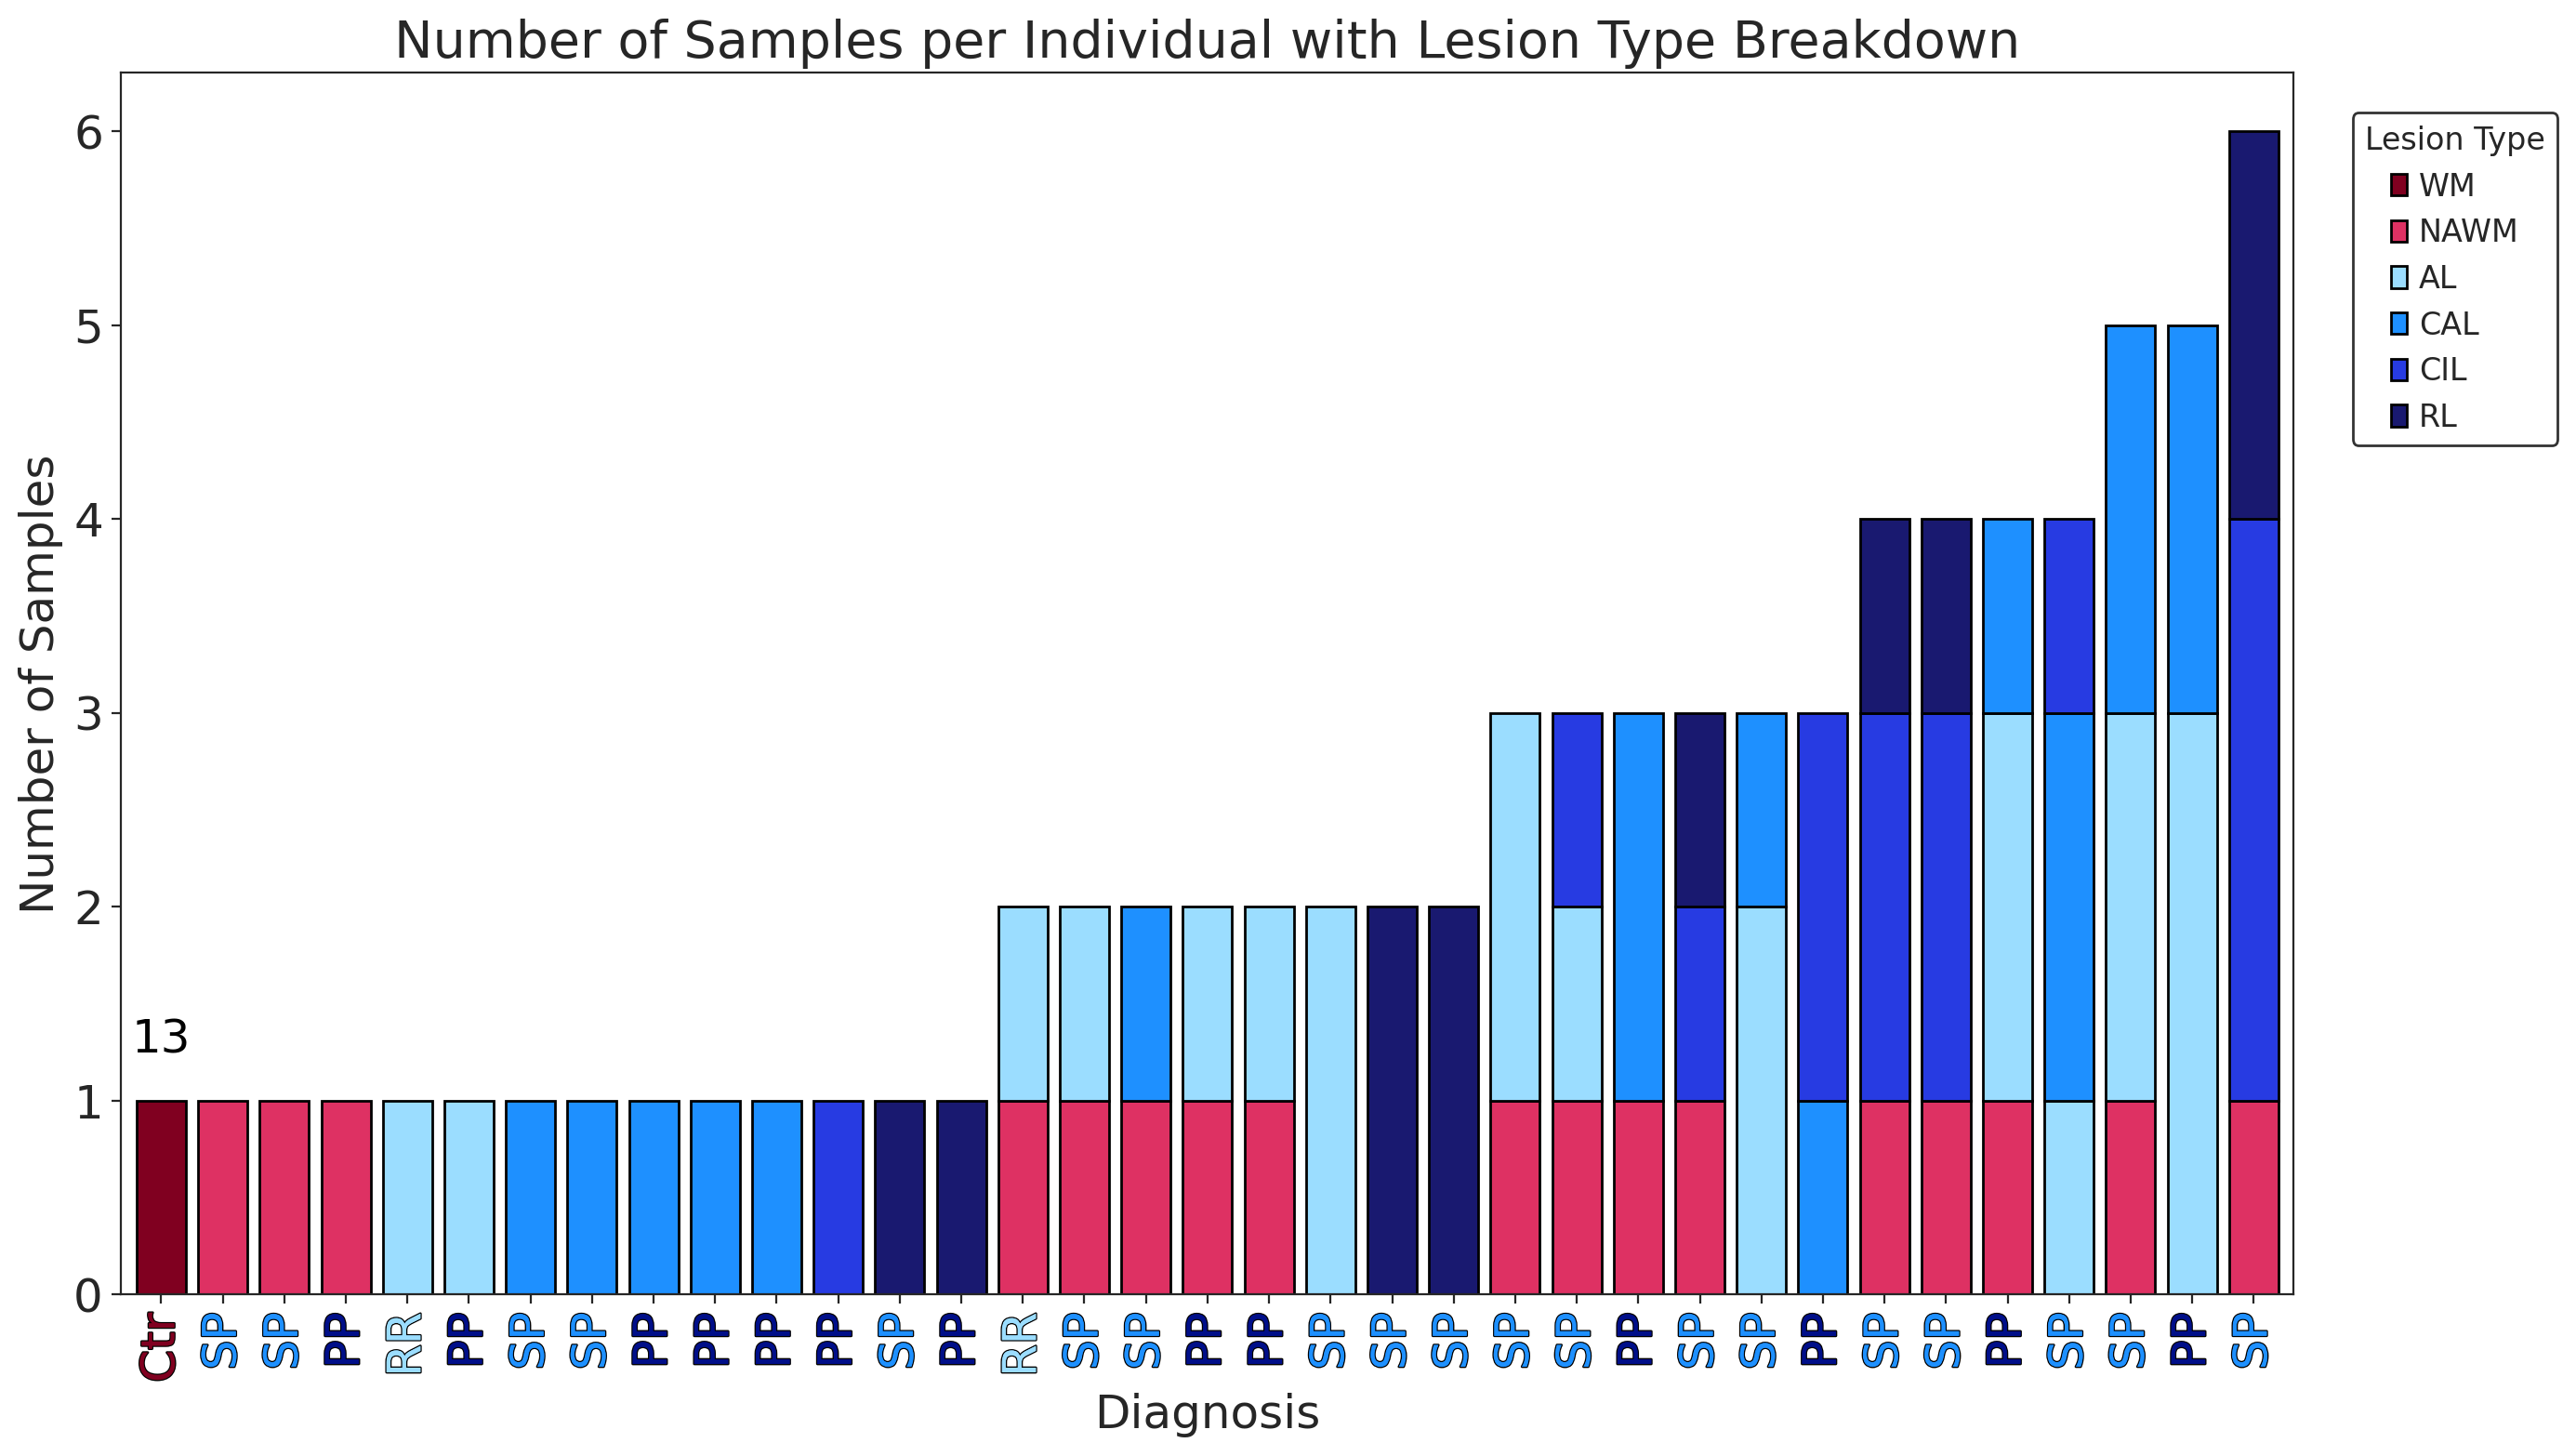

In [114]:
import matplotlib.patheffects as path_effects

# Define the colors for each lesion type
colors = {
    'WM': '#800020',
    'NAWM': '#de3163',
    'AL': '#9bddff',
    'CAL': '#1e90ff',
    'CIL': '#273be2',
    'RL': '#191970'
}

# Define the desired order of individuals
individual_order = [
    'Ind86',
    'Ind105', 'Ind111', 'Ind125',
    'Ind103', 'Ind143',
    'Ind110', 'Ind137', 'Ind119', 'Ind136', 'Ind124',
    'Ind128',
    'Ind147', 'Ind146',
    'Ind132', 'Ind106', 'Ind120', 'Ind112', 'Ind122', 'Ind115', 'Ind141', 'Ind142',
    'Ind113', 'Ind109', 'Ind116', 'Ind104', 'Ind114', 'Ind123',
    'Ind101', 'Ind134', 'Ind118', 'Ind102',
    'Ind130', 'Ind127', 'Ind108'
]

# Define the diagnosis for each individual with simplified labels
individual_to_diagnosis = {
    'Ind86': 'Ctr',
    'Ind105': 'SP', 'Ind111': 'SP', 'Ind125': 'PP', 'Ind103': 'RR', 'Ind143': 'PP', 
    'Ind110': 'SP', 'Ind137': 'SP', 'Ind119': 'PP', 'Ind136': 'PP', 'Ind124': 'PP', 
    'Ind128': 'PP','Ind147': 'SP', 'Ind146': 'PP', 
    'Ind132': 'RR', 'Ind106': 'SP', 'Ind120': 'SP', 'Ind112': 'PP', 'Ind122': 'PP',  
    'Ind115': 'SP', 'Ind141': 'SP','Ind142': 'SP', 
    'Ind113': 'SP', 'Ind109': 'SP', 'Ind116': 'PP',
    'Ind104': 'SP', 'Ind114': 'SP', 'Ind123': 'PP',
    
    'Ind101': 'SP', 'Ind134': 'SP', 'Ind118': 'PP', 'Ind102': 'SP', 
    'Ind130': 'SP', 'Ind127': 'PP',
    'Ind108': 'SP'
}

# Define the color for each diagnosis
diagnosis_colors = {
    'Ctr': '#800020',
    'RR': '#9bddff',
    'SP': '#1e90ff',
    'PP': '#000f89',
}

# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Calculate total samples per individual
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)

# Reorder the DataFrame based on the specific order of individual IDs
pivoted_counts_reordered = pivoted_counts.loc[individual_order]

# Drop the total_samples column for plotting
pivoted_counts_plot = pivoted_counts_reordered.drop(columns=['total_samples'])

# Reorder lesion types for plotting
desired_treatments_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']
pivoted_counts_plot = pivoted_counts_plot[desired_treatments_order]

# Replace individual IDs with diagnosis labels
diagnosis_labels = [individual_to_diagnosis[ind] for ind in individual_order]

# Plot
plt.figure(figsize=(14, 8))
ax = pivoted_counts_plot.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8, color=[colors[col] for col in desired_treatments_order], edgecolor='black')

# Customize the plot
plt.title('Number of Samples per Individual with Lesion Type Breakdown', fontsize=20)
plt.xlabel('Diagnosis', fontsize=18)
plt.ylabel('Number of Samples', fontsize=18)
plt.yticks(fontsize=18)
plt.xticks(ticks=range(len(diagnosis_labels)), labels=diagnosis_labels, rotation=90, fontsize=18)

# Color x-axis labels with outline
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    diagnosis = diagnosis_labels[int(tick)]
    label.set_color(diagnosis_colors.get(diagnosis, '#000000'))  # Default to black if diagnosis is not in the color map
    label.set_path_effects([
        path_effects.withStroke(linewidth=1, foreground='black'), 
        path_effects.Normal()
    ])
    
ax.text(0, 1 + 0.2, '13', ha='center', va='bottom', fontsize=18, color='black')

# Customize legend
handles, labels = ax.get_legend_handles_labels()
ordered_labels = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']
handles = [handles[labels.index(label)] for label in ordered_labels]
plt.legend(handles=handles, labels=ordered_labels, title='Lesion Type', bbox_to_anchor=(1.02, 0.98), loc='upper left', fontsize=12, frameon=True, edgecolor='black')

plt.grid(False)  # Remove grid lines

plt.savefig('./figures_all/Diagnosis_lesion_type_bySamples_stacked_barchart_simplified.png', bbox_inches='tight')

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

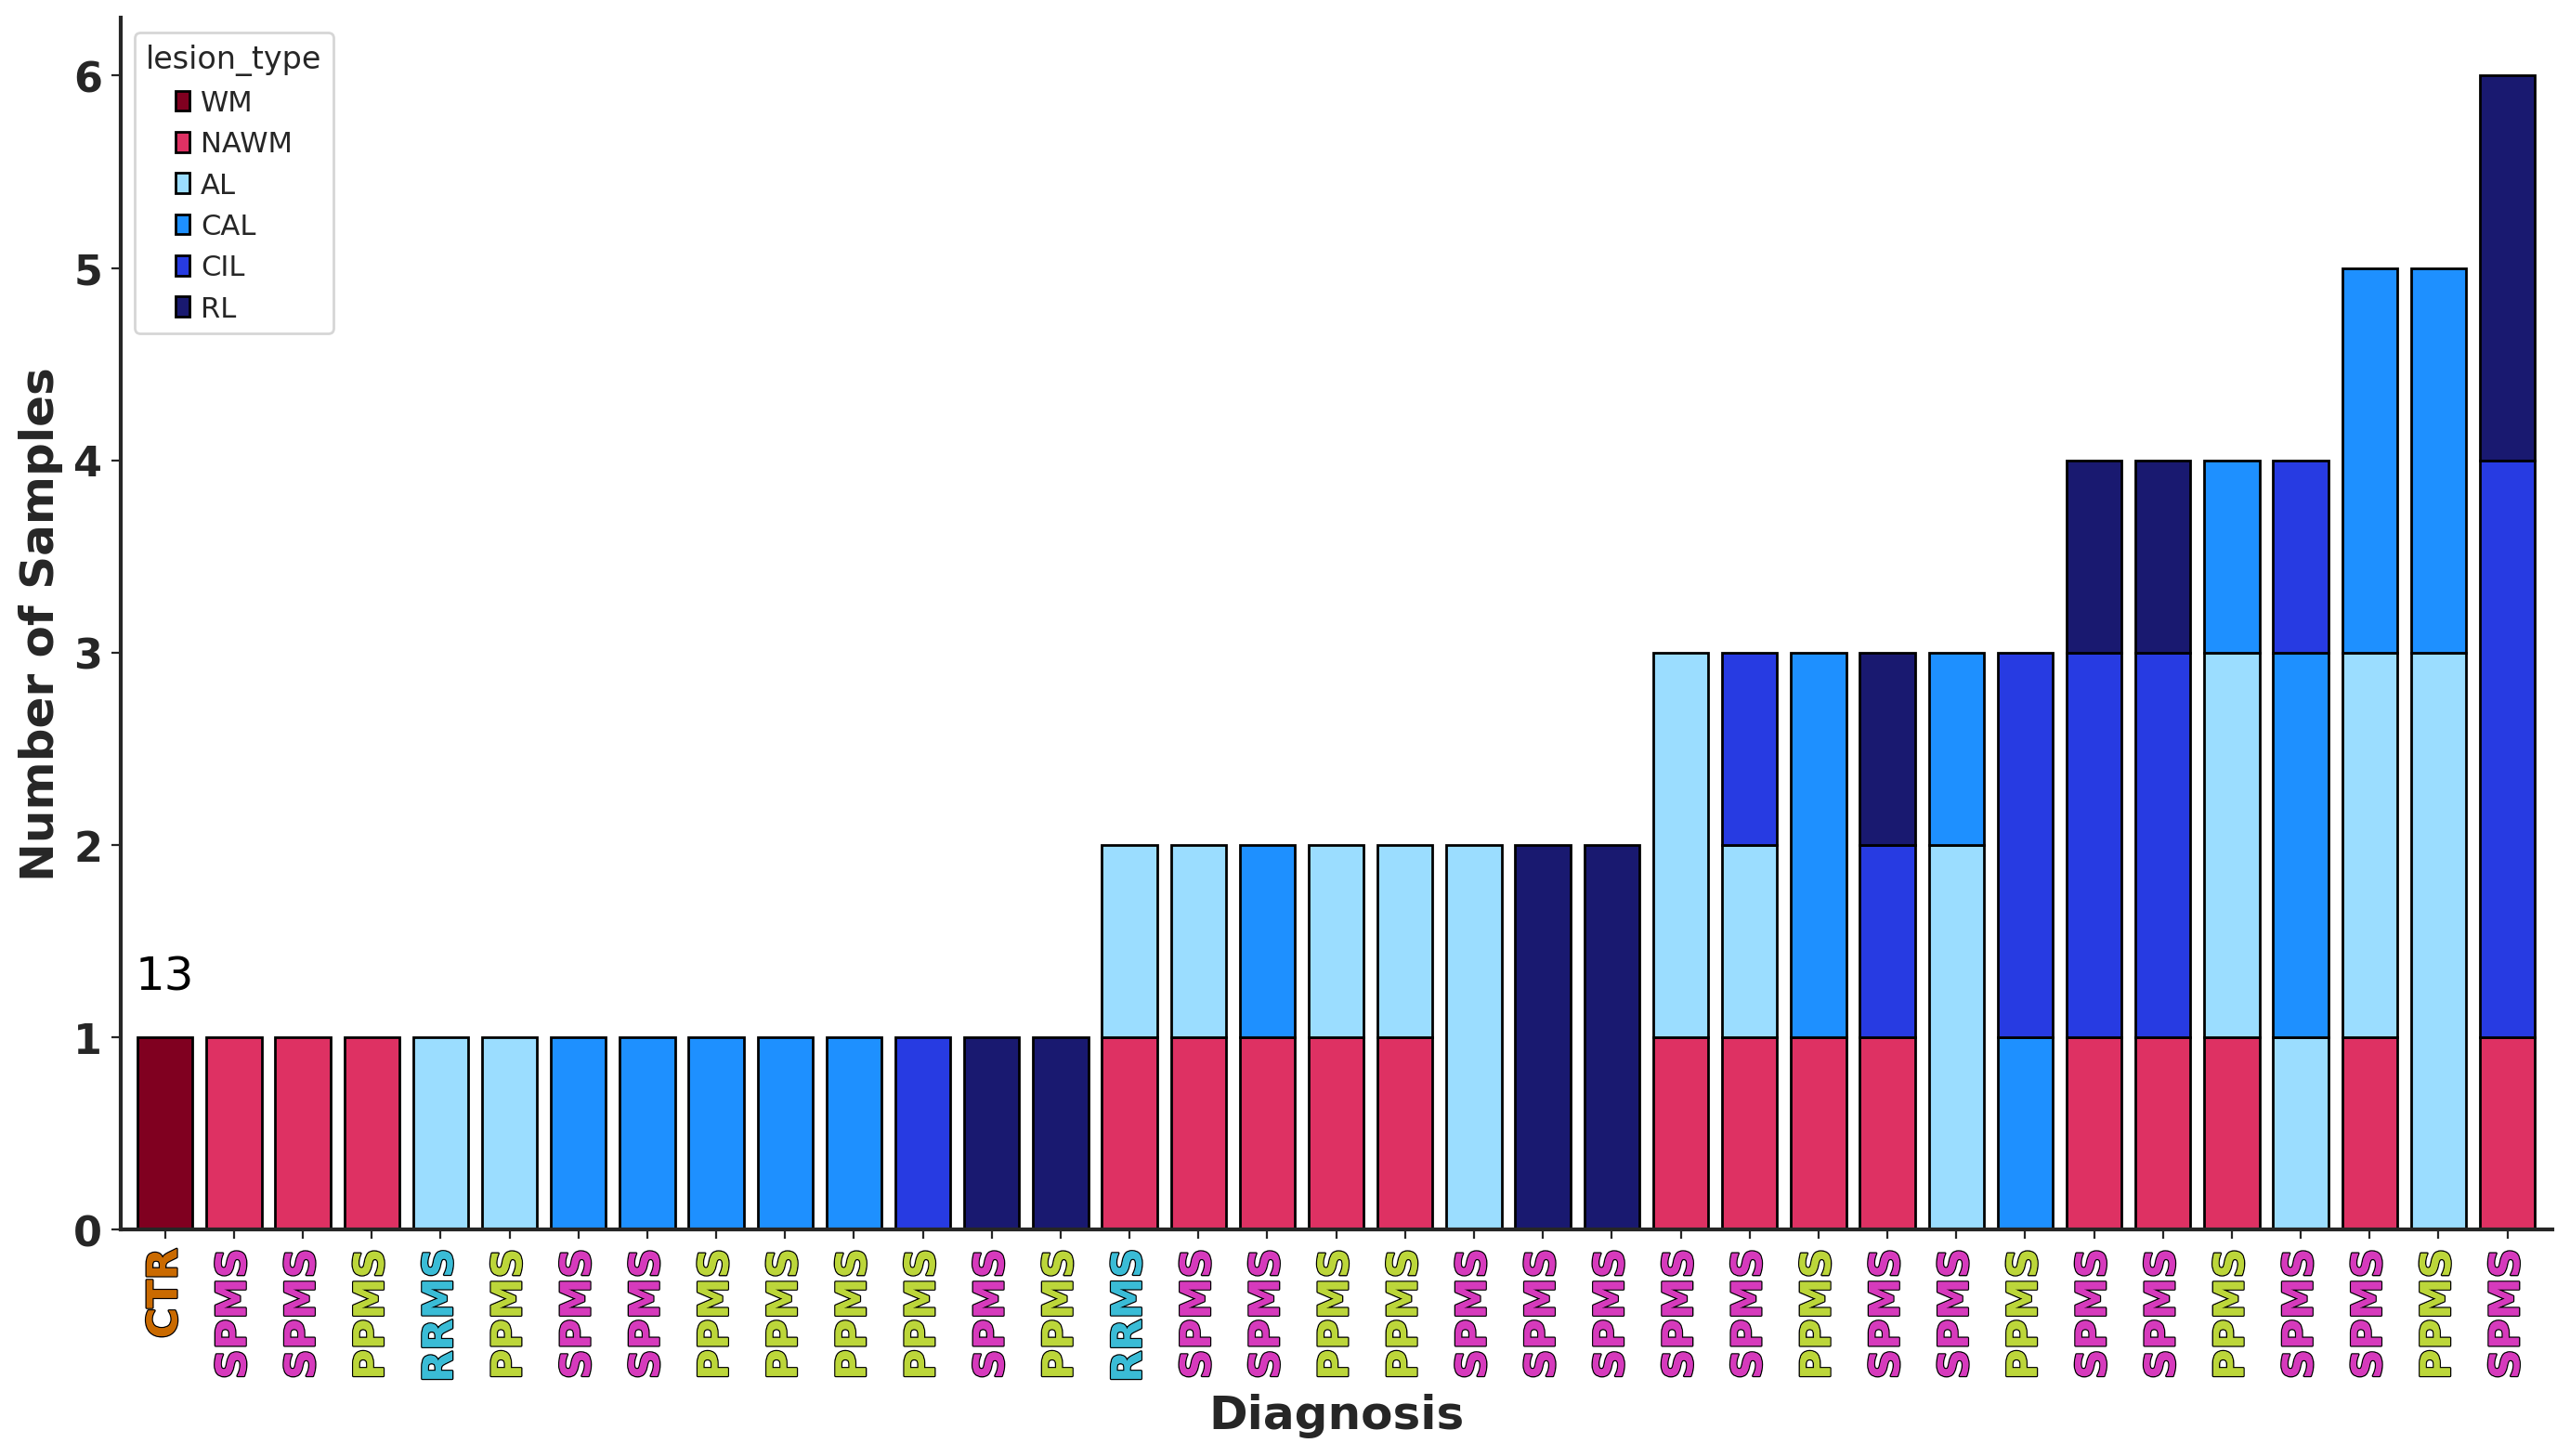

In [116]:
import matplotlib.patheffects as path_effects

# Define the colors for each lesion type
colors = {
    'WM': '#800020',
    'NAWM': '#de3163',
    'AL': '#9bddff',
    'CAL': '#1e90ff',
    'CIL': '#273be2',
    'RL': '#191970'
}

# Define the desired order of individuals
individual_order = [
    'Ind86',
    'Ind105', 'Ind111', 'Ind125',
    'Ind103', 'Ind143',
    'Ind110', 'Ind137', 'Ind119', 'Ind136', 'Ind124',
    'Ind128',
    'Ind147', 'Ind146',
    'Ind132', 'Ind106', 'Ind120', 'Ind112', 'Ind122', 'Ind115', 'Ind141', 'Ind142',
    'Ind113', 'Ind109', 'Ind116', 'Ind104', 'Ind114', 'Ind123',
    'Ind101', 'Ind134', 'Ind118', 'Ind102',
    'Ind130', 'Ind127', 'Ind108'
]

# Update diagnosis mapping with full labels
individual_to_diagnosis = {
    'Ind86': 'CTR',
    'Ind105': 'SPMS', 'Ind111': 'SPMS', 'Ind125': 'PPMS', 'Ind103': 'RRMS', 'Ind143': 'PPMS',
    'Ind110': 'SPMS', 'Ind137': 'SPMS', 'Ind119': 'PPMS', 'Ind136': 'PPMS', 'Ind124': 'PPMS',
    'Ind128': 'PPMS', 'Ind147': 'SPMS', 'Ind146': 'PPMS',
    'Ind132': 'RRMS', 'Ind106': 'SPMS', 'Ind120': 'SPMS', 'Ind112': 'PPMS', 'Ind122': 'PPMS',
    'Ind115': 'SPMS', 'Ind141': 'SPMS', 'Ind142': 'SPMS',
    'Ind113': 'SPMS', 'Ind109': 'SPMS', 'Ind116': 'PPMS',
    'Ind104': 'SPMS', 'Ind114': 'SPMS', 'Ind123': 'PPMS',
    'Ind101': 'SPMS', 'Ind134': 'SPMS', 'Ind118': 'PPMS', 'Ind102': 'SPMS',
    'Ind130': 'SPMS', 'Ind127': 'PPMS',
    'Ind108': 'SPMS'
}

# Update diagnosis colors
diagnosis_colors = {
    'CTR': '#ca6a00',
    'RRMS': '#3abcd6',
    'SPMS': '#d63abc',
    'PPMS': '#bcd63a'
}

# Count number of unique samples per lesion type for each individual
sample_counts_per_individual = adata_df.groupby(['individual_id_anon', 'lesion_type'])['sample_id_anon'].nunique().reset_index(name='sample_count')

# Pivot the table to have one row per individual and columns for each lesion_type
pivoted_counts = sample_counts_per_individual.pivot_table(index='individual_id_anon', columns='lesion_type', values='sample_count', fill_value=0)

# Fill missing lesion types with 0
pivoted_counts = pivoted_counts.fillna(0)

# Calculate total samples per individual
pivoted_counts['total_samples'] = pivoted_counts.sum(axis=1)

# Reorder the DataFrame based on the specific order of individual IDs
pivoted_counts_reordered = pivoted_counts.loc[individual_order]

# Drop the total_samples column for plotting
pivoted_counts_plot = pivoted_counts_reordered.drop(columns=['total_samples'])

# Reorder lesion types for plotting
desired_treatments_order = ['WM', 'NAWM', 'AL', 'CAL', 'CIL', 'RL']
pivoted_counts_plot = pivoted_counts_plot[desired_treatments_order]

# Replace individual IDs with diagnosis labels
diagnosis_labels = [individual_to_diagnosis[ind] for ind in individual_order]

# Plot
plt.figure(figsize=(14, 8))
ax = pivoted_counts_plot.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8, color=[colors[col] for col in desired_treatments_order], edgecolor='black')

# Customize the plot
plt.xlabel('Diagnosis', fontsize=18)
plt.ylabel('Number of Samples', fontsize=18)
plt.yticks(fontsize=18)
plt.xticks(ticks=range(len(diagnosis_labels)), labels=diagnosis_labels, rotation=90, fontsize=18)

# When setting x-axis labels, use new color scheme
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    diagnosis = diagnosis_labels[int(tick)]
    label.set_color(diagnosis_colors.get(diagnosis, '#000000'))  # fallback to black
    label.set_path_effects([
        path_effects.withStroke(linewidth=1, foreground='black'),
        path_effects.Normal()
    ])
    
ax.text(0, 1 + 0.2, '13', ha='center', va='bottom', fontsize=18, color='black')

# Customize axis labels and ticks
plt.xlabel('Diagnosis', fontsize=18, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=18, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.xticks(
    ticks=range(len(diagnosis_labels)),
    labels=diagnosis_labels,
    rotation=90,
    fontsize=16,
    fontweight='bold'
)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Optional: emphasize left and bottom spines
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
plt.grid(False)  # Remove grid lines

plt.savefig('./figures_all/Diagnosis_lesion_type_bySamples_stacked_barchart_UPDATED.png', bbox_inches='tight')

plt.tight_layout()
plt.show()